# Installation and Connection with OpenFold

In [ ]:
!pip -q install awscli
!aws s3 ls s3://openfold/ --no-sign-request

## Download 50 proteins to build the dataset

In [2]:
!mkdir -p /content/af_subset/msas
!mkdir -p /content/af_subset/jsons
!mkdir -p /content/af_subset/meta

In [3]:
!aws s3 cp s3://openfold/benchmarking_data/input_jsons_converted/wo_templates/fb_protein.json \
  /content/af_subset/jsons/ --no-sign-request

download: s3://openfold/benchmarking_data/input_jsons_converted/wo_templates/fb_protein.json to af_subset/jsons/fb_protein.json


In [4]:
import json
from pathlib import Path

json_path = Path("/content/af_subset/jsons/fb_protein.json")

with open(json_path, "r") as f:
    data = json.load(f)

targets = []
for qname, q in data["queries"].items():
    for chain in q["chains"]:
        for cid in chain["chain_ids"]:
            if isinstance(cid, str) and len(cid) == 1 and cid.isalpha():
                targets.append(f"{qname.lower()}_{cid}")
                break
        break

targets = sorted(set(targets))
print("n targets:", len(targets))
print(targets[:20])

with open("/content/af_subset/fb_targets_50.txt", "w") as f:
    for t in targets[:50]:
        f.write(t + "\n")

n targets: 239
['7qrj_A', '7qrr_A', '7quv_A', '7qwe_A', '7spq_A', '7th0_A', '7txy_A', '7uq2_A', '7vub_A', '7wr3_A', '7x36_A', '7x80_A', '7xfr_A', '7xft_A', '7xl7_A', '7xn2_A', '7xpi_A', '7xpt_A', '7xrb_A', '7xvq_A']


In [ ]:
%%bash
mkdir -p /content/af_subset/foldbench_msas

while read t; do
  echo "Downloading $t"
  aws s3 cp "s3://openfold/benchmarking_data/msas/foldbench_msas/$t/" \
            "/content/af_subset/foldbench_msas/$t/" \
            --recursive --no-sign-request
done < /content/af_subset/fb_targets_50.txt

In [6]:
!aws s3 ls s3://openfold/benchmarking_data/reference_structures/ --recursive --no-sign-request | grep -Ei '7QRJ|7QRR|7QUV|7SPQ|7WR3' | head -n 50

2025-11-26 05:15:10     793225 benchmarking_data/reference_structures/foldbench_protein/7qrj-assembly1_68.cif
2025-11-26 05:15:10     272054 benchmarking_data/reference_structures/foldbench_protein/7qrr-assembly1_67.cif
2025-11-26 05:15:11     164863 benchmarking_data/reference_structures/foldbench_protein/7quv-assembly1_70.cif
2025-11-26 05:15:11     146719 benchmarking_data/reference_structures/foldbench_protein/7quv-assembly1_71.cif
2025-11-26 05:15:11    1138414 benchmarking_data/reference_structures/foldbench_protein/7spq-assembly1_142.cif
2025-11-26 05:15:11     864856 benchmarking_data/reference_structures/foldbench_protein/7wr3-assembly1_167.cif


In [ ]:
%%bash
mkdir -p /content/af_subset/reference_structures

while read t; do
  pdb=$(echo "$t" | cut -d'_' -f1 | tr '[:upper:]' '[:lower:]')
  echo "Searching structure for $pdb"

  file=$(aws s3 ls s3://openfold/benchmarking_data/reference_structures/foldbench_protein/ --no-sign-request \
    | awk '{print $4}' \
    | grep -E "^${pdb}-assembly1_.*\.cif$" \
    | head -n 1)

  if [ -n "$file" ]; then
    echo "Downloading $file"
    aws s3 cp "s3://openfold/benchmarking_data/reference_structures/foldbench_protein/$file" \
              "/content/af_subset/reference_structures/$file" \
              --no-sign-request
  else
    echo "NO STRUCTURE FOUND FOR $pdb"
  fi
done < /content/af_subset/fb_targets_50.txt

In [8]:
!ls /content/af_subset/reference_structures | head
!ls /content/af_subset/reference_structures | wc -l

7qrj-assembly1_68.cif
7qrr-assembly1_67.cif
7quv-assembly1_70.cif
7qwe-assembly1_206.cif
7spq-assembly1_142.cif
7th0-assembly1_130.cif
7txy-assembly1_58.cif
7uq2-assembly1_113.cif
7vub-assembly1_178.cif
7wr3-assembly1_167.cif
50


---

# Create a Reference dataset

In [9]:
import json
from pathlib import Path
import pandas as pd

json_path = Path("/content/af_subset/jsons/fb_protein.json")
msa_root = Path("/content/af_subset/foldbench_msas")
cif_root = Path("/content/af_subset/reference_structures")

with open(json_path, "r") as f:
    data = json.load(f)

rows = []

for qname, q in data["queries"].items():
    chain = q["chains"][0]
    chain_ids = chain["chain_ids"]
    sequence = chain["sequence"]

    # elegimos la primera cadena alfabética simple, como hicimos al descargar MSAs
    chosen_chain = None
    for cid in chain_ids:
        if isinstance(cid, str) and len(cid) == 1 and cid.isalpha():
            chosen_chain = cid
            break

    if chosen_chain is None:
        continue

    msa_dir_name = f"{qname.lower()}_{chosen_chain}"
    msa_dir = msa_root / msa_dir_name

    cif_candidates = list(cif_root.glob(f"{qname.lower()}-assembly1_*.cif"))
    cif_file = cif_candidates[0] if len(cif_candidates) > 0 else None

    rows.append({
        "query_name": qname,
        "chain_id": chosen_chain,
        "msa_dir_name": msa_dir_name,
        "msa_exists": msa_dir.exists(),
        "msa_dir": str(msa_dir),
        "cif_exists": cif_file is not None,
        "cif_file": str(cif_file) if cif_file is not None else None,
        "seq_len": len(sequence),
        "sequence": sequence})

df_map = pd.DataFrame(rows)
df_map = df_map.dropna(subset=['cif_file'])
print("\nN total:", len(df_map))
print("MSA disponibles:", df_map["msa_exists"].sum())
print("CIF disponibles:", df_map["cif_exists"].sum())
print("Ambos disponibles:", (df_map["msa_exists"] & df_map["cif_exists"]).sum())


N total: 50
MSA disponibles: 50
CIF disponibles: 50
Ambos disponibles: 50


In [10]:
df_map.head(5)

,query_name,chain_id,msa_dir_name,msa_exists,msa_dir,cif_exists,cif_file,seq_len,sequence
0,7QRJ,A,7qrj_A,True,/content/af_subset/foldbench_msas/7qrj_A,True,/content/af_subset/reference_structures/7qrj-a...,184,MSISSLLEKNIYNVHNKSNTLTNVPANPTGNTNTVWSNSNFTPPHL...
1,7QRR,A,7qrr_A,True,/content/af_subset/foldbench_msas/7qrr_A,True,/content/af_subset/reference_structures/7qrr-a...,153,MSVYGPVPTVTTRAFLPRLATAADSITSTTTTIALDPQTEQSYWTR...
2,7QUV,A,7quv_A,True,/content/af_subset/foldbench_msas/7quv_A,True,/content/af_subset/reference_structures/7quv-a...,122,GPMTSKMSQLERNIETIINTFHQYSVKLGHPDTLNQGEFKELVRKD...
3,7QWE,A,7qwe_A,True,/content/af_subset/foldbench_msas/7qwe_A,True,/content/af_subset/reference_structures/7qwe-a...,32,XGEIAQALKEIAKALKEIAYALKEIAQALKGX
4,7SPQ,A,7spq_A,True,/content/af_subset/foldbench_msas/7spq_A,True,/content/af_subset/reference_structures/7spq-a...,328,GHMTIKLADNPNRLTDREAMGLPETFVARTPVALLAGHEDLLGAGA...


In [11]:
todos_unicos = set("".join(df_map["sequence"].dropna()))
print("Aminoácidos únicos en todo el dataset:", len(todos_unicos))
print("Letras únicas:", sorted(todos_unicos))

Aminoácidos únicos en todo el dataset: 21
Letras únicas: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'X', 'Y']


---

# **Visualize and understand the DataSet**

## View a protein

In [12]:

json_path = Path("/content/af_subset/jsons/fb_protein.json")

with open(json_path, "r") as f:
    data = json.load(f)

q = data["queries"]["7QRJ"]

print("query_name:", q["query_name"])
print("chain_ids:", q["chains"][0]["chain_ids"])
print("sequence:")
print(q["chains"][0]["sequence"])
print("length:", len(q["chains"][0]["sequence"]))

query_name: 7QRJ
chain_ids: ['A', 'B', 'E']
sequence:
MSISSLLEKNIYNVHNKSNTLTNVPANPTGNTNTVWSNSNFTPPHLMYGASDITQAIGNISLTTGSFSLSLSGPWASPLVQNVAYTKINNLVNLTFPPFQANATSSAVINSAIGALPADLRPTTNIQVDFEIFVIDDGNRPVNPGLITLLSNGQIVVYKDNNLGQFTTGIGGSGFNPFSITYMV
length: 184


In [13]:
msa_path = "/content/af_subset/foldbench_msas/7qrj_A/cfdb_hits.a3m"

with open(msa_path, "r") as f:
    lines = f.readlines()

print("Primeras 20 líneas:\n")
for line in lines[:20]:
    print(line.rstrip())

Primeras 20 líneas:

>7qrj_1
MSISSLLEKNIYNVHNKSNTLTNVPANPTGNTNTVWSNSNFTPPHLMYGASDITQAIGNISLTTGSFSLSLSGPWASPLVQNVAYTKINNLVNLTFPPFQANATSSAVINSAIGALPADLRPTTNIQVDFEIFVIDDGNRPVNPGLITLLSNGQIVVYKDNNLGQFTTGIGGSGFNPFSITYMV
>tr|I0CER9|I0CER9_9VIRU
MSVSTLFQQNNNNIYNKSNTLTNTPSNPTGNTNTLWSNSGFNPPHLMYGASDVTAAINNIAFETGTFNLQLSGPWASPISHAVSYTKINNLVNLTIPTYQAQATTLASISSIVGALPTNLRPVNNPEIDFEIFVLDNGTRTTNPGLITLLSNGQILIYKDNNLGQFTVGSGGSGFNPFSITYMI
>SAMN10351357:k141_938366_10
----------------------------------------------PATVQEALDDLGVGSYSTSTHNTTWSGIWAAAQTGNVIYTKIGKLVTLQIPAFSAVSNAASVI-TADTVLPSGLRPTT--EMHFVVHVNDNATGAH--GVFKVNDLGQMVFYASDVQGNFA-GAGSSGVFQTTVSYI-
>SAMN08777771:k141_2134148_2
----------------------------------------------MLNGLSKNAKDVLVSIDTGTHNTDWSGIWASSQSGNIEYQKVGDCVRIFIPTINATATTVSNI-SMVTALPSDLWPTN--SEEVVLYVEDNLIKKV--GKATIGIAGSINVYADAATGSFA-GSGLSGIQKCTLQYN-
>SAMN10864233:k141_1082461_5
--------------------------------------------------MADTFYNSTTTLTTGTHSTNWTGIWSASQAGNIRWTLVQNIVTLKIPTTTSTANTAATI-TNTVALPSSL

In [14]:
msa_path = Path("/content/af_subset/foldbench_msas/7qrj_A/cfdb_hits.a3m")

seqs = []
names = []

with open(msa_path, "r") as f:
    current_name = None
    current_seq = []
    for line in f:
        line = line.strip()
        if not line:
            continue
        if line.startswith(">"):
            if current_name is not None:
                names.append(current_name)
                seqs.append("".join(current_seq))
            current_name = line[1:]
            current_seq = []
        else:
            current_seq.append(line)
    if current_name is not None:
        names.append(current_name)
        seqs.append("".join(current_seq))

print("Número de secuencias en este archivo:", len(seqs))
print("Longitud de la primera secuencia:", len(seqs[0]))
print("\nPrimeros 5 nombres:")
for n in names[:5]:
    print(n)

print("\nPrimeras 5 secuencias recortadas:")
for s in seqs[:5]:
    print(s[:120])

Número de secuencias en este archivo: 1221
Longitud de la primera secuencia: 184

Primeros 5 nombres:
7qrj_1
tr|I0CER9|I0CER9_9VIRU
SAMN10351357:k141_938366_10
SAMN08777771:k141_2134148_2
SAMN10864233:k141_1082461_5

Primeras 5 secuencias recortadas:
MSISSLLEKNIYNVHNKSNTLTNVPANPTGNTNTVWSNSNFTPPHLMYGASDITQAIGNISLTTGSFSLSLSGPWASPLVQNVAYTKINNLVNLTFPPFQANATSSAVINSAIGALPADL
MSVSTLFQQNNNNIYNKSNTLTNTPSNPTGNTNTLWSNSGFNPPHLMYGASDVTAAINNIAFETGTFNLQLSGPWASPISHAVSYTKINNLVNLTIPTYQAQATTLASISSIVGALPTNL
----------------------------------------------PATVQEALDDLGVGSYSTSTHNTTWSGIWAAAQTGNVIYTKIGKLVTLQIPAFSAVSNAASVI-TADTVLPSGL
----------------------------------------------MLNGLSKNAKDVLVSIDTGTHNTDWSGIWASSQSGNIEYQKVGDCVRIFIPTINATATTVSNI-SMVTALPSDL
--------------------------------------------------MADTFYNSTTTLTTGTHSTNWTGIWSASQAGNIRWTLVQNIVTLKIPTTTSTANTAATI-TNTVALPSSL


## Visualize conservation by position

In [15]:
from collections import Counter
import pandas as pd

max_show = 60
msa = seqs[:100]
L = min(len(s) for s in msa)

rows = []
for j in range(min(L, max_show)):
    col = [s[j] for s in msa]
    counts = Counter(col)
    top_char, top_freq = counts.most_common(1)[0]
    rows.append({
        "pos": j + 1,
        "top_aa": top_char,
        "freq": top_freq / len(col),
        "n_unique": len(counts)
    })

df_cons = pd.DataFrame(rows)
print(df_cons.head(10))

   pos top_aa  freq  n_unique
0    1      -  0.98         2
1    2      -  0.98         2
2    3      -  0.98         3
3    4      -  0.98         2
4    5      -  0.98         3
5    6      -  0.98         2
6    7      -  0.98         3
7    8      -  0.98         3
8    9      -  0.98         3
9   10      -  0.98         2


## Visualize the 3D structure

In [ ]:
!pip -q install py3Dmol biopython

In [17]:
import py3Dmol

cif_path = "/content/af_subset/reference_structures/7qrj-assembly1_68.cif"

with open(cif_path, "r") as f:
    cif_str = f.read()

view = py3Dmol.view(width=800, height=600)
view.addModel(cif_str, "mmcif")
view.setStyle({"cartoon": {"color": "spectrum"}})
view.zoomTo()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [19]:
import numpy as np
from Bio.PDB.MMCIFParser import MMCIFParser

parser = MMCIFParser(QUIET=True)
structure = parser.get_structure("7qrj", "/content/af_subset/reference_structures/7qrj-assembly1_68.cif")

for model in structure:
    print("Model:", model.id)
    for chain in model:
        print("Chain:", chain.id)
        residues = list(chain.get_residues())
        print("N residuos:", len(residues))
        break
    break


coords = []
res_ids = []

for model in structure:
    for chain in model:
        if chain.id == "A":
            for residue in chain:
                if "CA" in residue:
                    coords.append(residue["CA"].coord)
                    res_ids.append(residue.id)
            break
    break

coords = np.array(coords)

print("Shape coords:", coords.shape)
print("Primeras 5 coordenadas:")
print(coords[:10])

Model: 0
Chain: A
N residuos: 181
Shape coords: (181, 3)
Primeras 5 coordenadas:
[[-10.743  12.501 -37.318]
 [-10.583  16.234 -37.986]
 [-12.536  16.824 -34.756]
 [-10.049  14.71  -32.771]
 [ -7.182  17.197 -33.265]
 [ -6.963  20.989 -33.273]
 [ -9.107  22.604 -35.96 ]
 [-10.629  25.987 -36.771]
 [-14.215  24.706 -36.441]
 [-16.838  26.782 -34.657]]


## Map of distances Cα–Cα

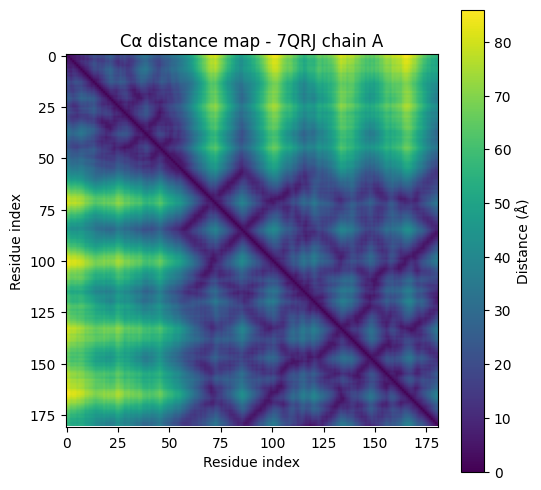

In [20]:
import numpy as np
import matplotlib.pyplot as plt

D = np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(-1))

plt.figure(figsize=(6,6))
plt.imshow(D)
plt.colorbar(label="Distance (Å)")
plt.title("Cα distance map - 7QRJ chain A")
plt.xlabel("Residue index")
plt.ylabel("Residue index")
plt.show()

---

# Build the Dataset

In [ ]:
!pip install Bio

## Helpers for loaders:

In [23]:
from __future__ import annotations

import json
from dataclasses import asdict, dataclass
from pathlib import Path
from statistics import median
from typing import Any, Iterable, Mapping, Sequence

import pandas as pd
import yaml


DEFAULT_A3M_FILENAME = "cfdb_hits.a3m"


@dataclass(frozen=True)
class FoldbenchManifestRecord:
    query_name: str
    chain_id: str
    msa_dir_name: str
    msa_exists: bool
    msa_dir: str
    cif_exists: bool
    cif_file: str | None
    seq_len: int
    sequence: str

    def to_row(self) -> dict[str, Any]:
        return asdict(self)


def _as_path(value: str | Path) -> Path:
    return Path(value).expanduser()


def load_queries(json_path: str | Path) -> Mapping[str, Any]:
    with _as_path(json_path).open("r", encoding="utf-8") as handle:
        payload = json.load(handle)

    queries = payload.get("queries")
    if not isinstance(queries, dict):
        raise ValueError(f"Invalid Foldbench JSON payload: missing 'queries' in {json_path}")

    return queries


def choose_primary_chain_id(chain_ids: Sequence[Any]) -> str | None:
    for chain_id in chain_ids:
        if isinstance(chain_id, str) and len(chain_id) == 1 and chain_id.isalpha():
            return chain_id

    return None


def build_msa_dir_name(query_name: str, chain_id: str) -> str:
    return f"{query_name.lower()}_{chain_id}"


def find_cif_file(cif_root: str | Path, query_name: str) -> Path | None:
    root = _as_path(cif_root)
    matches = sorted(root.glob(f"{query_name.lower()}-assembly1_*.cif"))
    return matches[0] if matches else None


def build_manifest_records(
    json_path: str | Path,
    msa_root: str | Path,
    cif_root: str | Path,
) -> list[FoldbenchManifestRecord]:
    queries = load_queries(json_path)
    msa_root_path = _as_path(msa_root)
    cif_root_path = _as_path(cif_root)

    records: list[FoldbenchManifestRecord] = []

    for query_name, query_payload in sorted(queries.items()):
        chains = query_payload.get("chains", [])
        if not chains:
            continue

        chain = chains[0]
        sequence = chain.get("sequence", "")
        chain_id = choose_primary_chain_id(chain.get("chain_ids", []))
        if chain_id is None:
            continue

        msa_dir_name = build_msa_dir_name(query_name, chain_id)
        msa_dir = msa_root_path / msa_dir_name
        cif_file = find_cif_file(cif_root_path, query_name)

        records.append(
            FoldbenchManifestRecord(
                query_name=query_name,
                chain_id=chain_id,
                msa_dir_name=msa_dir_name,
                msa_exists=msa_dir.exists(),
                msa_dir=str(msa_dir),
                cif_exists=cif_file is not None,
                cif_file=str(cif_file) if cif_file is not None else None,
                seq_len=len(sequence),
                sequence=sequence,
            )
        )

    return records


def manifest_dataframe_from_records(
    records: Iterable[FoldbenchManifestRecord],
) -> pd.DataFrame:
    rows = [record.to_row() for record in records]
    if not rows:
        return pd.DataFrame(
            columns=[
                "query_name",
                "chain_id",
                "msa_dir_name",
                "msa_exists",
                "msa_dir",
                "cif_exists",
                "cif_file",
                "seq_len",
                "sequence",
            ]
        )

    return pd.DataFrame(rows)


def build_manifest_dataframe(
    json_path: str | Path,
    msa_root: str | Path,
    cif_root: str | Path,
) -> pd.DataFrame:
    return manifest_dataframe_from_records(
        build_manifest_records(
            json_path=json_path,
            msa_root=msa_root,
            cif_root=cif_root,
        )
    )


def rewrite_manifest_paths(
    manifest_df: pd.DataFrame,
    msa_root: str | Path | None = None,
    cif_root: str | Path | None = None,
) -> pd.DataFrame:
    df = manifest_df.copy()

    if "seq_len" in df.columns:
        df["seq_len"] = pd.to_numeric(df["seq_len"], errors="coerce").fillna(0).astype(int)

    for flag_col in ("msa_exists", "cif_exists"):
        if flag_col in df.columns:
            df[flag_col] = df[flag_col].astype(str).str.lower().map({"true": True, "false": False}).fillna(False)

    if msa_root is not None and "msa_dir_name" in df.columns:
        msa_root_path = _as_path(msa_root)
        df["msa_dir"] = [str(msa_root_path / name) for name in df["msa_dir_name"]]
        df["msa_exists"] = [(msa_root_path / name).exists() for name in df["msa_dir_name"]]

    if cif_root is not None and "query_name" in df.columns:
        cif_root_path = _as_path(cif_root)
        resolved_cifs = [find_cif_file(cif_root_path, query_name) for query_name in df["query_name"]]
        df["cif_file"] = [str(path) if path is not None else None for path in resolved_cifs]
        df["cif_exists"] = [path is not None for path in resolved_cifs]

    return df


def load_manifest_dataframe(
    manifest_csv: str | Path,
    msa_root: str | Path | None = None,
    cif_root: str | Path | None = None,
) -> pd.DataFrame:
    manifest_path = _as_path(manifest_csv)
    manifest_df = pd.read_csv(manifest_path)
    return rewrite_manifest_paths(
        manifest_df=manifest_df,
        msa_root=msa_root,
        cif_root=cif_root,
    )


def filter_complete_records(manifest_df: pd.DataFrame) -> pd.DataFrame:
    if manifest_df.empty:
        return manifest_df.copy()

    return manifest_df.loc[
        manifest_df["msa_exists"].astype(bool) & manifest_df["cif_exists"].astype(bool)
    ].reset_index(drop=True)


def derive_targets(
    manifest_df: pd.DataFrame,
    limit: int | None = None,
) -> list[str]:
    targets = manifest_df["msa_dir_name"].dropna().astype(str).drop_duplicates().tolist()
    if limit is not None:
        targets = targets[:limit]
    return targets


def write_targets_file(
    manifest_df: pd.DataFrame,
    output_path: str | Path,
    limit: int | None = None,
) -> Path:
    path = _as_path(output_path)
    path.parent.mkdir(parents=True, exist_ok=True)
    targets = derive_targets(manifest_df, limit=limit)
    contents = "\n".join(targets)
    if contents:
        contents += "\n"
    path.write_text(contents, encoding="utf-8")
    return path


def summarize_manifest(manifest_df: pd.DataFrame) -> dict[str, Any]:
    lengths = manifest_df["seq_len"].astype(int).tolist() if not manifest_df.empty else []
    complete_df = filter_complete_records(manifest_df)

    summary: dict[str, Any] = {
        "records": int(len(manifest_df)),
        "complete_records": int(len(complete_df)),
        "msa_available": int(manifest_df["msa_exists"].sum()) if "msa_exists" in manifest_df else 0,
        "cif_available": int(manifest_df["cif_exists"].sum()) if "cif_exists" in manifest_df else 0,
        "unique_chain_ids": sorted(manifest_df["chain_id"].dropna().astype(str).unique().tolist())
        if "chain_id" in manifest_df
        else [],
        "targets_preview": manifest_df["query_name"].head(10).astype(str).tolist()
        if "query_name" in manifest_df
        else [],
    }

    if lengths:
        summary["sequence_length"] = {
            "min": int(min(lengths)),
            "max": int(max(lengths)),
            "mean": round(sum(lengths) / len(lengths), 2),
            "median": float(median(lengths)),
        }
    else:
        summary["sequence_length"] = {"min": 0, "max": 0, "mean": 0.0, "median": 0.0}

    if not manifest_df.empty:
        longest = manifest_df.sort_values("seq_len", ascending=False).head(5)
        summary["longest_examples"] = longest[
            ["query_name", "chain_id", "seq_len"]
        ].to_dict(orient="records")
    else:
        summary["longest_examples"] = []

    return summary


def save_yaml(payload: Mapping[str, Any], output_path: str | Path) -> Path:
    path = _as_path(output_path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        yaml.safe_dump(
            dict(payload),
            handle,
            sort_keys=False,
            allow_unicode=False,
        )
    return path

## **Full DataSet for Pytorch**

In [ ]:
from __future__ import annotations

from functools import lru_cache
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import torch
from difflib import SequenceMatcher
from torch.utils.data import Dataset


AA_VOCAB = {
    "-": 0,
    "A": 1,
    "R": 2,
    "N": 3,
    "D": 4,
    "C": 5,
    "Q": 6,
    "E": 7,
    "G": 8,
    "H": 9,
    "I": 10,
    "L": 11,
    "K": 12,
    "M": 13,
    "F": 14,
    "P": 15,
    "S": 16,
    "T": 17,
    "W": 18,
    "Y": 19,
    "V": 20,
    "X": 21,
    "B": 22,
    "Z": 23,
    "U": 24,
    "O": 25,
    ".": 26,
}

UNK_TOKEN = AA_VOCAB["X"]
GAP_TOKEN = AA_VOCAB["-"]

FEATURE_AA_STATES = (
    "A",
    "R",
    "N",
    "D",
    "C",
    "Q",
    "E",
    "G",
    "H",
    "I",
    "L",
    "K",
    "M",
    "F",
    "P",
    "S",
    "T",
    "W",
    "Y",
    "V",
    "X",
    "-",
    "*",
)
FEATURE_AA_TO_INDEX = {token: index for index, token in enumerate(FEATURE_AA_STATES)}
EXTRA_MSA_FEATURE_DIM = 25
TEMPLATE_ANGLE_FEATURE_DIM = 51
TEMPLATE_PAIR_FEATURE_DIM = 88
TEMPLATE_PAIR_DIST_BINS = 64
TEMPLATE_REL_POS_CLIP = 10


def tokenize_sequence(seq: str) -> torch.Tensor:
    return torch.tensor(
        [AA_VOCAB.get(character.upper(), UNK_TOKEN) for character in seq],
        dtype=torch.long,
    )


def read_a3m(a3m_path: str | Path, max_msa_seqs: int | None = None) -> list[str]:
    sequences: list[str] = []
    current_name: str | None = None
    current_sequence: list[str] = []

    with Path(a3m_path).expanduser().open("r", encoding="utf-8") as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line:
                continue

            if line.startswith(">"):
                if current_name is not None:
                    sequence = "".join(current_sequence)
                    sequence = "".join(character for character in sequence if not character.islower())
                    sequences.append(sequence)
                    if max_msa_seqs is not None and len(sequences) >= max_msa_seqs:
                        break

                current_name = line[1:]
                current_sequence = []
                continue

            current_sequence.append(line)

    if (max_msa_seqs is None or len(sequences) < max_msa_seqs) and current_name is not None:
        sequence = "".join(current_sequence)
        sequence = "".join(character for character in sequence if not character.islower())
        sequences.append(sequence)

    return sequences


def pad_or_crop_msa(msa_seqs: list[str], target_len: int, max_msa_seqs: int) -> list[str]:
    fixed: list[str] = []

    for sequence in msa_seqs[:max_msa_seqs]:
        if len(sequence) < target_len:
            sequence = sequence + "-" * (target_len - len(sequence))
        elif len(sequence) > target_len:
            sequence = sequence[:target_len]
        fixed.append(sequence)

    if not fixed:
        fixed = ["-" * target_len]

    return fixed


def select_msa_sequences(
    msa_seqs: list[str],
    *,
    target_sequence: str,
    target_len: int,
    max_msa_seqs: int,
    single_sequence_mode: bool = False,
) -> list[str]:
    if single_sequence_mode:
        return pad_or_crop_msa([target_sequence], target_len=target_len, max_msa_seqs=1)

    return pad_or_crop_msa(msa_seqs, target_len=target_len, max_msa_seqs=max_msa_seqs)


def tokenize_msa(msa_seqs: list[str]) -> torch.Tensor:
    return torch.stack([tokenize_sequence(sequence) for sequence in msa_seqs], dim=0)


def canonical_feature_token(character: str) -> str:
    token = character.upper()
    if token in FEATURE_AA_TO_INDEX:
        return token
    if token in {".", "-"}:
        return "-"
    return "X"


def _sequence_to_feature_one_hot(sequence: str) -> np.ndarray:
    one_hot = np.zeros((len(sequence), len(FEATURE_AA_STATES)), dtype=np.float32)
    for index, character in enumerate(sequence):
        one_hot[index, FEATURE_AA_TO_INDEX[canonical_feature_token(character)]] = 1.0
    return one_hot


def _finalize_a3m_sequence(raw_sequence: str) -> tuple[str, np.ndarray]:
    aligned: list[str] = []
    deletion_counts: list[float] = []
    pending_deletions = 0

    for character in raw_sequence:
        if character.islower():
            pending_deletions += 1
            continue

        aligned.append(character.upper())
        deletion_counts.append(float(pending_deletions))
        pending_deletions = 0

    return "".join(aligned), np.asarray(deletion_counts, dtype=np.float32)


def read_a3m_records(
    a3m_path: str | Path,
    max_msa_seqs: int | None = None,
) -> list[tuple[str, np.ndarray]]:
    records: list[tuple[str, np.ndarray]] = []
    current_name: str | None = None
    current_sequence: list[str] = []

    with Path(a3m_path).expanduser().open("r", encoding="utf-8") as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line:
                continue

            if line.startswith(">"):
                if current_name is not None:
                    records.append(_finalize_a3m_sequence("".join(current_sequence)))
                    if max_msa_seqs is not None and len(records) >= max_msa_seqs:
                        break

                current_name = line[1:]
                current_sequence = []
                continue

            current_sequence.append(line)

    if (max_msa_seqs is None or len(records) < max_msa_seqs) and current_name is not None:
        records.append(_finalize_a3m_sequence("".join(current_sequence)))

    return records


def read_stockholm_records(
    stockholm_path: str | Path,
    max_msa_seqs: int | None = None,
) -> list[tuple[str, np.ndarray]]:
    chunks: dict[str, list[str]] = {}
    order: list[str] = []

    with Path(stockholm_path).expanduser().open("r", encoding="utf-8") as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line or line.startswith("#") or line == "//":
                continue

            parts = line.split()
            if len(parts) < 2:
                continue

            name, sequence_chunk = parts[0], parts[1]
            if name not in chunks:
                chunks[name] = []
                order.append(name)
            chunks[name].append(sequence_chunk)

    records: list[tuple[str, np.ndarray]] = []
    for name in order:
        sequence = "".join(chunks[name]).replace(".", "-").upper()
        deletion_counts = np.zeros(len(sequence), dtype=np.float32)
        records.append((sequence, deletion_counts))
        if max_msa_seqs is not None and len(records) >= max_msa_seqs:
            break

    return records


def _normalize_alignment_record(
    sequence: str,
    deletion_counts: np.ndarray,
    target_len: int,
) -> tuple[str, np.ndarray]:
    normalized = [canonical_feature_token(character) for character in sequence[:target_len]]
    deletion = np.asarray(deletion_counts[:target_len], dtype=np.float32)

    if len(normalized) < target_len:
        normalized.extend("-" for _ in range(target_len - len(normalized)))

    if deletion.shape[0] < target_len:
        deletion = np.pad(deletion, (0, target_len - deletion.shape[0]))

    return "".join(normalized), deletion


def _deletion_value_transform(deletion_counts: np.ndarray) -> np.ndarray:
    return np.arctan(deletion_counts / 3.0) * (2.0 / np.pi)


def build_extra_msa_records(
    *,
    msa_dir: str | Path,
    target_sequence: str,
    main_msa_seqs: list[str],
    max_extra_msa_seqs: int,
) -> list[tuple[str, np.ndarray]]:
    if max_extra_msa_seqs <= 0:
        return []

    msa_dir = Path(msa_dir).expanduser()
    target_len = len(target_sequence)
    seen_sequences = {
        _normalize_alignment_record(sequence, np.zeros(len(sequence), dtype=np.float32), target_len)[0]
        for sequence in main_msa_seqs
    }
    seen_sequences.add(
        _normalize_alignment_record(
            target_sequence,
            np.zeros(len(target_sequence), dtype=np.float32),
            target_len,
        )[0]
    )

    records: list[tuple[str, np.ndarray]] = []

    def append_records(source_records: list[tuple[str, np.ndarray]]) -> None:
        for sequence, deletion_counts in source_records:
            normalized_sequence, normalized_deletions = _normalize_alignment_record(
                sequence,
                deletion_counts,
                target_len,
            )
            if not normalized_sequence or set(normalized_sequence) == {"-"}:
                continue
            if normalized_sequence in seen_sequences:
                continue
            seen_sequences.add(normalized_sequence)
            records.append((normalized_sequence, normalized_deletions))
            if len(records) >= max_extra_msa_seqs:
                return

    cfdb_path = msa_dir / "cfdb_hits.a3m"
    if cfdb_path.exists():
        cfdb_records = read_a3m_records(cfdb_path)
        append_records(cfdb_records[len(main_msa_seqs) :])

    for stockholm_name in ("mgnify_hits.sto", "uniprot_hits.sto", "uniref90_hits.sto"):
        if len(records) >= max_extra_msa_seqs:
            break
        stockholm_path = msa_dir / stockholm_name
        if not stockholm_path.exists():
            continue
        append_records(read_stockholm_records(stockholm_path))

    return records[:max_extra_msa_seqs]


def build_extra_msa_features(
    records: list[tuple[str, np.ndarray]],
    *,
    target_len: int,
) -> tuple[torch.Tensor, torch.Tensor]:
    num_records = len(records)
    features = np.zeros((num_records, target_len, EXTRA_MSA_FEATURE_DIM), dtype=np.float32)
    mask = np.zeros((num_records, target_len), dtype=np.float32)

    for record_index, (sequence, deletion_counts) in enumerate(records):
        features[record_index, :, : len(FEATURE_AA_STATES)] = _sequence_to_feature_one_hot(sequence)
        features[record_index, :, 23] = (deletion_counts > 0).astype(np.float32)
        features[record_index, :, 24] = _deletion_value_transform(deletion_counts)
        mask[record_index] = np.asarray(
            [0.0 if canonical_feature_token(character) == "-" else 1.0 for character in sequence],
            dtype=np.float32,
        )

    return (
        torch.tensor(features, dtype=torch.float32),
        torch.tensor(mask, dtype=torch.float32),
    )


def parse_same_structure_template_chain_ids(
    hmm_output_path: str | Path,
    *,
    query_name: str,
) -> list[str]:
    path = Path(hmm_output_path).expanduser()
    if not path.exists():
        return []

    prefix = f"{query_name.lower()}_"
    chain_ids: list[str] = []
    seen: set[str] = set()

    with path.open("r", encoding="utf-8") as handle:
        for raw_line in handle:
            if not raw_line.startswith("#=GS "):
                continue

            token = raw_line.split()[1].split("/")[0]
            token_lower = token.lower()
            if not token_lower.startswith(prefix):
                continue

            parts = token.split("_", maxsplit=1)
            if len(parts) != 2:
                continue

            chain_id = parts[1]
            if chain_id in seen:
                continue

            seen.add(chain_id)
            chain_ids.append(chain_id)

    return chain_ids


def build_alignment_mapping(target_sequence: str, template_sequence: str) -> np.ndarray:
    align_module, _, _ = _require_biopython()
    aligner = align_module.PairwiseAligner()
    aligner.mode = "global"
    aligner.match_score = 2.0
    aligner.mismatch_score = -1.0
    aligner.open_gap_score = -1.0
    aligner.extend_gap_score = -0.1

    alignment = aligner.align(target_sequence, template_sequence)[0]
    mapping = np.full(len(target_sequence), -1, dtype=np.int64)

    for target_span, template_span in zip(alignment.aligned[0], alignment.aligned[1]):
        target_start, target_end = target_span
        template_start, template_end = template_span
        span_length = min(target_end - target_start, template_end - template_start)
        mapping[target_start : target_start + span_length] = np.arange(
            template_start,
            template_start + span_length,
            dtype=np.int64,
        )

    return mapping


def _safe_normalize(vector: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    norm = np.linalg.norm(vector)
    if norm < eps:
        return np.zeros_like(vector)
    return vector / norm


def _compute_backbone_local_geometry(
    n_coord: np.ndarray,
    ca_coord: np.ndarray,
    c_coord: np.ndarray,
    eps: float = 1e-8,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    ex = _safe_normalize(c_coord - ca_coord, eps=eps)
    n_vec = n_coord - ca_coord
    n_proj = n_vec - np.dot(n_vec, ex) * ex
    ey = _safe_normalize(n_proj, eps=eps)
    ez = _safe_normalize(np.cross(ex, ey), eps=eps)
    rotation = np.stack([ex, ey, ez], axis=-1)

    n_local = (n_coord - ca_coord) @ rotation
    c_local = (c_coord - ca_coord) @ rotation
    return n_local, c_local, _safe_normalize(n_local, eps=eps), _safe_normalize(c_local, eps=eps)


def build_template_pair_features(
    coords_ca: np.ndarray,
    residue_mask: np.ndarray,
) -> np.ndarray:
    length = coords_ca.shape[0]
    pair_mask = residue_mask[:, None] * residue_mask[None, :]
    diffs = coords_ca[:, None, :] - coords_ca[None, :, :]
    distances = np.sqrt(np.sum(diffs**2, axis=-1) + 1e-8)

    dist_edges = np.linspace(2.0, 22.0, TEMPLATE_PAIR_DIST_BINS - 1, dtype=np.float32)
    dist_bins = np.digitize(distances, dist_edges, right=False)
    dist_one_hot = np.eye(TEMPLATE_PAIR_DIST_BINS, dtype=np.float32)[dist_bins]
    dist_one_hot *= pair_mask[..., None]

    residue_indices = np.arange(length, dtype=np.int64)
    relpos = residue_indices[:, None] - residue_indices[None, :]
    relpos = np.clip(relpos, -TEMPLATE_REL_POS_CLIP, TEMPLATE_REL_POS_CLIP) + TEMPLATE_REL_POS_CLIP
    relpos_one_hot = np.eye(2 * TEMPLATE_REL_POS_CLIP + 1, dtype=np.float32)[relpos]
    relpos_one_hot *= pair_mask[..., None]

    pair_mask_feat = pair_mask[..., None].astype(np.float32)
    inverse_distance = np.where(pair_mask > 0, 1.0 / (1.0 + distances), 0.0)[..., None].astype(np.float32)
    same_chain_feat = pair_mask[..., None].astype(np.float32)

    return np.concatenate(
        [dist_one_hot, relpos_one_hot, pair_mask_feat, inverse_distance, same_chain_feat],
        axis=-1,
    )


def build_template_features_from_chain(
    *,
    target_sequence: str,
    template_sequence: str,
    coords_n: np.ndarray,
    coords_ca: np.ndarray,
    coords_c: np.ndarray,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    target_len = len(target_sequence)
    mapping = build_alignment_mapping(target_sequence, template_sequence)

    aligned_sequence = ["-"] * target_len
    aligned_coords_n = np.zeros((target_len, 3), dtype=np.float32)
    aligned_coords_ca = np.zeros((target_len, 3), dtype=np.float32)
    aligned_coords_c = np.zeros((target_len, 3), dtype=np.float32)

    source_valid_n = ~np.isnan(coords_n).any(axis=1)
    source_valid_ca = ~np.isnan(coords_ca).any(axis=1)
    source_valid_c = ~np.isnan(coords_c).any(axis=1)

    aligned_valid_n = np.zeros(target_len, dtype=np.float32)
    aligned_valid_ca = np.zeros(target_len, dtype=np.float32)
    aligned_valid_c = np.zeros(target_len, dtype=np.float32)

    for target_index, template_index in enumerate(mapping):
        if template_index < 0 or template_index >= len(template_sequence):
            continue

        aligned_sequence[target_index] = template_sequence[template_index]
        aligned_coords_n[target_index] = np.nan_to_num(coords_n[template_index], nan=0.0)
        aligned_coords_ca[target_index] = np.nan_to_num(coords_ca[template_index], nan=0.0)
        aligned_coords_c[target_index] = np.nan_to_num(coords_c[template_index], nan=0.0)
        aligned_valid_n[target_index] = float(source_valid_n[template_index])
        aligned_valid_ca[target_index] = float(source_valid_ca[template_index])
        aligned_valid_c[target_index] = float(source_valid_c[template_index])

    aligned_valid_backbone = (aligned_valid_n * aligned_valid_ca * aligned_valid_c).astype(np.float32)
    torsion_true, torsion_mask = backbone_torsions_from_coords(
        coords_n=aligned_coords_n,
        coords_ca=aligned_coords_ca,
        coords_c=aligned_coords_c,
        valid_backbone_mask=aligned_valid_backbone.astype(bool),
    )

    angle_feat = np.zeros((target_len, TEMPLATE_ANGLE_FEATURE_DIM), dtype=np.float32)
    angle_feat[:, : len(FEATURE_AA_STATES)] = _sequence_to_feature_one_hot("".join(aligned_sequence))
    angle_feat[:, 23:29] = torsion_true.reshape(target_len, 6).numpy()
    angle_feat[:, 29:32] = torsion_mask.numpy()
    angle_feat[:, 41] = aligned_valid_n
    angle_feat[:, 42] = aligned_valid_ca
    angle_feat[:, 43] = aligned_valid_c
    angle_feat[:, 44] = aligned_valid_backbone

    for residue_index in range(target_len):
        if aligned_valid_backbone[residue_index] == 0:
            continue

        n_local, c_local, n_unit, c_unit = _compute_backbone_local_geometry(
            aligned_coords_n[residue_index],
            aligned_coords_ca[residue_index],
            aligned_coords_c[residue_index],
        )
        angle_feat[residue_index, 32:41] = np.concatenate(
            [n_local, np.zeros(3, dtype=np.float32), c_local]
        )
        angle_feat[residue_index, 45:51] = np.concatenate([n_unit, c_unit])

    pair_feat = build_template_pair_features(aligned_coords_ca, aligned_valid_backbone)
    template_mask = aligned_valid_backbone

    return (
        torch.tensor(angle_feat, dtype=torch.float32),
        torch.tensor(pair_feat, dtype=torch.float32),
        torch.tensor(template_mask, dtype=torch.float32),
    )


def build_template_feature_tensors(
    *,
    query_name: str,
    msa_dir: str | Path,
    chain_data: dict[str, dict[str, Any]],
    matched_chain_id: str,
    target_sequence: str,
    identity_target_sequence: str | None = None,
    max_templates: int,
    min_template_identity: float,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, list[str]]:
    target_len = len(target_sequence)
    scoring_target_sequence = identity_target_sequence or target_sequence
    if max_templates <= 0:
        empty_angle = torch.zeros((0, target_len, TEMPLATE_ANGLE_FEATURE_DIM), dtype=torch.float32)
        empty_pair = torch.zeros((0, target_len, target_len, TEMPLATE_PAIR_FEATURE_DIM), dtype=torch.float32)
        empty_mask = torch.zeros((0, target_len), dtype=torch.float32)
        return empty_angle, empty_pair, empty_mask, []

    hmm_output_path = Path(msa_dir).expanduser() / "hmm_output.sto"
    preferred_chain_ids = parse_same_structure_template_chain_ids(
        hmm_output_path,
        query_name=query_name,
    )
    if not preferred_chain_ids:
        preferred_chain_ids = list(chain_data.keys())

    scored_candidates: list[tuple[float, str]] = []
    seen: set[str] = set()
    for chain_id in preferred_chain_ids:
        if chain_id in seen or chain_id == matched_chain_id or chain_id not in chain_data:
            continue
        seen.add(chain_id)

        candidate_sequence = chain_data[chain_id]["sequence"]
        if not candidate_sequence:
            continue

        identity = sequence_identity(scoring_target_sequence, candidate_sequence)
        if identity < min_template_identity:
            continue

        scored_candidates.append((identity, chain_id))

    scored_candidates.sort(key=lambda item: (-item[0], item[1]))

    template_angle_feats: list[torch.Tensor] = []
    template_pair_feats: list[torch.Tensor] = []
    template_masks: list[torch.Tensor] = []
    template_chain_ids: list[str] = []

    for _, chain_id in scored_candidates[:max_templates]:
        chain_info = chain_data[chain_id]
        angle_feat, pair_feat, template_mask = build_template_features_from_chain(
            target_sequence=target_sequence,
            template_sequence=chain_info["sequence"],
            coords_n=chain_info["coords_n"],
            coords_ca=chain_info["coords_ca"],
            coords_c=chain_info["coords_c"],
        )

        if float(template_mask.sum().item()) <= 0.0:
            continue

        template_angle_feats.append(angle_feat)
        template_pair_feats.append(pair_feat)
        template_masks.append(template_mask)
        template_chain_ids.append(chain_id)

    if not template_angle_feats:
        empty_angle = torch.zeros((0, target_len, TEMPLATE_ANGLE_FEATURE_DIM), dtype=torch.float32)
        empty_pair = torch.zeros((0, target_len, target_len, TEMPLATE_PAIR_FEATURE_DIM), dtype=torch.float32)
        empty_mask = torch.zeros((0, target_len), dtype=torch.float32)
        return empty_angle, empty_pair, empty_mask, []

    return (
        torch.stack(template_angle_feats, dim=0),
        torch.stack(template_pair_feats, dim=0),
        torch.stack(template_masks, dim=0),
        template_chain_ids,
    )


def _require_biopython():
    try:
        from Bio import Align
        from Bio.PDB.MMCIFParser import MMCIFParser
        from Bio.SeqUtils import seq1
    except ImportError as exc:
        raise ImportError(
            "Biopython is required for mmCIF parsing and sequence alignment. "
            "Install it with `pip install biopython`."
        ) from exc

    return Align, MMCIFParser, seq1


def safe_residue_to_aa(residue: Any, seq1_fn) -> str:
    resname = residue.get_resname().strip()
    try:
        aa = seq1_fn(resname)
        if len(aa) == 1:
            return aa
    except Exception:
        pass
    return "X"


@lru_cache(maxsize=128)
def _extract_chain_sequences_and_backbone_cached(cif_path: str) -> dict[str, dict[str, Any]]:
    _, mmcif_parser_cls, seq1_fn = _require_biopython()

    parser = mmcif_parser_cls(QUIET=True)
    structure = parser.get_structure(Path(cif_path).stem, cif_path)
    first_model = next(structure.get_models())

    out: dict[str, dict[str, Any]] = {}

    for chain in first_model:
        sequence_chars: list[str] = []
        coords_n: list[Any] = []
        coords_ca: list[Any] = []
        coords_c: list[Any] = []

        for residue in chain:
            if residue.id[0].strip() != "":
                continue

            sequence_chars.append(safe_residue_to_aa(residue, seq1_fn=seq1_fn))
            coords_n.append(residue["N"].coord if "N" in residue else [np.nan, np.nan, np.nan])
            coords_ca.append(residue["CA"].coord if "CA" in residue else [np.nan, np.nan, np.nan])
            coords_c.append(residue["C"].coord if "C" in residue else [np.nan, np.nan, np.nan])

        if not sequence_chars:
            continue

        out[chain.id] = {
            "sequence": "".join(sequence_chars),
            "coords_n": np.array(coords_n, dtype=np.float32),
            "coords_ca": np.array(coords_ca, dtype=np.float32),
            "coords_c": np.array(coords_c, dtype=np.float32),
        }

    return out


def extract_chain_sequences_and_backbone(cif_path: str | Path) -> dict[str, dict[str, Any]]:
    cached = _extract_chain_sequences_and_backbone_cached(str(Path(cif_path).expanduser()))
    copied: dict[str, dict[str, Any]] = {}

    for chain_id, info in cached.items():
        copied[chain_id] = {
            "sequence": info["sequence"],
            "coords_n": info["coords_n"].copy(),
            "coords_ca": info["coords_ca"].copy(),
            "coords_c": info["coords_c"].copy(),
        }

    return copied


def sequence_identity(a: str, b: str) -> float:
    return SequenceMatcher(None, a, b).ratio()


def match_target_to_chain(
    target_seq: str,
    chain_data: dict[str, dict[str, Any]],
    min_identity: float = 0.85,
) -> tuple[str, float] | None:
    try:
        align_module, _, _ = _require_biopython()
        aligner = align_module.PairwiseAligner()
        aligner.mode = "local"
    except ImportError:
        aligner = None

    best_chain: str | None = None
    best_score = -1.0

    for chain_id, info in chain_data.items():
        chain_seq = info["sequence"]
        if not chain_seq:
            continue

        if aligner is not None:
            score = aligner.score(target_seq, chain_seq)
            normalized_score = score / max(1, len(chain_seq))
        else:
            normalized_score = sequence_identity(target_seq, chain_seq)

        if normalized_score > best_score:
            best_score = normalized_score
            best_chain = chain_id

    if best_chain is None or best_score < min_identity:
        return None

    return best_chain, float(best_score)


def pairwise_distances(coords: torch.Tensor) -> torch.Tensor:
    diffs = coords[:, None, :] - coords[None, :, :]
    return torch.sqrt(torch.sum(diffs**2, dim=-1) + 1e-8)


def dihedral_angle(p0, p1, p2, p3, eps: float = 1e-8):
    b0 = p1 - p0
    b1 = p2 - p1
    b2 = p3 - p2

    b1_norm = np.linalg.norm(b1)
    if b1_norm < eps:
        return np.nan
    b1u = b1 / b1_norm

    v = b0 - np.dot(b0, b1u) * b1u
    w = b2 - np.dot(b2, b1u) * b1u

    v_norm = np.linalg.norm(v)
    w_norm = np.linalg.norm(w)
    if v_norm < eps or w_norm < eps:
        return np.nan

    x = np.dot(v, w)
    y = np.dot(np.cross(b1u, v), w)
    return np.arctan2(y, x)


def backbone_torsions_from_coords(
    coords_n,
    coords_ca,
    coords_c,
    valid_backbone_mask,
    eps: float = 1e-8,
):
    length = coords_n.shape[0]
    torsion_true = np.zeros((length, 3, 2), dtype=np.float32)
    torsion_mask = np.zeros((length, 3), dtype=np.float32)

    for index in range(length):
        if index > 0 and valid_backbone_mask[index - 1] and valid_backbone_mask[index]:
            angle = dihedral_angle(
                coords_c[index - 1],
                coords_n[index],
                coords_ca[index],
                coords_c[index],
                eps=eps,
            )
            if np.isfinite(angle):
                torsion_true[index, 0, 0] = np.sin(angle)
                torsion_true[index, 0, 1] = np.cos(angle)
                torsion_mask[index, 0] = 1.0

        if index < length - 1 and valid_backbone_mask[index] and valid_backbone_mask[index + 1]:
            angle = dihedral_angle(
                coords_n[index],
                coords_ca[index],
                coords_c[index],
                coords_n[index + 1],
                eps=eps,
            )
            if np.isfinite(angle):
                torsion_true[index, 1, 0] = np.sin(angle)
                torsion_true[index, 1, 1] = np.cos(angle)
                torsion_mask[index, 1] = 1.0

            angle = dihedral_angle(
                coords_ca[index],
                coords_c[index],
                coords_n[index + 1],
                coords_ca[index + 1],
                eps=eps,
            )
            if np.isfinite(angle):
                torsion_true[index, 2, 0] = np.sin(angle)
                torsion_true[index, 2, 1] = np.cos(angle)
                torsion_mask[index, 2] = 1.0

    return (
        torch.tensor(torsion_true, dtype=torch.float32),
        torch.tensor(torsion_mask, dtype=torch.float32),
    )


class FoldbenchProteinDataset(Dataset):
    def __init__(
        self,
        json_path: str | None = None,
        msa_root: str | None = None,
        cif_root: str | None = None,
        manifest_csv: str | None = None,
        max_msa_seqs: int = 128,
        use_a3m_name: str = "cfdb_hits.a3m",
        max_samples: int | None = None,
        min_identity: float = 0.90,
        single_sequence_mode: bool = False,
        max_extra_msa_seqs: int = 256,
        max_templates: int = 4,
        min_template_identity: float = 0.80,
        crop_size: int | None = None,
        random_crop: bool = True,
        verbose: bool = True,
    ):
        self.json_path = Path(json_path).expanduser() if json_path is not None else None
        self.msa_root = Path(msa_root).expanduser() if msa_root is not None else None
        self.cif_root = Path(cif_root).expanduser() if cif_root is not None else None
        self.manifest_csv = Path(manifest_csv).expanduser() if manifest_csv is not None else None
        self.max_msa_seqs = max_msa_seqs
        self.max_extra_msa_seqs = max(0, int(max_extra_msa_seqs))
        self.max_templates = max(0, int(max_templates))
        self.use_a3m_name = use_a3m_name
        self.min_identity = min_identity
        self.min_template_identity = float(min_template_identity)
        self.single_sequence_mode = bool(single_sequence_mode)
        self.crop_size = None if crop_size is None else max(1, int(crop_size))
        self.random_crop = bool(random_crop)

        self.manifest_df = self._load_manifest()
        rows, dropped = self._build_index(self.manifest_df)

        if max_samples is not None:
            rows = rows[:max_samples]

        self.df = pd.DataFrame(rows).reset_index(drop=True)
        self.dropped = dropped

        if verbose:
            print(f"Dataset valid examples: {len(self.df)}")
            print(f"Dropped examples: {len(self.dropped)}")
            if not self.df.empty:
                print(
                    self.df[
                        ["query_name", "msa_chain_id", "matched_chain_id", "match_identity"]
                    ].head()
                )

    def _load_manifest(self) -> pd.DataFrame:
        if self.manifest_csv is not None:
            return load_manifest_dataframe(
                manifest_csv=self.manifest_csv,
                msa_root=self.msa_root,
                cif_root=self.cif_root,
            )

        if self.json_path is None or self.msa_root is None or self.cif_root is None:
            raise ValueError(
                "FoldbenchProteinDataset requires either manifest_csv or json_path + msa_root + cif_root."
            )

        return build_manifest_dataframe(
            json_path=self.json_path,
            msa_root=self.msa_root,
            cif_root=self.cif_root,
        )

    def _build_index(self, manifest_df: pd.DataFrame):
        rows: list[dict[str, Any]] = []
        dropped: list[tuple[str, str]] = []

        for row in manifest_df.to_dict(orient="records"):
            query_name = str(row.get("query_name", ""))
            target_sequence = str(row.get("sequence", "") or "")
            msa_chain_id = str(row.get("chain_id", "") or "")
            msa_dir = Path(str(row.get("msa_dir", ""))).expanduser()
            msa_file = msa_dir / self.use_a3m_name
            cif_value = row.get("cif_file")
            cif_file = Path(str(cif_value)).expanduser() if pd.notna(cif_value) and cif_value else None

            if not query_name:
                dropped.append((query_name, "missing_query_name"))
                continue
            if not target_sequence:
                dropped.append((query_name, "missing_target_sequence"))
                continue
            if cif_file is None or not cif_file.exists():
                dropped.append((query_name, "no_cif"))
                continue
            if not msa_file.exists():
                dropped.append((query_name, "no_msa"))
                continue

            try:
                chain_data = extract_chain_sequences_and_backbone(cif_file)
                match = match_target_to_chain(
                    target_seq=target_sequence,
                    chain_data=chain_data,
                    min_identity=self.min_identity,
                )
            except Exception as exc:
                dropped.append((query_name, f"parse_error:{exc}"))
                continue

            if match is None:
                dropped.append((query_name, "no_chain_match"))
                continue

            matched_chain_id, match_identity = match
            rows.append(
                {
                    "query_name": query_name,
                    "target_sequence": target_sequence,
                    "msa_chain_id": msa_chain_id,
                    "matched_chain_id": matched_chain_id,
                    "match_identity": match_identity,
                    "matched_chain_sequence": chain_data[matched_chain_id]["sequence"],
                    "msa_file": str(msa_file),
                    "cif_file": str(cif_file),
                }
            )

        return rows, dropped

    def __len__(self):
        return len(self.df)

    def _resolve_crop_bounds(self, length: int) -> tuple[int, int]:
        if self.crop_size is None or length <= self.crop_size:
            return 0, length

        crop_size = min(length, self.crop_size)
        max_start = length - crop_size
        if max_start <= 0 or not self.random_crop:
            return 0, crop_size

        start = int(np.random.randint(0, max_start + 1))
        return start, start + crop_size

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        query_name = row["query_name"]
        target_sequence = row["target_sequence"]
        matched_chain_id = row["matched_chain_id"]
        msa_file = Path(row["msa_file"])
        cif_file = Path(row["cif_file"])

        seq_tokens = tokenize_sequence(target_sequence)

        msa_seqs = read_a3m(msa_file, max_msa_seqs=self.max_msa_seqs)
        msa_seqs = select_msa_sequences(
            msa_seqs,
            target_sequence=target_sequence,
            target_len=len(target_sequence),
            max_msa_seqs=self.max_msa_seqs,
            single_sequence_mode=self.single_sequence_mode,
        )
        msa_tokens = tokenize_msa(msa_seqs)
        msa_mask = (msa_tokens != AA_VOCAB["-"]).float()

        chain_data = extract_chain_sequences_and_backbone(cif_file)
        chain_entry = chain_data[matched_chain_id]

        coords_n_np = chain_entry["coords_n"].copy()
        coords_ca_np = chain_entry["coords_ca"].copy()
        coords_c_np = chain_entry["coords_c"].copy()

        valid_n = ~np.isnan(coords_n_np).any(axis=1)
        valid_ca = ~np.isnan(coords_ca_np).any(axis=1)
        valid_c = ~np.isnan(coords_c_np).any(axis=1)

        valid_res_mask_np = valid_ca.astype(np.float32)
        valid_backbone_mask_np = (valid_n & valid_ca & valid_c).astype(np.float32)

        coords_n_np = np.nan_to_num(coords_n_np, nan=0.0)
        coords_ca_np = np.nan_to_num(coords_ca_np, nan=0.0)
        coords_c_np = np.nan_to_num(coords_c_np, nan=0.0)

        length = min(
            len(seq_tokens),
            coords_ca_np.shape[0],
            coords_n_np.shape[0],
            coords_c_np.shape[0],
            msa_tokens.shape[1],
        )

        seq_tokens = seq_tokens[:length]
        msa_tokens = msa_tokens[:, :length]
        msa_mask = msa_mask[:, :length]

        coords_n_np = coords_n_np[:length]
        coords_ca_np = coords_ca_np[:length]
        coords_c_np = coords_c_np[:length]

        valid_res_mask_np = valid_res_mask_np[:length]
        valid_backbone_mask_np = valid_backbone_mask_np[:length]
        full_target_sequence = target_sequence[:length]

        crop_start, crop_end = self._resolve_crop_bounds(length)
        if crop_start != 0 or crop_end != length:
            seq_tokens = seq_tokens[crop_start:crop_end]
            msa_tokens = msa_tokens[:, crop_start:crop_end]
            msa_mask = msa_mask[:, crop_start:crop_end]

            coords_n_np = coords_n_np[crop_start:crop_end]
            coords_ca_np = coords_ca_np[crop_start:crop_end]
            coords_c_np = coords_c_np[crop_start:crop_end]

            valid_res_mask_np = valid_res_mask_np[crop_start:crop_end]
            valid_backbone_mask_np = valid_backbone_mask_np[crop_start:crop_end]

        cropped_target_sequence = full_target_sequence[crop_start:crop_end]
        cropped_msa_seqs = [sequence[crop_start:crop_end] for sequence in msa_seqs]

        torsion_true, torsion_mask = backbone_torsions_from_coords(
            coords_n=coords_n_np,
            coords_ca=coords_ca_np,
            coords_c=coords_c_np,
            valid_backbone_mask=valid_backbone_mask_np.astype(bool),
        )

        extra_msa_records = build_extra_msa_records(
            msa_dir=msa_file.parent,
            target_sequence=cropped_target_sequence,
            main_msa_seqs=cropped_msa_seqs,
            max_extra_msa_seqs=self.max_extra_msa_seqs,
        )
        extra_msa_feat, extra_msa_mask = build_extra_msa_features(
            extra_msa_records,
            target_len=len(cropped_target_sequence),
        )

        template_angle_feat, template_pair_feat, template_mask, template_chain_ids = (
            build_template_feature_tensors(
                query_name=query_name,
                msa_dir=msa_file.parent,
                chain_data=chain_data,
                matched_chain_id=matched_chain_id,
                target_sequence=cropped_target_sequence,
                identity_target_sequence=full_target_sequence,
                max_templates=self.max_templates,
                min_template_identity=self.min_template_identity,
            )
        )

        coords_n = torch.tensor(coords_n_np, dtype=torch.float32)
        coords_ca = torch.tensor(coords_ca_np, dtype=torch.float32)
        coords_c = torch.tensor(coords_c_np, dtype=torch.float32)

        valid_res_mask = torch.tensor(valid_res_mask_np, dtype=torch.float32)
        valid_backbone_mask = torch.tensor(valid_backbone_mask_np, dtype=torch.float32)
        dist_map = pairwise_distances(coords_ca)

        return {
            "id": query_name,
            "msa_chain_id": row["msa_chain_id"],
            "matched_chain_id": matched_chain_id,
            "template_chain_ids": template_chain_ids,
            "match_identity": torch.tensor(row["match_identity"], dtype=torch.float32),
            "sequence_str": cropped_target_sequence,
            "seq_tokens": seq_tokens,
            "msa_tokens": msa_tokens,
            "msa_mask": msa_mask,
            "extra_msa_feat": extra_msa_feat,
            "extra_msa_mask": extra_msa_mask,
            "template_angle_feat": template_angle_feat,
            "template_pair_feat": template_pair_feat,
            "template_mask": template_mask,
            "coords_n": coords_n,
            "coords_ca": coords_ca,
            "coords_c": coords_c,
            "dist_map": dist_map,
            "valid_res_mask": valid_res_mask,
            "valid_backbone_mask": valid_backbone_mask,
            "torsion_true": torsion_true,
            "torsion_mask": torsion_mask,
        }

In [25]:
def collate_proteins(batch):
    batch_size = len(batch)
    max_length = max(item["seq_tokens"].shape[0] for item in batch)
    max_msa_depth = max(item["msa_tokens"].shape[0] for item in batch)
    max_extra_msa_depth = max(item["extra_msa_feat"].shape[0] for item in batch)
    max_templates = max(item["template_mask"].shape[0] for item in batch)

    pad_token = AA_VOCAB["-"]

    seq_tokens = torch.full((batch_size, max_length), pad_token, dtype=torch.long)
    seq_mask = torch.zeros((batch_size, max_length), dtype=torch.float32)

    msa_tokens = torch.full((batch_size, max_msa_depth, max_length), pad_token, dtype=torch.long)
    msa_mask = torch.zeros((batch_size, max_msa_depth, max_length), dtype=torch.float32)

    extra_msa_feat = None
    extra_msa_mask = None
    if max_extra_msa_depth > 0:
        extra_msa_dim = batch[0]["extra_msa_feat"].shape[-1]
        extra_msa_feat = torch.zeros(
            (batch_size, max_extra_msa_depth, max_length, extra_msa_dim),
            dtype=torch.float32,
        )
        extra_msa_mask = torch.zeros((batch_size, max_extra_msa_depth, max_length), dtype=torch.float32)

    template_angle_feat = None
    template_pair_feat = None
    template_mask = None
    if max_templates > 0:
        template_angle_dim = batch[0]["template_angle_feat"].shape[-1]
        template_pair_dim = batch[0]["template_pair_feat"].shape[-1]
        template_angle_feat = torch.zeros(
            (batch_size, max_templates, max_length, template_angle_dim),
            dtype=torch.float32,
        )
        template_pair_feat = torch.zeros(
            (batch_size, max_templates, max_length, max_length, template_pair_dim),
            dtype=torch.float32,
        )
        template_mask = torch.zeros((batch_size, max_templates, max_length), dtype=torch.float32)

    coords_n = torch.zeros((batch_size, max_length, 3), dtype=torch.float32)
    coords_ca = torch.zeros((batch_size, max_length, 3), dtype=torch.float32)
    coords_c = torch.zeros((batch_size, max_length, 3), dtype=torch.float32)

    valid_res_mask = torch.zeros((batch_size, max_length), dtype=torch.float32)
    valid_backbone_mask = torch.zeros((batch_size, max_length), dtype=torch.float32)

    dist_map = torch.zeros((batch_size, max_length, max_length), dtype=torch.float32)
    pair_mask = torch.zeros((batch_size, max_length, max_length), dtype=torch.float32)
    backbone_pair_mask = torch.zeros((batch_size, max_length, max_length), dtype=torch.float32)

    torsion_true = torch.zeros((batch_size, max_length, 3, 2), dtype=torch.float32)
    torsion_mask = torch.zeros((batch_size, max_length, 3), dtype=torch.float32)

    ids = []
    msa_chain_ids = []
    matched_chain_ids = []
    template_chain_ids = []
    sequence_strs = []
    match_identity = torch.zeros(batch_size, dtype=torch.float32)

    for index, item in enumerate(batch):
        length = item["seq_tokens"].shape[0]
        msa_depth = item["msa_tokens"].shape[0]
        extra_depth = item["extra_msa_feat"].shape[0]
        template_count = item["template_mask"].shape[0]

        seq_tokens[index, :length] = item["seq_tokens"]
        seq_mask[index, :length] = 1.0

        msa_tokens[index, :msa_depth, :length] = item["msa_tokens"]
        msa_mask[index, :msa_depth, :length] = item["msa_mask"]

        if extra_msa_feat is not None and extra_depth > 0:
            extra_msa_feat[index, :extra_depth, :length] = item["extra_msa_feat"][:, :length]
            extra_msa_mask[index, :extra_depth, :length] = item["extra_msa_mask"][:, :length]

        if template_mask is not None and template_count > 0:
            template_angle_feat[index, :template_count, :length] = item["template_angle_feat"][:, :length]
            template_pair_feat[index, :template_count, :length, :length] = item["template_pair_feat"][
                :,
                :length,
                :length,
            ]
            template_mask[index, :template_count, :length] = item["template_mask"][:, :length]

        coords_n[index, :length] = item["coords_n"]
        coords_ca[index, :length] = item["coords_ca"]
        coords_c[index, :length] = item["coords_c"]

        valid_res_mask[index, :length] = item["valid_res_mask"]
        valid_backbone_mask[index, :length] = item["valid_backbone_mask"]

        dist_map[index, :length, :length] = item["dist_map"]
        pair_mask[index, :length, :length] = (
            item["valid_res_mask"][:, None] * item["valid_res_mask"][None, :]
        )
        backbone_pair_mask[index, :length, :length] = (
            item["valid_backbone_mask"][:, None] * item["valid_backbone_mask"][None, :]
        )

        torsion_true[index, :length] = item["torsion_true"]
        torsion_mask[index, :length] = item["torsion_mask"]

        ids.append(item["id"])
        msa_chain_ids.append(item["msa_chain_id"])
        matched_chain_ids.append(item["matched_chain_id"])
        template_chain_ids.append(item.get("template_chain_ids", []))
        sequence_strs.append(item["sequence_str"])
        match_identity[index] = item["match_identity"]

    return {
        "id": ids,
        "msa_chain_id": msa_chain_ids,
        "matched_chain_id": matched_chain_ids,
        "template_chain_ids": template_chain_ids,
        "match_identity": match_identity,
        "sequence_str": sequence_strs,
        "seq_tokens": seq_tokens,
        "seq_mask": seq_mask,
        "msa_tokens": msa_tokens,
        "msa_mask": msa_mask,
        "extra_msa_feat": extra_msa_feat,
        "extra_msa_mask": extra_msa_mask,
        "template_angle_feat": template_angle_feat,
        "template_pair_feat": template_pair_feat,
        "template_mask": template_mask,
        "coords_n": coords_n,
        "coords_ca": coords_ca,
        "coords_c": coords_c,
        "dist_map": dist_map,
        "valid_res_mask": valid_res_mask,
        "valid_backbone_mask": valid_backbone_mask,
        "pair_mask": pair_mask,
        "backbone_pair_mask": backbone_pair_mask,
        "torsion_true": torsion_true,
        "torsion_mask": torsion_mask,
    }


In [27]:
dataset = FoldbenchProteinDataset(
    json_path="/content/af_subset/jsons/fb_protein.json",
    msa_root="/content/af_subset/foldbench_msas",
    cif_root="/content/af_subset/reference_structures",
    max_msa_seqs=128,
    min_identity=0.85,
    verbose=True, max_extra_msa_seqs=16,
    max_templates=4)

print("N ejemplos finales:", len(dataset))
print("Primeros descartados:", dataset.dropped[:10])

sample = dataset[0]
for k, v in sample.items():
    if torch.is_tensor(v):
        print(k, v.shape, v.dtype)
    else:
        print(k, type(v), v)

Dataset valid examples: 39
Dropped examples: 200
  query_name msa_chain_id matched_chain_id  match_identity
0       7QRJ            A                A        1.000000
1       7QRR            A                F        1.000000
2       7QUV            A                B        1.000000
3       7SPQ            A                A        1.000000
4       7TH0            A                A        0.953488
N ejemplos finales: 39
Primeros descartados: [('7QWE', 'no_msa'), ('7XPT', 'no_msa'), ('7XVQ', 'no_msa'), ('7Y37', 'no_chain_match'), ('7YLS', 'no_msa'), ('7YUL', 'no_msa'), ('7ZOP', 'no_msa'), ('8A51', 'no_msa'), ('8AMY', 'no_msa'), ('8AN5', 'no_msa')]
id <class 'str'> 7QRJ
msa_chain_id <class 'str'> A
matched_chain_id <class 'str'> A
template_chain_ids <class 'list'> ['B']
match_identity torch.Size([]) torch.float32
sequence_str <class 'str'> MSISSLLEKNIYNVHNKSNTLTNVPANPTGNTNTVWSNSNFTPPHLMYGASDITQAIGNISLTTGSFSLSLSGPWASPLVQNVAYTKINNLVNLTFPPFQANATSSAVINSAIGALPADLRPTTNIQVDFEIFVIDDGNRPVNPGLIT

## 1) What each dimension means in a single dataset example

Before the `DataLoader`, each item represents **a single protein/chain**.

- `id`: identifier of the example, for instance `7QRJ`.
- `msa_chain_id`: chain originally used to search for the MSA in the input files.
- `matched_chain_id`: chain from the structural `.cif` file that actually matched the target sequence.
- `template_chain_ids`: list of chains used as **structural templates**.  
  In this example, it appears as `['B']`, which means that chain `B` was used as a template to complement the evolutionary information with structural information.
- `match_identity`: scalar (`torch.float32`) measuring how well the target sequence matched the structural chain that was found.

### Main tensors

- `sequence_str`: sequence as text, one letter per residue.

- `seq_tokens [L]`: tokenized sequence.  
  Here, `L` is the protein length. Each position corresponds to one residue.

- `msa_tokens [N_msa, L]`: tokenized MSA.  
  - `N_msa`: number of sequences from the main MSA used in the example.
  - `L`: aligned protein length.  
  Each row is a homologous sequence, and each column is an alignment position.

- `msa_mask [N_msa, L]`: mask for the main MSA.  
  It indicates which positions are valid and which correspond to gaps or padding.

### Additional MSA information

- `extra_msa_feat [N_extra, L, 25]`: features from the **extra MSA**.  
  - `N_extra`: number of additional alignment sequences that do not enter the main MSA.
  - `L`: protein length.
  - `25`: number of features per residue for each extra sequence.  

  These features summarize additional alignment information, such as amino acid identity and signals related to deletions/gaps.

- `extra_msa_mask [N_extra, L]`: mask for the extra MSA.  
  It indicates which positions in the extra sequences are valid.

### Template features

- `template_angle_feat [N_templ, L, 51]`: angular features derived from structural templates.  
  - `N_templ`: number of templates used.
  - `L`: protein length.
  - `51`: number of features per residue associated with the template.  

  These features encode local geometric information from the template, such as residue type and signals related to torsion angles/backbone geometry.

- `template_pair_feat [N_templ, L, L, 88]`: pairwise residue features derived from templates.  
  - `N_templ`: number of templates.
  - `L x L`: residue pairs.
  - `88`: number of features per residue pair.  

  Here, each template contributes structural information between residue pairs, such as relative distances or other geometric signals.

- `template_mask [N_templ, L]`: template mask.  
  It indicates for which residues valid information exists within each template.

### Structural coordinates

- `coords_n [L, 3]`: 3D coordinates of the **N** atom for each residue.
- `coords_ca [L, 3]`: 3D coordinates of the **Cα** atom for each residue.
- `coords_c [L, 3]`: 3D coordinates of the **C** atom for each residue.

In all these cases:
- the first dimension runs over residues,
- the second dimension contains the spatial coordinates `(x, y, z)`.

### Geometric information and masks

- `dist_map [L, L]`: distance matrix between residues, usually computed using the `Cα` atoms.  
  `dist_map[i, j]` is the distance between residues `i` and `j`.

- `valid_res_mask [L]`: residue-level mask.  
  It is `1` if the residue has a valid `Cα`, and `0` otherwise.

- `valid_backbone_mask [L]`: stricter backbone mask.  
  It is `1` if the residue has `N`, `Cα`, and `C`; it is `0` if any of those atoms is missing.

### Backbone torsions

- `torsion_true [L, 3, 2]`: ground-truth backbone torsions.  
  - `L`: residues.
  - `3`: the three main backbone angles being modeled.
  - `2`: each angle is represented as `(sin, cos)`.  

  That is, for each residue, you store three angles, and each one is encoded with two values to avoid angular discontinuities.

- `torsion_mask [L, 3]`: torsion mask.  
  It indicates which of those three angles are defined for each residue.

---

## 2) Concrete example with the observed dimensions

In your current example:

- `seq_tokens`: `[181]` → the protein has `L = 181` residues.
- `msa_tokens`: `[128, 181]` → you are using `128` sequences in the main MSA.
- `extra_msa_feat`: `[16, 181, 25]` → you have `16` extra sequences, each with `25` features per residue.
- `template_angle_feat`: `[1, 181, 51]` → you are using `1` structural template.
- `template_pair_feat`: `[1, 181, 181, 88]` → that template provides pairwise features for all residues.
- `coords_n`, `coords_ca`, `coords_c`: `[181, 3]` → one 3D coordinate per backbone atom and per residue.
- `dist_map`: `[181, 181]` → full residue-to-residue distance matrix.
- `torsion_true`: `[181, 3, 2]` → three backbone angles per residue, each encoded as sine and cosine.

---

## 3) Intuitive summary

You can think of this item as follows:

- **Target sequence**: `sequence_str`, `seq_tokens`
- **Main MSA**: `msa_tokens`, `msa_mask`
- **Extra MSA**: `extra_msa_feat`, `extra_msa_mask`
- **Structural templates**: `template_angle_feat`, `template_pair_feat`, `template_mask`
- **Structural ground truth**: `coords_n`, `coords_ca`, `coords_c`, `dist_map`
- **Validity masks**: `valid_res_mask`, `valid_backbone_mask`, `torsion_mask`
- **Angular supervision**: `torsion_true`

## DataLoader

In [28]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_proteins)

batch = next(iter(loader))

for k, v in batch.items():
    if torch.is_tensor(v):
        print(k, v.shape, v.dtype)
    else:
        print(k, type(v))

id <class 'list'>
msa_chain_id <class 'list'>
matched_chain_id <class 'list'>
template_chain_ids <class 'list'>
match_identity torch.Size([2]) torch.float32
sequence_str <class 'list'>
seq_tokens torch.Size([2, 794]) torch.int64
seq_mask torch.Size([2, 794]) torch.float32
msa_tokens torch.Size([2, 128, 794]) torch.int64
msa_mask torch.Size([2, 128, 794]) torch.float32
extra_msa_feat torch.Size([2, 16, 794, 25]) torch.float32
extra_msa_mask torch.Size([2, 16, 794]) torch.float32
template_angle_feat <class 'NoneType'>
template_pair_feat <class 'NoneType'>
template_mask <class 'NoneType'>
coords_n torch.Size([2, 794, 3]) torch.float32
coords_ca torch.Size([2, 794, 3]) torch.float32
coords_c torch.Size([2, 794, 3]) torch.float32
dist_map torch.Size([2, 794, 794]) torch.float32
valid_res_mask torch.Size([2, 794]) torch.float32
valid_backbone_mask torch.Size([2, 794]) torch.float32
pair_mask torch.Size([2, 794, 794]) torch.float32
backbone_pair_mask torch.Size([2, 794, 794]) torch.float32
to

## 2) What each dimension means after the DataLoader

After the `DataLoader`, you no longer have a single protein, but a **batch** of size `B`.

In your current example, the batch size is `B = 2`, which is why you see shapes such as:

- `seq_tokens [2, 794]`
- `msa_tokens [2, 128, 794]`
- `coords_ca [2, 794, 3]`

where:

- `B`: number of proteins in the batch.
- `L_max`: maximum length among the proteins in the batch after `collate`. In this case, `L_max = 794`.
- `N_msa`: number of sequences in the main MSA per protein. In this case, `N_msa = 128`.
- `N_extra`: number of sequences in the extra MSA per protein. In this case, `N_extra = 16`.

---

### Batch metadata

- `id`: list of protein identifiers in the batch.
- `msa_chain_id`: list of chains used to search for the MSA.
- `matched_chain_id`: list of chains from the `.cif` file that actually matched the sequence.
- `template_chain_ids`: list of lists containing the structural templates used for each protein.
- `match_identity [B]`: tensor with one scalar per protein, measuring how well the target sequence matched the structural chain that was found.
- `sequence_str`: list containing the sequence as text for each protein.

---

### Sequence and MSA in batch

- `seq_tokens [B, L_max]`: batched tokenized sequences.  
  Each row corresponds to one protein, and each column corresponds to one residue position.

- `seq_mask [B, L_max]`: sequence mask.  
  It is `1` where there is a real residue and `0` where `collate` added padding to match lengths across the batch.

- `msa_tokens [B, N_msa, L_max]`: batched main MSA.  
  - axis 0: protein in the batch
  - axis 1: MSA row
  - axis 2: residue position

- `msa_mask [B, N_msa, L_max]`: mask for the main MSA, with the same structure as `msa_tokens`.

---

### Extra MSA in batch

- `extra_msa_feat [B, N_extra, L_max, 25]`: batched extra MSA features.  
  - axis 0: protein
  - axis 1: extra sequence
  - axis 2: residue
  - axis 3: vector of `25` features per residue

- `extra_msa_mask [B, N_extra, L_max]`: mask for the extra MSA.  
  It indicates which positions in the extra sequences are valid and which correspond to padding or gaps.

---

### Templates in batch

- `template_angle_feat`
- `template_pair_feat`
- `template_mask`

In your current example, all three appear as `NoneType`.  
That means that **in this specific batch, no valid templates are being used** after `collate`, so that part of the pipeline is disabled for these two proteins.

If templates were present, their shapes would typically look like:

- `template_angle_feat [B, N_templ, L_max, 51]`
- `template_pair_feat [B, N_templ, L_max, L_max, 88]`
- `template_mask [B, N_templ, L_max]`

where `N_templ` would be the maximum number of templates in the batch.

---

### Structural coordinates in batch

- `coords_n [B, L_max, 3]`
- `coords_ca [B, L_max, 3]`
- `coords_c [B, L_max, 3]`

Here:

- axis 0 = protein in the batch
- axis 1 = residue
- axis 2 = spatial coordinates `(x, y, z)`

These coordinates correspond to the backbone of each protein.

---

### Distance maps and pair masks

- `dist_map [B, L_max, L_max]`: distance map for each protein.  
  `dist_map[b, i, j]` is the distance between residues `i` and `j` in protein `b`.

- `valid_res_mask [B, L_max]`: mask for residues with a valid `Cα`.

- `valid_backbone_mask [B, L_max]`: mask for residues with a complete backbone (`N`, `Cα`, `C`).

- `pair_mask [B, L_max, L_max]`: mask over residue pairs.  
  It is `1` if both residues in the pair are valid according to `valid_res_mask`.

- `backbone_pair_mask [B, L_max, L_max]`: stricter version of `pair_mask`, using only residues with a complete backbone.

These masks are essential because many model operations act on residue pairs, for example pair representations `z[i, j]`, distance maps, or geometric losses.

---

### Backbone torsions in batch

- `torsion_true [B, L_max, 3, 2]`: batched ground-truth backbone torsions.  
  - axis 0: protein
  - axis 1: residue
  - axis 2: one of the `3` backbone angles being modeled
  - axis 3: angular representation as `(sin, cos)`

- `torsion_mask [B, L_max, 3]`: torsion mask.  
  It indicates which of those three angles are defined for each residue of each protein.

---

## 3) Concrete interpretation of your current batch

In this batch:

- `B = 2` → there are `2` proteins.
- `L_max = 794` → the longest protein in the batch has `794` residues.
- `N_msa = 128` → you are using `128` sequences in the main MSA per protein.
- `N_extra = 16` → you are using `16` extra sequences per protein.
- `templates = None` → this batch is not using valid structural templates.

So the batch contains:

1. **Target sequence**
   - `seq_tokens [2, 794]`
   - `seq_mask [2, 794]`

2. **Main MSA**
   - `msa_tokens [2, 128, 794]`
   - `msa_mask [2, 128, 794]`

3. **Extra MSA**
   - `extra_msa_feat [2, 16, 794, 25]`
   - `extra_msa_mask [2, 16, 794]`

4. **Backbone structural ground truth**
   - `coords_n [2, 794, 3]`
   - `coords_ca [2, 794, 3]`
   - `coords_c [2, 794, 3]`
   - `dist_map [2, 794, 794]`

5. **Validity masks**
   - `valid_res_mask [2, 794]`
   - `valid_backbone_mask [2, 794]`
   - `pair_mask [2, 794, 794]`
   - `backbone_pair_mask [2, 794, 794]`

6. **Angular supervision**
   - `torsion_true [2, 794, 3, 2]`
   - `torsion_mask [2, 794, 3]`

---

## 4) General idea

Your pipeline organizes batch information into four levels:

1. **Sequence**
   - `seq_tokens`, `seq_mask`

2. **Main MSA**
   - `msa_tokens`, `msa_mask`

3. **Extra MSA**
   - `extra_msa_feat`, `extra_msa_mask`

4. **Structure / geometry**
   - `coords_*`, `dist_map`, `valid_res_mask`, `valid_backbone_mask`, `pair_mask`, `backbone_pair_mask`, `torsion_true`, `torsion_mask`

And optionally a fifth level:

5. **Structural templates**
   - `template_angle_feat`, `template_pair_feat`, `template_mask`

This fits very well with an AlphaFold-style implementation, because the model combines:

- sequence information,
- evolutionary information from the main MSA,
- additional information from the extra MSA,
- structural template information when available,
- and geometric backbone supervision.

<hr style="border:2px solid #2c3e50; border-radius: 5px;">

<hr style="border: 0; border-top: 2px dashed #abb2bf;">

# **AlphaFold2**

## Embedders to generate m and z

In [29]:
import torch
import torch.nn as nn


class InputEmbedder(nn.Module):
    """
    Canonical AlphaFold2-style input embedder.

    Inputs:
        seq_tokens : [B, L]
        msa_tokens : [B, N_msa, L]
        seq_mask   : [B, L]          (optional)
        msa_mask   : [B, N_msa, L]   (optional)

    Outputs:
        m : [B, N_msa, L, c_m]       initial MSA representation
        z : [B, L, L, c_z]           initial pair representation
    """

    def __init__(
        self,
        n_tokens: int,
        c_m: int = 256,
        c_z: int = 128,
        c_s: int = 256,
        max_relpos: int = 32,
        pad_idx: int = 0):

        super().__init__()

        self.c_m = c_m
        self.c_z = c_z
        self.c_s = c_s
        self.max_relpos = max_relpos

        # Token embeddings
        self.target_embedding = nn.Embedding(n_tokens, c_s, padding_idx=pad_idx)
        self.msa_embedding = nn.Embedding(n_tokens, c_m, padding_idx=pad_idx)

        # Project target sequence into MSA channel space
        self.target_to_msa = nn.Linear(c_s, c_m)

        # Pair initialization from target sequence
        self.left_single = nn.Linear(c_s, c_z)
        self.right_single = nn.Linear(c_s, c_z)

        # Relative positional encoding for pair representation
        self.relpos_embedding = nn.Embedding(2 * max_relpos + 1, c_z)

        self.m_ln = nn.LayerNorm(c_m)
        self.z_ln = nn.LayerNorm(c_z)

    def _make_relpos(self, L: int, device: torch.device):
        """
        Con esto sabemos que tan lejos esta el residuo j del i como pos embedding
        asi el modelo aprende cuales estan cerca en secuencia.

        """
        idx = torch.arange(L, device=device)
        rel = idx[:, None] - idx[None, :]  # [L, L]
        rel = torch.clamp(rel, -self.max_relpos, self.max_relpos)
        rel = rel + self.max_relpos
        return rel

    def forward(
        self,
        seq_tokens: torch.Tensor,
        msa_tokens: torch.Tensor,
        seq_mask: torch.Tensor = None,
        msa_mask: torch.Tensor = None):

        B, N_msa, L = msa_tokens.shape
        device = msa_tokens.device

        # Target sequence embedding
        # s: [B, L, c_s]
        s = self.target_embedding(seq_tokens)

        # Initial MSA representation
        # m token embedding + target injection
        m = self.msa_embedding(msa_tokens)
        target_bias = self.target_to_msa(s)
        m = m + target_bias[:, None, :, :]

        m = self.m_ln(m)

        if msa_mask is not None:
            m = m * msa_mask.unsqueeze(-1)

        # Initial pair representation
        # z_ij = W_a s_i + W_b s_j + relpos(i-j)
        left = self.left_single(s)
        right = self.right_single(s)

        z = left[:, :, None, :] + right[:, None, :, :]

        relpos = self._make_relpos(L, device)
        relpos_emb = self.relpos_embedding(relpos)
        z = z + relpos_emb[None, :, :, :]

        z = self.z_ln(z)

        if seq_mask is not None:
            pair_mask = seq_mask[:, :, None] * seq_mask[:, None, :]  # [B, L, L]
            z = z * pair_mask.unsqueeze(-1)

        return m, z


m shape: torch.Size([2, 128, 275, 256])
z shape: torch.Size([2, 275, 275, 128])


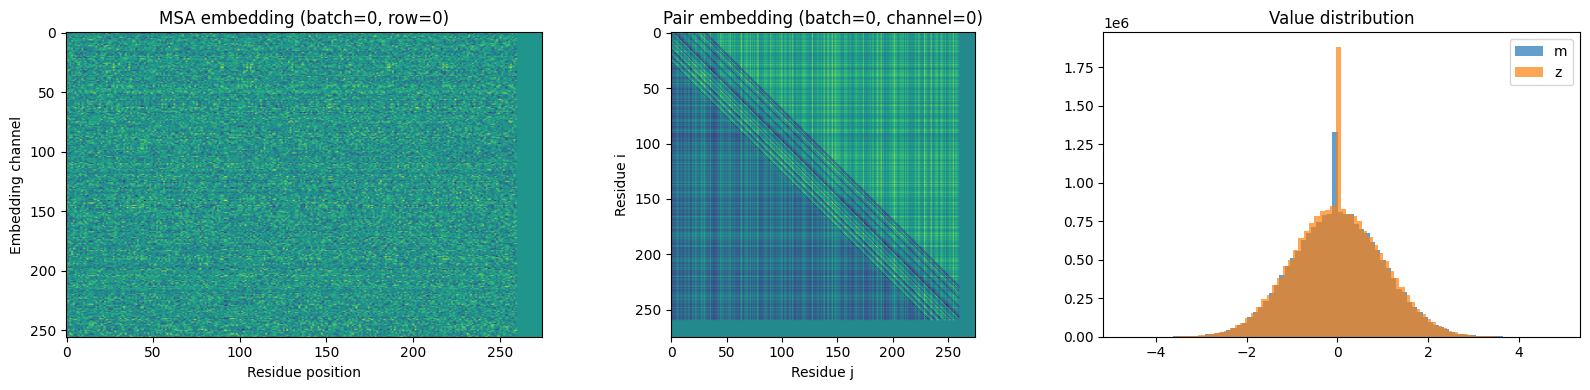

In [30]:
import torch
import matplotlib.pyplot as plt

# -------------------------
# fake batch
# -------------------------
B = 2
N_msa = 128
L = 275
n_tokens = 23
pad_idx = 0

seq_tokens = torch.randint(1, n_tokens, (B, L))
msa_tokens = torch.randint(1, n_tokens, (B, N_msa, L))

seq_mask = torch.ones(B, L, dtype=torch.float32)
msa_mask = torch.ones(B, N_msa, L, dtype=torch.float32)

# algunos pads
seq_tokens[0, -15:] = pad_idx
seq_mask[0, -15:] = 0.0
msa_tokens[0, :, -15:] = pad_idx
msa_mask[0, :, -15:] = 0.0

model = InputEmbedder(
    n_tokens=n_tokens,
    c_m=256,
    c_z=128,
    c_s=256,
    max_relpos=32,
    pad_idx=pad_idx)

with torch.no_grad():
    m, z = model(
        seq_tokens=seq_tokens,
        msa_tokens=msa_tokens,
        seq_mask=seq_mask,
        msa_mask=msa_mask)

print("m shape:", m.shape)   # [B, N_msa, L, c_m]
print("z shape:", z.shape)   # [B, L, L, c_z]


b = 0
msa_row = 0
z_channel = 0

m_img = m[b, msa_row].cpu()          # [L, c_m]
z_img = z[b, :, :, z_channel].cpu()  # [L, L]

plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.imshow(m_img.T, aspect='auto')
plt.title(f"MSA embedding (batch={b}, row={msa_row})")
plt.xlabel("Residue position")
plt.ylabel("Embedding channel")

plt.subplot(1, 3, 2)
plt.imshow(z_img)
plt.title(f"Pair embedding (batch={b}, channel={z_channel})")
plt.xlabel("Residue j")
plt.ylabel("Residue i")

plt.subplot(1, 3, 3)
plt.hist(m.flatten().cpu().numpy(), bins=80, alpha=0.7, label="m")
plt.hist(z.flatten().cpu().numpy(), bins=80, alpha=0.7, label="z")
plt.title("Value distribution")
plt.legend()

plt.tight_layout()
plt.show()

# Helpers for the entire model

In [35]:
def zero_init_linear(linear: nn.Linear):
    nn.init.zeros_(linear.weight)
    if linear.bias is not None:
        nn.init.zeros_(linear.bias)


def init_gate_linear(linear: nn.Linear):
    nn.init.zeros_(linear.weight)
    if linear.bias is not None:
        nn.init.ones_(linear.bias)


class MSATransition(nn.Module):
    def __init__(self, c_m=256, expansion=4):
        super().__init__()
        self.layer_norm = nn.LayerNorm(c_m)
        self.linear_1 = nn.Linear(c_m, expansion * c_m)
        self.act = nn.SiLU()
        self.linear_2 = nn.Linear(expansion * c_m, c_m)

        # zero-init final projection
        zero_init_linear(self.linear_2)

    def forward(self, m, msa_mask=None):
        x = self.layer_norm(m)
        x = self.linear_1(x)
        x = self.act(x)
        x = self.linear_2(x)

        if msa_mask is not None:
            x = x * msa_mask.unsqueeze(-1)
        return x

class PairTransition(nn.Module):
    def __init__(self, c_z=128, expansion=4):
        super().__init__()
        self.layer_norm = nn.LayerNorm(c_z)
        self.linear_1 = nn.Linear(c_z, expansion * c_z)
        self.act = nn.SiLU()
        self.linear_2 = nn.Linear(expansion * c_z, c_z)

        # zero-init final projection
        zero_init_linear(self.linear_2)

    def forward(self, z, pair_mask=None):
        x = self.layer_norm(z)
        x = self.linear_1(x)
        x = self.act(x)
        x = self.linear_2(x)

        if pair_mask is not None:
            x = x * pair_mask.unsqueeze(-1)
        return x

# AlphaFold2 DropOut Canonical

In [36]:
class SharedDropout(nn.Module):
    """Dropout with a mask shared across a chosen tensor dimension."""

    def __init__(self, p: float, shared_dim: int):
        super().__init__()
        if not (0.0 <= p < 1.0):
            raise ValueError(f"dropout probability must be in [0, 1), got {p}")
        self.p = float(p)
        self.shared_dim = int(shared_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if (not self.training) or self.p == 0.0:
            return x

        ndim = x.ndim
        shared_dim = self.shared_dim if self.shared_dim >= 0 else ndim + self.shared_dim
        if not (0 <= shared_dim < ndim):
            raise ValueError(
                f"shared_dim={self.shared_dim} is invalid for tensor with ndim={ndim}"
            )

        mask_shape = list(x.shape)
        mask_shape[shared_dim] = 1

        keep_prob = 1.0 - self.p
        mask = x.new_empty(mask_shape).bernoulli_(keep_prob) / keep_prob
        return x * mask


class DropoutRowwise(SharedDropout):
    """Share a dropout mask across the row dimension."""

    def __init__(self, p: float):
        super().__init__(p=p, shared_dim=-3)


class DropoutColumnwise(SharedDropout):
    """Share a dropout mask across the column dimension."""

    def __init__(self, p: float):
        super().__init__(p=p, shared_dim=-2)


<hr style="border:2px solid #2c3e50; border-radius: 5px;">

<hr style="border: 0; border-top: 2px dashed #abb2bf;">

# **EVOFORMER**

---

## OuterProductMean (Connection between m and z in evoformer)

In [32]:
class OuterProductMean(nn.Module):
    """
    AlphaFold2-style Outer Product Mean.

    Input:
        m:        [B, N_msa, L, c_m]
        msa_mask: [B, N_msa, L]   (optional)

    Output:
        z_update: [B, L, L, c_z]
    """

    def __init__(self, c_m=256, c_hidden=32, c_z=128):
        super().__init__()

        self.layer_norm = nn.LayerNorm(c_m)

        self.linear_a = nn.Linear(c_m, c_hidden)
        self.linear_b = nn.Linear(c_m, c_hidden)

        self.output_linear = nn.Linear(c_hidden * c_hidden, c_z)

    def forward(self, m, msa_mask=None):
        """
        m: [B, N, L, c_m]
        msa_mask: [B, N, L]
        """
        B, N, L, _ = m.shape

        m = self.layer_norm(m)

        a = self.linear_a(m)   # [B, N, L, c_hidden]
        b = self.linear_b(m)   # [B, N, L, c_hidden]

        if msa_mask is not None:
            mask = msa_mask.unsqueeze(-1)   # [B, N, L, 1]
            a = a * mask
            b = b * mask

        # Outer product mean over MSA dimension N
        # result: [B, L, L, c_hidden, c_hidden]
        outer = torch.einsum('bnic,bnjd->bijcd', a, b)

        if msa_mask is not None:
            # solo promedia secuencias válidas para el par (i,j)
            pair_mask = torch.einsum('bni,bnj->bij', msa_mask, msa_mask)  # [B, L, L]
            outer = outer / (pair_mask[..., None, None] + 1e-8)
        else:
            outer = outer / N

        outer = outer.reshape(B, L, L, -1)
        z_update = self.output_linear(outer)

        return z_update

In [34]:
B, N, L, c_m = 2, 128, 275, 256
c_hidden, c_z = 32, 128

m = torch.randn(B, N, L, c_m)
msa_mask = torch.ones(B, N, L)

opm = OuterProductMean(c_m=c_m, c_hidden=c_hidden, c_z=c_z)
z_update = opm(m, msa_mask)

print("z_update shape:", z_update.shape)  # [B, L, L, c_z]

with torch.no_grad():
    m, z = model(
        seq_tokens=seq_tokens,
        msa_tokens=msa_tokens,
        seq_mask=seq_mask,
        msa_mask=msa_mask,)

opm = OuterProductMean(c_m=256, c_hidden=32, c_z=128)
z_update = opm(m, msa_mask)

print("m:", m.shape)
print("z:", z.shape)
print("z_update:", z_update.shape)

z = z + z_update
print("z after update:", z.shape)

z_update shape: torch.Size([2, 275, 275, 128])
m: torch.Size([2, 128, 275, 256])
z: torch.Size([2, 275, 275, 128])
z_update: torch.Size([2, 275, 275, 128])
z after update: torch.Size([2, 275, 275, 128])


---

## Triangle Multiplication (First part of the Evoformer for z)

In [38]:
import math

class TriangleMultiplicationOutgoing(nn.Module):
    """
    AlphaFold2-style Triangle Multiplicative Update (Outgoing).

    Input:
        z:         [B, L, L, c_z]
        pair_mask: [B, L, L]   (optional)

    Output:
        z_update:  [B, L, L, c_z]
    """

    def __init__(self, c_z=128, c_hidden=128, dropout=0.1, eps=1e-8):
        super().__init__()

        self.c_hidden = c_hidden
        self.eps = eps

        self.input_layer_norm = nn.LayerNorm(c_z)

        self.linear_a_p = nn.Linear(c_z, c_hidden)
        self.linear_b_p = nn.Linear(c_z, c_hidden)

        self.linear_a_g = nn.Linear(c_z, c_hidden)
        self.linear_b_g = nn.Linear(c_z, c_hidden)

        self.output_layer_norm = nn.LayerNorm(c_hidden)
        self.output_linear = nn.Linear(c_hidden, c_z)
        self.output_gate = nn.Linear(c_z, c_z)

        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Identity()
        init_gate_linear(self.linear_a_g)
        init_gate_linear(self.linear_b_g)
        init_gate_linear(self.output_gate)

    def forward(self, z, pair_mask=None):
        """
        z: [B, L, L, c_z]
        pair_mask: [B, L, L]
        """
        z_norm = self.input_layer_norm(z)

        a = self.linear_a_p(z_norm) * self.sigmoid(self.linear_a_g(z_norm))
        b = self.linear_b_p(z_norm) * self.sigmoid(self.linear_b_g(z_norm))

        if pair_mask is not None:
            mask = pair_mask.unsqueeze(-1).to(z.dtype)
            a = a * mask
            b = b * mask

        # outgoing: aggregate through k using (i,k) and (j,k)
        # x[b,i,j,c] = sum_k a[b,i,k,c] * b[b,j,k,c]
        x = torch.einsum("bikc,bjkc->bijc", a, b)

        # normalize by effective number of valid k's
        if pair_mask is not None:
            valid_k = torch.einsum("bik,bjk->bij", pair_mask, pair_mask).to(z.dtype)
            x = x / torch.sqrt(valid_k.unsqueeze(-1).clamp_min(1.0))
        else:
            L = z.shape[1]
            x = x / math.sqrt(L)

        x = self.output_layer_norm(x)
        x = self.output_linear(x)

        gate = self.sigmoid(self.output_gate(z_norm))
        x = x * gate
        x = self.dropout(x)

        if pair_mask is not None:
            x = x * pair_mask.unsqueeze(-1).to(z.dtype)

        return x


class TriangleMultiplicationIncoming(nn.Module):
    """
    AlphaFold2-style Triangle Multiplicative Update (Incoming).

    Input:
        z:         [B, L, L, c_z]
        pair_mask: [B, L, L]   (optional)

    Output:
        z_update:  [B, L, L, c_z]
    """

    def __init__(self, c_z=128, c_hidden=128, dropout=0.1, eps=1e-8):
        super().__init__()

        self.c_hidden = c_hidden
        self.eps = eps

        self.input_layer_norm = nn.LayerNorm(c_z)

        self.linear_a_p = nn.Linear(c_z, c_hidden)
        self.linear_b_p = nn.Linear(c_z, c_hidden)

        self.linear_a_g = nn.Linear(c_z, c_hidden)
        self.linear_b_g = nn.Linear(c_z, c_hidden)

        self.output_layer_norm = nn.LayerNorm(c_hidden)
        self.output_linear = nn.Linear(c_hidden, c_z)
        self.output_gate = nn.Linear(c_z, c_z)

        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Identity()
        init_gate_linear(self.linear_a_g)
        init_gate_linear(self.linear_b_g)
        init_gate_linear(self.output_gate)

    def forward(self, z, pair_mask=None):
        """
        z: [B, L, L, c_z]
        pair_mask: [B, L, L]
        """
        z_norm = self.input_layer_norm(z)

        a = self.linear_a_p(z_norm) * self.sigmoid(self.linear_a_g(z_norm))  # [B,L,L,c_h]
        b = self.linear_b_p(z_norm) * self.sigmoid(self.linear_b_g(z_norm))  # [B,L,L,c_h]

        if pair_mask is not None:
            mask = pair_mask.unsqueeze(-1).to(z.dtype)
            a = a * mask
            b = b * mask

        # incoming: aggregate through k using (k,i) and (k,j)
        # x[b,i,j,c] = sum_k a[b,k,i,c] * b[b,k,j,c]
        x = torch.einsum("bkic,bkjc->bijc", a, b)

        # normalize by effective number of valid k's
        if pair_mask is not None:
            valid_k = torch.einsum("bki,bkj->bij", pair_mask, pair_mask).to(z.dtype)
            x = x / torch.sqrt(valid_k.unsqueeze(-1).clamp_min(1.0))
        else:
            L = z.shape[1]
            x = x / math.sqrt(L)

        x = self.output_layer_norm(x)
        x = self.output_linear(x)

        gate = self.sigmoid(self.output_gate(z_norm))
        x = x * gate
        x = self.dropout(x)

        if pair_mask is not None:
            x = x * pair_mask.unsqueeze(-1).to(z.dtype)

        return x

## Triangle Attention for Evoformer (second part for z)

In [39]:
class TriangleAttentionStartingNode(nn.Module):
    """
    AlphaFold2-style Triangle Attention (Starting Node).

    Input:
        z:         [B, L, L, c_z]
        pair_mask: [B, L, L]   (optional)

    Output:
        z_update:  [B, L, L, c_z]

    Idea:
        For each fixed starting node i, attention is performed over k on z[i, k]
        to update z[i, j]. Equivalently, for each row i we do attention across
        the second residue index.
    """

    def __init__(self, c_z=128, num_heads=4, c_hidden=32):
        super().__init__()
        assert c_z == num_heads * c_hidden, "Require c_z = num_heads * c_hidden"

        self.c_z = c_z
        self.num_heads = num_heads
        self.c_hidden = c_hidden

        self.input_layer_norm = nn.LayerNorm(c_z)

        self.linear_q = nn.Linear(c_z, num_heads * c_hidden, bias=False)
        self.linear_k = nn.Linear(c_z, num_heads * c_hidden, bias=False)
        self.linear_v = nn.Linear(c_z, num_heads * c_hidden, bias=False)

        # pair bias per head
        self.linear_bias = nn.Linear(c_z, num_heads, bias=False)

        # gating
        self.linear_gate = nn.Linear(c_z, num_heads * c_hidden)

        self.output_linear = nn.Linear(num_heads * c_hidden, c_z)
        self.sigmoid = nn.Sigmoid()
        init_gate_linear(self.linear_gate)

    def forward(self, z, pair_mask=None):
        """
        z: [B, L, L, c_z]
        pair_mask: [B, L, L]
        """
        B, L, _, _ = z.shape
        z_norm = self.input_layer_norm(z)

        q = self.linear_q(z_norm).view(B, L, L, self.num_heads, self.c_hidden)
        k = self.linear_k(z_norm).view(B, L, L, self.num_heads, self.c_hidden)
        v = self.linear_v(z_norm).view(B, L, L, self.num_heads, self.c_hidden)

        bias = self.linear_bias(z_norm)

        # attention logits over k for each fixed (i, j)
        # q from z[i,j], keys from z[i,k]
        # result: [B, i, h, j, k]
        logits = torch.einsum("bijhc,bikhc->bihjk", q, k) / math.sqrt(self.c_hidden)

        # add pair bias from candidate key edge (i,k)
        key_bias = bias.permute(0, 1, 3, 2).unsqueeze(3)
        logits = logits + key_bias

        if pair_mask is not None:
            # key mask on (i,k)
            key_mask = pair_mask.unsqueeze(2).unsqueeze(3)
            logits = logits.masked_fill(key_mask == 0, -1e9)

        attn = torch.softmax(logits, dim=-1)  # over k

        # weighted sum of values z[i,k]
        # [B, i, j, h, c]
        out = torch.einsum("bihjk,bikhc->bijhc", attn, v)

        gate = self.sigmoid(self.linear_gate(z_norm)).view(B, L, L, self.num_heads, self.c_hidden)
        out = out * gate

        out = out.reshape(B, L, L, self.num_heads * self.c_hidden)
        out = self.output_linear(out)

        if pair_mask is not None:
            out = out * pair_mask.unsqueeze(-1)

        return out


class TriangleAttentionEndingNode(nn.Module):
    """
    AlphaFold2-style Triangle Attention (Ending Node).

    Input:
        z:         [B, L, L, c_z]
        pair_mask: [B, L, L]   (optional)

    Output:
        z_update:  [B, L, L, c_z]

    Idea:
        For each fixed ending node j, attention is performed over k on z[k, j]
        to update z[i, j].
    """

    def __init__(self, c_z=128, num_heads=4, c_hidden=32):
        super().__init__()
        assert c_z == num_heads * c_hidden, "Require c_z = num_heads * c_hidden"

        self.c_z = c_z
        self.num_heads = num_heads
        self.c_hidden = c_hidden

        self.input_layer_norm = nn.LayerNorm(c_z)

        self.linear_q = nn.Linear(c_z, num_heads * c_hidden, bias=False)
        self.linear_k = nn.Linear(c_z, num_heads * c_hidden, bias=False)
        self.linear_v = nn.Linear(c_z, num_heads * c_hidden, bias=False)

        self.linear_bias = nn.Linear(c_z, num_heads, bias=False)
        self.linear_gate = nn.Linear(c_z, num_heads * c_hidden)

        self.output_linear = nn.Linear(num_heads * c_hidden, c_z)
        self.sigmoid = nn.Sigmoid()
        init_gate_linear(self.linear_gate)

    def forward(self, z, pair_mask=None):
        """
        z: [B, L, L, c_z]
        pair_mask: [B, L, L]
        """
        B, L, _, _ = z.shape
        z_norm = self.input_layer_norm(z)

        q = self.linear_q(z_norm).view(B, L, L, self.num_heads, self.c_hidden)
        k = self.linear_k(z_norm).view(B, L, L, self.num_heads, self.c_hidden)
        v = self.linear_v(z_norm).view(B, L, L, self.num_heads, self.c_hidden)

        bias = self.linear_bias(z_norm)  # [B,i,j,h]

        # For each fixed j, query z[i,j] attends over keys z[k,j]
        # logits: [B, j, h, i, k]
        logits = torch.einsum("bijhc,bkjhc->bhijk", q, k) / math.sqrt(self.c_hidden)
        logits = logits.permute(0, 3, 1, 2, 4)  # [B, j, h, i, k]

        # bias from candidate key edge (k,j)
        key_bias = bias.permute(0, 2, 3, 1).unsqueeze(3)  # [B, j, h, 1, k]
        logits = logits + key_bias

        if pair_mask is not None:
            # mask over key edges (k,j)
            key_mask = pair_mask.transpose(1, 2).unsqueeze(2).unsqueeze(3)  # [B, j, 1, 1, k]
            logits = logits.masked_fill(key_mask == 0, -1e9)

        attn = torch.softmax(logits, dim=-1)  # over k

        # values are z[k,j]
        v_t = v.permute(0, 2, 1, 3, 4)  # [B, j, k, h, c]
        out = torch.einsum("bjhik,bjkhc->bijhc", attn, v_t)

        gate = self.sigmoid(self.linear_gate(z_norm)).view(B, L, L, self.num_heads, self.c_hidden)
        out = out * gate

        out = out.reshape(B, L, L, self.num_heads * self.c_hidden)
        out = self.output_linear(out)

        if pair_mask is not None:
            out = out * pair_mask.unsqueeze(-1)

        return out

In [40]:
B, L, c_z = 2, 275, 128
z = torch.randn(B, L, L, c_z)
pair_mask = torch.ones(B, L, L)

tri_attn_start = TriangleAttentionStartingNode(c_z=128, num_heads=4, c_hidden=32)
z_update = tri_attn_start(z, pair_mask)

print("z_update shape:", z_update.shape)   # [B, L, L, 128]

B, L, c_z = 2, 275, 128
z = torch.randn(B, L, L, c_z)
pair_mask = torch.ones(B, L, L)

tri_attn_end = TriangleAttentionEndingNode(c_z=128, num_heads=4, c_hidden=32)
z_update = tri_attn_end(z, pair_mask)

print("z_update shape:", z_update.shape)   # [B, L, L, 128]

tri_attn_start = TriangleAttentionStartingNode(c_z=128, num_heads=4, c_hidden=32)
z = z + tri_attn_start(z, pair_mask)

print("z shape after starting-node attention:", z.shape)

tri_attn_end = TriangleAttentionEndingNode(c_z=128, num_heads=4, c_hidden=32)
z = z + tri_attn_end(z, pair_mask)

print("z shape after ending-node attention:", z.shape)

z_update shape: torch.Size([2, 275, 275, 128])
z_update shape: torch.Size([2, 275, 275, 128])
z shape after starting-node attention: torch.Size([2, 275, 275, 128])
z shape after ending-node attention: torch.Size([2, 275, 275, 128])


## Column and Row Attention (for m in the Evoformer)

In [42]:
class MSAColumnAttention(nn.Module):
    """
    AlphaFold2-style MSA Column Attention.

    Inputs:
        m:        [B, N, L, c_m]
        msa_mask: [B, N, L]   (optional)

    Output:
        m_update: [B, N, L, c_m]
    """

    def __init__(self, c_m=256, num_heads=8, c_hidden=32):
        super().__init__()
        assert c_m == num_heads * c_hidden, "Require c_m = num_heads * c_hidden"

        self.c_m = c_m
        self.num_heads = num_heads
        self.c_hidden = c_hidden

        self.layer_norm = nn.LayerNorm(c_m)

        self.linear_q = nn.Linear(c_m, num_heads * c_hidden, bias=False)
        self.linear_k = nn.Linear(c_m, num_heads * c_hidden, bias=False)
        self.linear_v = nn.Linear(c_m, num_heads * c_hidden, bias=False)

        self.linear_gate = nn.Linear(c_m, num_heads * c_hidden)
        self.output_linear = nn.Linear(num_heads * c_hidden, c_m)

        self.sigmoid = nn.Sigmoid()
        init_gate_linear(self.linear_gate)

    def forward(self, m, msa_mask=None):
        """
        m: [B, N, L, c_m]
        msa_mask: [B, N, L]
        """
        B, N, L, _ = m.shape

        m_norm = self.layer_norm(m)

        q = self.linear_q(m_norm).view(B, N, L, self.num_heads, self.c_hidden)
        k = self.linear_k(m_norm).view(B, N, L, self.num_heads, self.c_hidden)
        v = self.linear_v(m_norm).view(B, N, L, self.num_heads, self.c_hidden)

        # attend over MSA sequences n for each residue position l
        # logits: [B, L, H, N_q, N_k]
        logits = torch.einsum("bnlhc,bmlhc->blhnm", q, k) / math.sqrt(self.c_hidden)

        if msa_mask is not None:
            key_mask = msa_mask.permute(0, 2, 1).unsqueeze(2).unsqueeze(3)  # [B,L,1,1,N]
            logits = logits.masked_fill(key_mask == 0, -1e9)

        attn = torch.softmax(logits, dim=-1)

        v_t = v.permute(0, 2, 1, 3, 4)  # [B, L, N, H, C]
        out = torch.einsum("blhnm,blmhc->bnlhc", attn, v_t)

        gate = self.sigmoid(self.linear_gate(m_norm)).view(B, N, L, self.num_heads, self.c_hidden)
        out = out * gate

        out = out.reshape(B, N, L, self.num_heads * self.c_hidden)
        out = self.output_linear(out)

        if msa_mask is not None:
            out = out * msa_mask.unsqueeze(-1)

        return out

class MSARowAttentionWithPairBias(nn.Module):
    """
    AlphaFold2-style MSA Row Attention with Pair Bias.

    Inputs:
        m:        [B, N, L, c_m]
        z:        [B, L, L, c_z]
        msa_mask: [B, N, L]   (optional)

    Output:
        m_update: [B, N, L, c_m]
    """

    def __init__(self, c_m=256, c_z=128, num_heads=8, c_hidden=32):
        super().__init__()
        assert c_m == num_heads * c_hidden, "Require c_m = num_heads * c_hidden"

        self.c_m = c_m
        self.c_z = c_z
        self.num_heads = num_heads
        self.c_hidden = c_hidden

        self.m_layer_norm = nn.LayerNorm(c_m)
        self.z_layer_norm = nn.LayerNorm(c_z)

        self.linear_q = nn.Linear(c_m, num_heads * c_hidden, bias=False)
        self.linear_k = nn.Linear(c_m, num_heads * c_hidden, bias=False)
        self.linear_v = nn.Linear(c_m, num_heads * c_hidden, bias=False)

        # pair bias added to logits before softmax
        self.linear_bias = nn.Linear(c_z, num_heads, bias=False)

        self.linear_gate = nn.Linear(c_m, num_heads * c_hidden)
        self.output_linear = nn.Linear(num_heads * c_hidden, c_m)

        self.sigmoid = nn.Sigmoid()
        init_gate_linear(self.linear_gate)

    def forward(self, m, z, msa_mask=None):
        """
        m: [B, N, L, c_m]
        z: [B, L, L, c_z]
        msa_mask: [B, N, L]
        """
        B, N, L, _ = m.shape

        m_norm = self.m_layer_norm(m)
        z_norm = self.z_layer_norm(z)

        q = self.linear_q(m_norm).view(B, N, L, self.num_heads, self.c_hidden)
        k = self.linear_k(m_norm).view(B, N, L, self.num_heads, self.c_hidden)
        v = self.linear_v(m_norm).view(B, N, L, self.num_heads, self.c_hidden)

        # [B, L, L, H]
        pair_bias = self.linear_bias(z_norm)

        # attention over residue positions j for each row n
        # logits: [B, N, H, I, J]
        logits = torch.einsum("bnihc,bnjhc->bnhij", q, k) / math.sqrt(self.c_hidden)

        # add pair bias before softmax
        logits = logits + pair_bias.permute(0, 3, 1, 2).unsqueeze(1)  # [B,1,H,I,J]

        if msa_mask is not None:
            key_mask = msa_mask.unsqueeze(2).unsqueeze(3)  # [B,N,1,1,L]
            logits = logits.masked_fill(key_mask == 0, -1e9)

        attn = torch.softmax(logits, dim=-1)

        out = torch.einsum("bnhij,bnjhc->bnihc", attn, v)

        gate = self.sigmoid(self.linear_gate(m_norm)).view(B, N, L, self.num_heads, self.c_hidden)
        out = out * gate

        out = out.reshape(B, N, L, self.num_heads * self.c_hidden)
        out = self.output_linear(out)

        if msa_mask is not None:
            out = out * msa_mask.unsqueeze(-1)

        return out

In [43]:
B, N, L = 2, 128, 275
c_m, c_z = 256, 128

m = torch.randn(B, N, L, c_m)
z = torch.randn(B, L, L, c_z)
msa_mask = torch.ones(B, N, L)

row_attn = MSARowAttentionWithPairBias(c_m=256, c_z=128, num_heads=8, c_hidden=32)
col_attn = MSAColumnAttention(c_m=256, num_heads=8, c_hidden=32)

m_row = row_attn(m, z, msa_mask)
m_col = col_attn(m, msa_mask)

print("m_row:", m_row.shape)  # [B, N, L, 256]
print("m_col:", m_col.shape)  # [B, N, L, 256]

m_row: torch.Size([2, 128, 275, 256])
m_col: torch.Size([2, 128, 275, 256])


---

# Template Stack

In [44]:
def normalize_template_mask(
    template_mask,
    *,
    batch_size=None,
    num_templates=None,
    length=None,
    device=None,
    dtype=None):

    if template_mask is None:
        if batch_size is None or num_templates is None or length is None:
            return None
        if dtype is None:
            dtype = torch.float32
        return torch.ones(batch_size, num_templates, length, device=device, dtype=dtype)

    if template_mask.ndim == 2:
        if length is None:
            raise ValueError("length is required when template_mask has shape [B, T].")
        return template_mask[:, :, None].expand(-1, -1, length)

    if template_mask.ndim == 3:
        return template_mask

    raise ValueError("template_mask must have shape [B, T] or [B, T, L].")


class TemplatePairStackBlock(nn.Module):
    def __init__(self, c_t=64, num_heads=4, c_hidden_att=16, c_hidden_mul=64, transition_expansion=2, dropout=0.25):
        super().__init__()
        self.tri_attn_start = TriangleAttentionStartingNode(c_z=c_t, num_heads=num_heads, c_hidden=c_hidden_att)
        self.tri_attn_end = TriangleAttentionEndingNode(c_z=c_t, num_heads=num_heads, c_hidden=c_hidden_att)
        self.tri_mul_out = TriangleMultiplicationOutgoing(c_z=c_t, c_hidden=c_hidden_mul)
        self.tri_mul_in = TriangleMultiplicationIncoming(c_z=c_t, c_hidden=c_hidden_mul)
        self.pair_transition = PairTransition(c_z=c_t, expansion=transition_expansion)
        self.row_dropout = DropoutRowwise(dropout)
        self.col_dropout = DropoutColumnwise(dropout)
        zero_init_linear(self.tri_attn_start.output_linear)
        zero_init_linear(self.tri_attn_end.output_linear)
        zero_init_linear(self.tri_mul_out.output_linear)
        zero_init_linear(self.tri_mul_in.output_linear)

    def forward(self, t, pair_mask=None):
        t = t + self.row_dropout(self.tri_attn_start(t, pair_mask))
        t = t + self.col_dropout(self.tri_attn_end(t, pair_mask))
        t = t + self.row_dropout(self.tri_mul_out(t, pair_mask))
        t = t + self.row_dropout(self.tri_mul_in(t, pair_mask))
        t = t + self.pair_transition(t, pair_mask)
        return t


class TemplatePairStack(nn.Module):
    """
    Canonical AF2-style TemplatePairStack:
      2 blocks + final LayerNorm.
    """

    def __init__(self, c_t=64, num_blocks=2, num_heads=4, c_hidden_att=16, c_hidden_mul=64, transition_expansion=2, dropout=0.25):
        super().__init__()
        self.blocks = nn.ModuleList([
            TemplatePairStackBlock(
                c_t=c_t,
                num_heads=num_heads,
                c_hidden_att=c_hidden_att,
                c_hidden_mul=c_hidden_mul,
                transition_expansion=transition_expansion,
                dropout=dropout,
            )
            for _ in range(num_blocks)
        ])
        self.final_ln = nn.LayerNorm(c_t)

    def forward(self, t, pair_mask=None):
        for block in self.blocks:
            t = block(t, pair_mask=pair_mask)
        return self.final_ln(t)


class TemplatePointwiseAttention(nn.Module):
    """
    AF2 Algorithm 17.

    Inputs
    ------
    t : [B, N_templ, L, L, c_t]
        Processed template pair representations.
    z : [B, L, L, c_z]
        Current pair representation.

    Returns
    -------
    dz : [B, L, L, c_z]
        Template-derived update to z.
    """

    def __init__(self, c_z=128, c_t=64, num_heads=4, c_hidden=16):
        super().__init__()
        self.num_heads = num_heads
        self.c_hidden = c_hidden

        self.z_layer_norm = nn.LayerNorm(c_z)
        self.t_layer_norm = nn.LayerNorm(c_t)
        self.linear_q = nn.Linear(c_z, num_heads * c_hidden, bias=False)
        self.linear_k = nn.Linear(c_t, num_heads * c_hidden, bias=False)
        self.linear_v = nn.Linear(c_t, num_heads * c_hidden, bias=False)
        self.output_linear = nn.Linear(num_heads * c_hidden, c_z)
        zero_init_linear(self.output_linear)

    def forward(self, t, z, template_mask=None):
        B, T, L, _, _ = t.shape
        H = self.num_heads
        C = self.c_hidden

        z_norm = self.z_layer_norm(z)
        t_norm = self.t_layer_norm(t)

        q = self.linear_q(z_norm).view(B, L, L, H, C)
        k = self.linear_k(t_norm).view(B, T, L, L, H, C)
        v = self.linear_v(t_norm).view(B, T, L, L, H, C)

        logits = torch.einsum("bijhc,btijhc->btijh", q, k) / (C ** 0.5)
        pair_mask = None

        if template_mask is not None:
            template_mask = normalize_template_mask(template_mask, length=L)
            pair_mask = template_mask[:, :, :, None] * template_mask[:, :, None, :]  # [B,T,L,L]
            logits = logits.masked_fill(pair_mask.unsqueeze(-1) == 0, -1e9)

        attn = torch.softmax(logits, dim=1)
        if pair_mask is not None:
            attn = attn * pair_mask.unsqueeze(-1).to(attn.dtype)
            attn = attn / attn.sum(dim=1, keepdim=True).clamp_min(1e-8)

        out = torch.einsum("btijh,btijhc->bijhc", attn, v)
        out = out.reshape(B, L, L, H * C)
        return self.output_linear(out)


class TemplateAngleEmbedder(nn.Module):
    """
    Small MLP used to embed template_angle_feat to c_m channels.
    """

    def __init__(self, angle_dim=51, c_m=256):
        super().__init__()
        self.linear_1 = nn.Linear(angle_dim, c_m)
        self.linear_2 = nn.Linear(c_m, c_m)

    def forward(self, x):
        return self.linear_2(F.relu(self.linear_1(x)))


def augment_msa_mask_with_template_mask(msa_mask, template_mask, *, length=None):
    """
    Helper for canonical template-angle concatenation.

    Inputs
    ------
    msa_mask : [B, N_msa, L] or None
    template_mask : [B, N_templ, L] or None

    Returns
    -------
    new_msa_mask : [B, N_msa + N_templ, L] or None
    """
    if template_mask is None:
        return msa_mask
    if length is None:
        if msa_mask is None:
            raise ValueError("length is required when msa_mask is None and template_mask is provided.")
        length = msa_mask.shape[-1]

    template_mask = normalize_template_mask(template_mask, length=length)
    if msa_mask is None:
        return template_mask
    return torch.cat([msa_mask, template_mask], dim=1)


class TemplateStack(nn.Module):
    """
    AF2-style template module.

    It updates:
      - m by concatenating embedded template_angle_feat rows
      - z by adding TemplatePointwiseAttention over TemplatePairStack outputs

    Inputs
    ------
    m : [B, N_msa, L, c_m]
    z : [B, L, L, c_z]

    template_angle_feat : [B, N_templ, L, angle_dim] or None
    template_pair_feat  : [B, N_templ, L, L, pair_dim] or None
    template_mask       : [B, N_templ, L] or None

    Returns
    -------
    m : [B, N_msa + N_templ, L, c_m] if angle feats are provided, else unchanged
    z : [B, L, L, c_z]
    """

    def __init__(
        self,
        c_m=256,
        c_z=128,
        template_angle_dim=51,
        template_pair_dim=88,
        c_t=64,
        num_blocks=2,
        num_heads=4,
        c_hidden_att=16,
        c_hidden_mul=64,
        transition_expansion=2,
        dropout=0.25):

        super().__init__()
        self.angle_embedder = TemplateAngleEmbedder(angle_dim=template_angle_dim, c_m=c_m)
        self.template_pair_proj = nn.Linear(template_pair_dim, c_t)
        self.template_pair_stack = TemplatePairStack(
            c_t=c_t,
            num_blocks=num_blocks,
            num_heads=num_heads,
            c_hidden_att=c_hidden_att,
            c_hidden_mul=c_hidden_mul,
            transition_expansion=transition_expansion,
            dropout=dropout)

        self.template_pointwise_attention = TemplatePointwiseAttention(
            c_z=c_z,
            c_t=c_t,
            num_heads=num_heads,
            c_hidden=c_hidden_att)

    def forward(
        self,
        m,
        z,
        template_angle_feat=None,
        template_pair_feat=None,
        template_mask=None):

        # angle path: concat to MSA rows
        if template_angle_feat is not None:
            B, T_angle, L, _ = template_angle_feat.shape
            angle_mask = normalize_template_mask(
                template_mask,
                batch_size=B,
                num_templates=T_angle,
                length=L,
                device=template_angle_feat.device,
                dtype=template_angle_feat.dtype)

            angle_rows = self.angle_embedder(template_angle_feat)  # [B,T,L,c_m]
            angle_rows = angle_rows * angle_mask.unsqueeze(-1)
            m = torch.cat([m, angle_rows], dim=1)

        # pair path: process each template independently, then attend across templates into z
        if template_pair_feat is not None:
            B, T, L, _, _ = template_pair_feat.shape
            t = self.template_pair_proj(template_pair_feat)  # [B,T,L,L,c_t]

            t_out = []
            template_row_mask = normalize_template_mask(
                template_mask,
                batch_size=B,
                num_templates=T,
                length=L,
                device=template_pair_feat.device,
                dtype=template_pair_feat.dtype)

            pair_mask = template_row_mask[:, :, :, None] * template_row_mask[:, :, None, :]  # [B,T,L,L]

            for ti in range(T):
                t_i = t[:, ti, :, :, :]
                pm_i = pair_mask[:, ti, :, :]
                t_i = self.template_pair_stack(t_i, pair_mask=pm_i)
                t_out.append(t_i)

            t = torch.stack(t_out, dim=1)  # [B,T,L,L,c_t]
            z = z + self.template_pointwise_attention(t, z, template_mask=template_row_mask)

        return m, z

# Extra Msa

In [45]:
class MSAColumnGlobalAttention(nn.Module):
    """
    AF2 Algorithm 19.

    Global query over sequences at each residue position.
    """

    def __init__(self, c_m=64, num_heads=8, c_hidden=8):
        super().__init__()
        assert c_m == num_heads * c_hidden, "Require c_m = num_heads * c_hidden"

        self.num_heads = num_heads
        self.c_hidden = c_hidden

        self.layer_norm = nn.LayerNorm(c_m)
        self.linear_q = nn.Linear(c_m, num_heads * c_hidden, bias=False)
        self.linear_k = nn.Linear(c_m, num_heads * c_hidden, bias=False)
        self.linear_v = nn.Linear(c_m, num_heads * c_hidden, bias=False)
        self.linear_g = nn.Linear(c_m, num_heads * c_hidden, bias=True)
        self.output_linear = nn.Linear(num_heads * c_hidden, c_m)
        init_gate_linear(self.linear_g)
        zero_init_linear(self.output_linear)

    def forward(self, m, msa_mask=None):
        B, S, L, _ = m.shape
        H = self.num_heads
        C = self.c_hidden

        x = self.layer_norm(m)
        k = self.linear_k(x).view(B, S, L, H, C)
        v = self.linear_v(x).view(B, S, L, H, C)
        g = torch.sigmoid(self.linear_g(x)).view(B, S, L, H, C)

        if msa_mask is not None:
            denom = msa_mask.sum(dim=1).clamp(min=1.0)  # [B,L]
            q_input = (
                x * msa_mask.unsqueeze(-1)
            ).sum(dim=1) / denom.unsqueeze(-1)
        else:
            q_input = x.mean(dim=1)  # [B,L,c_m]

        q = self.linear_q(q_input).view(B, L, H, C)
        logits = torch.einsum("blhc,bslhc->blhs", q, k) / (C ** 0.5)  # [B,L,H,S]

        if msa_mask is not None:
            logits = logits.masked_fill(msa_mask.permute(0, 2, 1).unsqueeze(2) == 0, -1e9)

        attn = torch.softmax(logits, dim=-1)  # [B,L,H,S]
        out_global = torch.einsum("blhs,bslhc->blhc", attn, v)  # [B,L,H,C]
        out = out_global[:, None, :, :, :].expand(B, S, L, H, C)
        out = g * out
        out = out.reshape(B, S, L, H * C)
        out = self.output_linear(out)

        if msa_mask is not None:
            out = out * msa_mask.unsqueeze(-1)

        return out


class ExtraMsaBlock(nn.Module):
    """
    AF2 Algorithm 18 block.
    """

    def __init__(
        self,
        c_e=64,
        c_z=128,
        c_hidden_opm=32,
        c_hidden_tri_mul=128,
        num_heads_msa=8,
        num_heads_pair=4,
        c_hidden_msa_att=8,
        c_hidden_pair_att=32,
        transition_expansion=4,
        dropout_msa=0.15,
        dropout_pair=0.25):

        super().__init__()
        self.msa_row_attn = MSARowAttentionWithPairBias(
            c_m=c_e,
            c_z=c_z,
            num_heads=num_heads_msa,
            c_hidden=c_hidden_msa_att,
        )
        self.msa_col_global_attn = MSAColumnGlobalAttention(
            c_m=c_e,
            num_heads=num_heads_msa,
            c_hidden=c_hidden_msa_att,
        )
        self.msa_transition = MSATransition(
            c_m=c_e,
            expansion=transition_expansion,
        )
        self.outer_product_mean = OuterProductMean(
            c_m=c_e,
            c_hidden=c_hidden_opm,
            c_z=c_z,
        )
        self.tri_mul_out = TriangleMultiplicationOutgoing(c_z=c_z, c_hidden=c_hidden_tri_mul)
        self.tri_mul_in = TriangleMultiplicationIncoming(c_z=c_z, c_hidden=c_hidden_tri_mul)
        self.tri_attn_start = TriangleAttentionStartingNode(c_z=c_z, num_heads=num_heads_pair, c_hidden=c_hidden_pair_att)
        self.tri_attn_end = TriangleAttentionEndingNode(c_z=c_z, num_heads=num_heads_pair, c_hidden=c_hidden_pair_att)
        self.pair_transition = PairTransition(c_z=c_z, expansion=transition_expansion)

        self.msa_row_dropout = DropoutRowwise(dropout_msa)
        self.pair_row_dropout = DropoutRowwise(dropout_pair)
        self.pair_col_dropout = DropoutColumnwise(dropout_pair)
        self._zero_init_residual_projections()

    def _zero_init_residual_projections(self):
        zero_init_linear(self.msa_row_attn.output_linear)
        zero_init_linear(self.msa_col_global_attn.output_linear)
        zero_init_linear(self.outer_product_mean.output_linear)
        zero_init_linear(self.tri_mul_out.output_linear)
        zero_init_linear(self.tri_mul_in.output_linear)
        zero_init_linear(self.tri_attn_start.output_linear)
        zero_init_linear(self.tri_attn_end.output_linear)

    def forward(self, e, z, extra_msa_mask=None, pair_mask=None):
        e = e + self.msa_row_dropout(self.msa_row_attn(e, z, extra_msa_mask))
        e = e + self.msa_col_global_attn(e, extra_msa_mask)
        e = e + self.msa_transition(e, extra_msa_mask)

        z = z + self.outer_product_mean(e, extra_msa_mask)
        z = z + self.pair_row_dropout(self.tri_mul_out(z, pair_mask))
        z = z + self.pair_row_dropout(self.tri_mul_in(z, pair_mask))
        z = z + self.pair_row_dropout(self.tri_attn_start(z, pair_mask))
        z = z + self.pair_col_dropout(self.tri_attn_end(z, pair_mask))
        z = z + self.pair_transition(z, pair_mask)
        return e, z


class ExtraMsaStack(nn.Module):
    """
    AF2-style Extra MSA stack.

    Inputs
    ------
    m : [B, N_msa, L, c_m]
        Passed through unchanged, returned only for interface consistency.
    z : [B, L, L, c_z]
    extra_msa_feat : [B, N_extra, L, extra_dim] or None
    seq_mask : [B, L], optional
    extra_msa_mask : [B, N_extra, L], optional

    Returns
    -------
    m : unchanged
    z : updated pair representation
    """

    def __init__(
        self,
        c_m=256,
        c_z=128,
        extra_dim=25,
        c_e=64,
        num_blocks=4,
        c_hidden_opm=32,
        c_hidden_tri_mul=128,
        num_heads_msa=8,
        num_heads_pair=4,
        c_hidden_msa_att=8,
        c_hidden_pair_att=32,
        transition_expansion=4,
        dropout_msa=0.15,
        dropout_pair=0.25,
    ):
        super().__init__()
        self.extra_proj = nn.Linear(extra_dim, c_e)

        self.blocks = nn.ModuleList([
            ExtraMsaBlock(
                c_e=c_e,
                c_z=c_z,
                c_hidden_opm=c_hidden_opm,
                c_hidden_tri_mul=c_hidden_tri_mul,
                num_heads_msa=num_heads_msa,
                num_heads_pair=num_heads_pair,
                c_hidden_msa_att=c_hidden_msa_att,
                c_hidden_pair_att=c_hidden_pair_att,
                transition_expansion=transition_expansion,
                dropout_msa=dropout_msa,
                dropout_pair=dropout_pair,
            )
            for _ in range(num_blocks)
        ])

    @staticmethod
    def build_pair_mask(seq_mask=None):
        if seq_mask is None:
            return None
        return seq_mask[:, :, None] * seq_mask[:, None, :]

    def forward(
        self,
        m,
        z,
        extra_msa_feat=None,
        seq_mask=None,
        extra_msa_mask=None,
    ):
        if extra_msa_feat is None:
            return m, z

        e = self.extra_proj(extra_msa_feat)
        if extra_msa_mask is not None:
            e = e * extra_msa_mask.unsqueeze(-1)

        pair_mask = self.build_pair_mask(seq_mask=seq_mask)

        for block in self.blocks:
            e, z = block(e, z, extra_msa_mask=extra_msa_mask, pair_mask=pair_mask)

        return m, z

---

# Evoformer Full

In [46]:
class EvoformerBlock(nn.Module):
    """
    Canonical AlphaFold2-style Evoformer block.

    Order
    -----
    1) MSA Row Attention with Pair Bias
    -> residual update on m
    Uses the current pair representation z as a bias to refine the MSA
    representation row-wise.

    2) MSA Column Attention
    -> residual update on m
    Mixes information across MSA sequences at each residue position.

    3) MSA Transition
    -> residual update on m
    Position-wise feed-forward transformation on the MSA representation.

    4) Outer Product Mean
    -> residual update on z
    Main bridge from MSA space to pair space.
    Converts information from m into pairwise signals and injects them into z.
    Intuitively, it summarizes co-evolutionary patterns across the MSA and
    uses them to refine residue-pair features.

    5) Triangle Multiplication Outgoing
    -> residual update on z
    Refines pair features through triangular message passing.
    For a target pair (i, j), the pair (i, j) is fixed and a third residue k
    is scanned over. The update is built from relations such as (i, k) and
    (j, k), i.e. two edges pointing toward k.

    6) Triangle Multiplication Incoming
    -> residual update on z
    Complementary triangular message passing on z.
    For a target pair (i, j), the pair (i, j) is fixed and a third residue k
    is scanned over. The update is built from relations such as (k, i) and
    (k, j), i.e. two edges coming from k.

    In both triangle multiplication modules:
    - the target pair (i, j) is fixed
    - k is the intermediate residue that is scanned / aggregated over

    7) Triangle Attention Starting Node
    -> residual update on z
    Triangle-aware self-attention on pair features.
    For a target pair (i, j), z[i, j] is the pair being updated, and attention
    is performed over relations of the form (i, k). In other words, the query
    comes from the target pair z[i, j], while keys/values come from other pair
    vectors z[i, k] along the same starting node i.

    8) Triangle Attention Ending Node
    -> residual update on z
    Complementary triangle-aware self-attention on pair features.
    For a target pair (i, j), z[i, j] is the pair being updated, and attention
    is performed over relations of the form (k, j). The query comes from the
    target pair z[i, j], while keys/values come from other pair vectors z[k, j]
    along the same ending node j.

    9) Pair Transition
    -> residual update on z
    Position-wise feed-forward transformation on the pair representation.

    Summary
    -------
    - m is the MSA representation.
    - z is the pair representation.
    - Outer Product Mean is the main MSA -> pair bridge.
    - Triangle modules refine z by reasoning over residue triples (i, j, k).
    - In triangle attention, attention is not applied to a single pair vector alone:
    z[i, j] is the target/query pair, and it attends over related pair vectors
    such as z[i, k] or z[k, j].

    Simplified Order
    ----------------
    1) MSA Row Attention with Pair Bias   -> residual on m
    2) MSA Column Attention               -> residual on m
    3) MSA Transition                     -> residual on m
    4) Outer Product Mean                 -> residual on z, and serves as the
                                            main bridge from m to z
    5) Triangle Multiplication Outgoing   -> residual on z
    6) Triangle Multiplication Incoming   -> residual on z
    7) Triangle Attention Starting Node   -> residual on z
    8) Triangle Attention Ending Node     -> residual on z
    9) Pair Transition                    -> residual on z
    """

    def __init__(
        self,
        c_m=256,
        c_z=128,
        c_hidden_opm=32,
        c_hidden_tri_mul=128,
        num_heads_msa=8,
        num_heads_pair=4,
        c_hidden_msa_att=32,
        c_hidden_pair_att=32,
        transition_expansion=4,
        dropout=0.15,
        pair_stack_enabled=True,
        triangle_multiplication_enabled=True,
        triangle_attention_enabled=True,
        pair_transition_enabled=True):

        super().__init__()
        self.pair_stack_enabled = bool(pair_stack_enabled)
        self.triangle_multiplication_enabled = bool(triangle_multiplication_enabled)
        self.triangle_attention_enabled = bool(triangle_attention_enabled)
        self.pair_transition_enabled = bool(pair_transition_enabled)


        self.msa_row_attn = MSARowAttentionWithPairBias(
            c_m=c_m,
            c_z=c_z,
            num_heads=num_heads_msa,
            c_hidden=c_hidden_msa_att)

        self.msa_col_attn = MSAColumnAttention(
            c_m=c_m,
            num_heads=num_heads_msa,
            c_hidden=c_hidden_msa_att)

        self.msa_transition = MSATransition(
            c_m=c_m,
            expansion=transition_expansion,)

        self.outer_product_mean = OuterProductMean(
            c_m=c_m,
            c_hidden=c_hidden_opm,
            c_z=c_z,)

        self.tri_mul_out = TriangleMultiplicationOutgoing(
            c_z=c_z,
            c_hidden=c_hidden_tri_mul,)

        self.tri_mul_in = TriangleMultiplicationIncoming(
            c_z=c_z,
            c_hidden=c_hidden_tri_mul,)

        self.tri_attn_start = TriangleAttentionStartingNode(
            c_z=c_z,
            num_heads=num_heads_pair,
            c_hidden=c_hidden_pair_att,)

        self.tri_attn_end = TriangleAttentionEndingNode(
            c_z=c_z,
            num_heads=num_heads_pair,
            c_hidden=c_hidden_pair_att,)

        self.pair_transition = PairTransition(
            c_z=c_z,
            expansion=transition_expansion,)

        # Canonical Values for the DropOuts
        self.msa_row_dropout = DropoutRowwise(0.15)
        self.pair_row_dropout = DropoutRowwise(0.25)
        self.pair_col_dropout = DropoutColumnwise(0.25)


        self._freeze_module(
            self.tri_mul_out,
            enabled=self.pair_stack_enabled and self.triangle_multiplication_enabled,
        )
        self._freeze_module(
            self.tri_mul_in,
            enabled=self.pair_stack_enabled and self.triangle_multiplication_enabled,
        )
        self._freeze_module(
            self.tri_attn_start,
            enabled=self.pair_stack_enabled and self.triangle_attention_enabled,
        )
        self._freeze_module(
            self.tri_attn_end,
            enabled=self.pair_stack_enabled and self.triangle_attention_enabled,
        )
        self._freeze_module(
            self.pair_transition,
            enabled=self.pair_stack_enabled and self.pair_transition_enabled,
        )

        self._zero_init_residual_projections()

    @staticmethod
    def _freeze_module(module, *, enabled):
        if enabled:
            return
        for parameter in module.parameters():
            parameter.requires_grad = False

    def _zero_init_residual_projections(self):
        # final residual projections in each submodule
        zero_init_linear(self.msa_row_attn.output_linear)
        zero_init_linear(self.msa_col_attn.output_linear)
        zero_init_linear(self.outer_product_mean.output_linear)
        zero_init_linear(self.tri_mul_out.output_linear)
        zero_init_linear(self.tri_mul_in.output_linear)
        zero_init_linear(self.tri_attn_start.output_linear)
        zero_init_linear(self.tri_attn_end.output_linear)
        # msa_transition.linear_2 and pair_transition.linear_2
        # already zero-initialized in their constructors

    def forward(self, m, z, msa_mask=None, pair_mask=None):
        # ----- MSA stack -----
        m = m + self.msa_row_dropout(self.msa_row_attn(m, z, msa_mask))
        m = m + self.msa_col_attn(m, msa_mask)
        m = m + self.msa_transition(m, msa_mask)

        # ----- MSA -> Pair -----
        z = z + self.outer_product_mean(m, msa_mask)

        # ----- Pair stack -----
        if self.pair_stack_enabled:
            if self.triangle_multiplication_enabled:
                z = z + self.pair_row_dropout(self.tri_mul_out(z, pair_mask))
                z = z + self.pair_row_dropout(self.tri_mul_in(z, pair_mask))

            if self.triangle_attention_enabled:
                z = z + self.pair_row_dropout(self.tri_attn_start(z, pair_mask))
                z = z + self.pair_col_dropout(self.tri_attn_end(z, pair_mask))

            if self.pair_transition_enabled:
                z = z + self.pair_transition(z, pair_mask)

        return m, z

In [47]:
class EvoformerStack(nn.Module):
    def __init__(
        self,
        num_blocks=4,
        c_m=256,
        c_z=128,
        c_hidden_opm=32,
        c_hidden_tri_mul=128,
        num_heads_msa=8,
        num_heads_pair=4,
        c_hidden_msa_att=32,
        c_hidden_pair_att=32,
        transition_expansion=4,
        dropout=0.15,
        pair_stack_enabled=True,
        triangle_multiplication_enabled=True,
        triangle_attention_enabled=True,
        pair_transition_enabled=True):

        super().__init__()
        self.pair_stack_enabled = bool(pair_stack_enabled)
        self.triangle_multiplication_enabled = bool(triangle_multiplication_enabled)
        self.triangle_attention_enabled = bool(triangle_attention_enabled)
        self.pair_transition_enabled = bool(pair_transition_enabled)
        self.blocks = nn.ModuleList([
            EvoformerBlock(
                c_m=c_m,
                c_z=c_z,
                c_hidden_opm=c_hidden_opm,
                c_hidden_tri_mul=c_hidden_tri_mul,
                num_heads_msa=num_heads_msa,
                num_heads_pair=num_heads_pair,
                c_hidden_msa_att=c_hidden_msa_att,
                c_hidden_pair_att=c_hidden_pair_att,
                transition_expansion=transition_expansion,
                dropout=dropout,
                pair_stack_enabled=self.pair_stack_enabled,
                triangle_multiplication_enabled=self.triangle_multiplication_enabled,
                triangle_attention_enabled=self.triangle_attention_enabled,
                pair_transition_enabled=self.pair_transition_enabled,)  for _ in range(num_blocks)])

    def forward(self, m, z, msa_mask=None, pair_mask=None):
        for block in self.blocks:
            m, z = block(m, z, msa_mask, pair_mask)
        return m, z

<hr style="border:2px solid #2c3e50; border-radius: 5px;">

<hr style="border: 0; border-top: 2px dashed #abb2bf;">

# **STRUCTURE MODULE**

## Utilities for rotations in R3

In [49]:
def apply_transform(R: torch.Tensor, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    """
    Transforma puntos del marco local al global.

    x_global = R @ x_local + t

    Args:
        R: [..., 3, 3]
        t: [..., 3]
        x: [..., 3]

    Returns:
        x_global: [..., 3]
    """
    return torch.matmul(R, x.unsqueeze(-1)).squeeze(-1) + t


def invert_apply_transform(R: torch.Tensor, t: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
    """
    Transforma puntos del marco global al local.

    x_local = R^T @ (x_global - t)

    Args:
        R: [..., 3, 3]
        t: [..., 3]
        x: [..., 3]

    Returns:
        x_local: [..., 3]
    """
    x_shifted = x - t
    R_t = R.transpose(-1, -2)
    return torch.matmul(R_t, x_shifted.unsqueeze(-1)).squeeze(-1)

R = torch.eye(3).unsqueeze(0)
t = torch.tensor([[1.0, 2.0, 3.0]])
x_local = torch.tensor([[0.5, 0.5, 0.5]])

x_global = apply_transform(R, t, x_local)
x_recovered = invert_apply_transform(R, t, x_global)

print("x_global:", x_global)
print("x_recovered:", x_recovered)
print("error:", (x_local - x_recovered).abs().max())

x_global: tensor([[1.5000, 2.5000, 3.5000]])
x_recovered: tensor([[0.5000, 0.5000, 0.5000]])
error: tensor(0.)


---

# IPA

In [50]:
class InvariantPointAttention(nn.Module):
    """
    AlphaFold2 Invariant Point Attention (IPA).

    Notes
    -----
    This implementation keeps the original IPA formulation:
    - scalar attention term
    - pair bias term
    - invariant point-distance term with canonical w_L and w_C scaling
    - pair aggregation as sum_j a_ij * z_ij
    - point-value aggregation in global frame followed by projection back to
      the local frame of residue i

    This class is configured below with reduced dimensions for small-dataset /
    memory-constrained experiments.

    Canonical AlphaFold2 Structure Module IPA values from the supplement:
    - num_heads = 12
    - c_hidden = 16
    - num_qk_points = 4
    - num_v_points = 8

    Inputs
    ------
    s : [B, L, c_s]
        Single representation.
    z : [B, L, L, c_z]
        Pair representation.
    R : [B, L, 3, 3]
        Rotation matrices of current residue frames.
    t : [B, L, 3]
        Translation vectors of current residue frames.
    mask : [B, L], optional
        Residue mask.

    Returns
    -------
    s_update : [B, L, c_s]
        Single-representation update produced by IPA.
    attn : [B, H, L, L]
        Attention weights over residues.
    """

    def __init__(
        self,
        c_s=256,
        c_z=128,
        num_heads=8,       # AF2 canonical: 12
        c_hidden=16,       # AF2 canonical: 16
        num_qk_points=4,   # AF2 canonical: 4
        num_v_points=8,    # AF2 canonical: 8
    ):

        super().__init__()
        assert c_s > 0 and c_z > 0
        assert num_heads > 0 and c_hidden > 0
        assert num_qk_points > 0 and num_v_points > 0
        assert c_s > 0 and c_z > 0

        self.c_s = c_s
        self.c_z = c_z
        self.num_heads = num_heads
        self.c_hidden = c_hidden
        self.num_qk_points = num_qk_points
        self.num_v_points = num_v_points

        # scalar qkv
        self.linear_q = nn.Linear(c_s, num_heads * c_hidden, bias=False)
        self.linear_k = nn.Linear(c_s, num_heads * c_hidden, bias=False)
        self.linear_v = nn.Linear(c_s, num_heads * c_hidden, bias=False)

        # pair bias -> per head
        self.linear_pair_bias = nn.Linear(c_z, num_heads, bias=False)

        # point q/k/v in local frames
        self.linear_q_pts = nn.Linear(c_s, num_heads * num_qk_points * 3, bias=False)
        self.linear_k_pts = nn.Linear(c_s, num_heads * num_qk_points * 3, bias=False)
        self.linear_v_pts = nn.Linear(c_s, num_heads * num_v_points * 3, bias=False)

        # trainable positive weights for spatial logits, one per head
        self.point_weights = nn.Parameter(torch.zeros(num_heads))

        # final projection back to single representation
        out_dim = (
            num_heads * c_hidden +          # scalar attended values
            num_heads * num_v_points * 3 +  # local point outputs
            num_heads * num_v_points +      # norms of local point outputs
            num_heads * c_z                 # attended pair features
        )

        self.output_linear = nn.Linear(out_dim, c_s)
        nn.init.constant_(self.point_weights, math.log(math.expm1(1.0)))

    def forward(self, s, z, R, t, mask=None):
        B, L, _ = s.shape
        H = self.num_heads
        C = self.c_hidden
        Pqk = self.num_qk_points
        Pv = self.num_v_points

        # scalar q, k, v
        q = self.linear_q(s).view(B, L, H, C)
        k = self.linear_k(s).view(B, L, H, C)
        v = self.linear_v(s).view(B, L, H, C)   # [B,L,H,C]

        # scalar logits: [B,H,L,L]
        scalar_logits = torch.einsum("bihc,bjhc->bhij", q, k) / math.sqrt(C)


        # pair bias
        pair_bias = self.linear_pair_bias(z).permute(0, 3, 1, 2)   # [B,H,L,L]

        # point q, k, v in local frame
        q_pts_local = self.linear_q_pts(s).view(B, L, H, Pqk, 3)
        k_pts_local = self.linear_k_pts(s).view(B, L, H, Pqk, 3)
        v_pts_local = self.linear_v_pts(s).view(B, L, H, Pv, 3)

        # local -> global
        q_pts_global = apply_transform(R[:, :, None, None, :, :],
                                       t[:, :, None, None, :], q_pts_local)   # [B,L,H,Pqk,3]

        k_pts_global = apply_transform(R[:, :, None, None, :, :],
                                       t[:, :, None, None, :], k_pts_local)   # [B,L,H,Pqk,3]

        v_pts_global = apply_transform(R[:, :, None, None, :, :],
                                       t[:, :, None, None, :], v_pts_local)   # [B,L,H,Pv,3]


        # -------------------------
        # spatial logits
        # -------------------------
        # q_pts_global: [B,i,H,P,3]
        # k_pts_global: [B,j,H,P,3]
        diff = q_pts_global[:, :, None, :, :, :] - k_pts_global[:, None, :, :, :, :]
        # [B, i, j, H, Pqk, 3]

        sq_dist = (diff ** 2).sum(dim=-1).sum(dim=-1)   # [B, i, j, H]
        sq_dist = sq_dist.permute(0, 3, 1, 2)           # [B, H, L, L]

        gamma = F.softplus(self.point_weights).view(1, H, 1, 1)
        w_c = math.sqrt(2.0 / (9.0 * Pqk))
        w_l = math.sqrt(1.0 / 3.0)
        spatial_term = -0.5 * gamma * w_c * sq_dist


        # total logits + mask
        logits = w_l * (scalar_logits + pair_bias + spatial_term) # Los logits de atencion dependen de atencion normal de transformers +
                                                                  # Informacion PairWise que viene de la z del evofermer +
                                                                  # La parte invariant de los puntos cercanos (si i j estan cerca)

        if mask is not None:
            pair_mask = mask[:, :, None] * mask[:, None, :]   # [B,L,L]
            logits = logits.masked_fill(pair_mask[:, None, :, :] == 0, -1e9)

        attn = torch.softmax(logits, dim=-1)


        # scalar value aggregation
        scalar_out = torch.einsum("bhij,bjhc->bihc", attn, v)   # [B,L,H,C] # Atencion estandar
        scalar_out = scalar_out.reshape(B, L, H * C)


        # pair feature aggregation
        pair_out = torch.einsum("bhij,bijc->bihc", attn, z)  # [B,L,H,c_z]
        pair_out = pair_out.reshape(B, L, H * self.c_z)


        # point value aggregation in global frame
        # -------------------------
        # v_pts_global: [B,j,H,Pv,3]
        point_out_global = torch.einsum("bhij,bjhpc->bihpc", attn, v_pts_global) # Cada residuo j atiende varios puntos 3d cercanos
        # [B,L,H,Pv,3]

        # global -> local frame of residue i
        point_out_local = invert_apply_transform(
            R[:, :, None, None, :, :], t[:, :, None, None, :],point_out_global)   # [B,L,H,Pv,3]

        point_out = point_out_local.reshape(B, L, H * Pv * 3)
        point_norms = torch.sqrt((point_out_local ** 2).sum(dim=-1) + 1e-8)
        point_norms = point_norms.reshape(B, L, H * Pv)

        # final single update
        s_update = torch.cat([scalar_out, point_out, point_norms, pair_out], dim=-1)
        s_update = self.output_linear(s_update)

        if mask is not None:
            s_update = s_update * mask.unsqueeze(-1)

        return s_update, attn

In [52]:
import torch.nn.functional as F

B, L = 2, 128
c_s, c_z = 256, 128

s = torch.randn(B, L, c_s)
z = torch.randn(B, L, L, c_z)

R = torch.eye(3).view(1, 1, 3, 3).repeat(B, L, 1, 1)
t = torch.randn(B, L, 3)

mask = torch.ones(B, L)

ipa = InvariantPointAttention(
    c_s=256,
    c_z=128,
    num_heads=8,
    c_hidden=32,
    num_qk_points=4,
    num_v_points=8,)

s_update, attn = ipa(s, z, R, t, mask)

print("s_update:", s_update.shape)  # [B,L,256]
print("attn:", attn.shape)          # [B,8,L,L]

s_update: torch.Size([2, 128, 256])
attn: torch.Size([2, 8, 128, 128])


---
# Backbone Updater to convert from s_transition (IPA output) to real R and t

In [53]:
def quaternion_to_rotation_matrix(q: torch.Tensor) -> torch.Tensor:
    """
    q: [..., 4]  quaternion normalized as [a, b, c, d]
    returns R: [..., 3, 3]
    """
    a, b, c, d = q.unbind(dim=-1)

    aa, bb, cc, dd = a*a, b*b, c*c, d*d
    ab, ac, ad = a*b, a*c, a*d
    bc, bd, cd = b*c, b*d, c*d

    R = torch.stack([
        aa + bb - cc - dd,  2*(bc - ad),        2*(bd + ac),
        2*(bc + ad),        aa - bb + cc - dd,  2*(cd - ab),
        2*(bd - ac),        2*(cd + ab),        aa - bb - cc + dd], dim=-1)

    return R.reshape(q.shape[:-1] + (3, 3))

def compose_frames(R: torch.Tensor, t: torch.Tensor,
                   dR: torch.Tensor, dt: torch.Tensor):
    """
    R_new = R @ dR
    t_new = R @ dt + t

    R:  [B, L, 3, 3]
    t:  [B, L, 3]
    dR: [B, L, 3, 3]
    dt: [B, L, 3]
    """
    R_new = torch.matmul(R, dR)
    t_new = torch.matmul(R, dt.unsqueeze(-1)).squeeze(-1) + t
    return R_new, t_new

class StructureTransition(nn.Module):
    """
    Canonical AF2 Structure Module transition:
    3 linear layers with ReLU and width c_s.
    """
    def __init__(self, c_s=256, dropout=0.1):
        super().__init__()
        self.lin1 = nn.Linear(c_s, c_s)
        self.lin2 = nn.Linear(c_s, c_s)
        self.lin3 = nn.Linear(c_s, c_s)
        self.act = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

        nn.init.zeros_(self.lin3.weight)
        nn.init.zeros_(self.lin3.bias)

    def forward(self, s, mask=None):
        x = self.lin1(s)
        x = self.act(x)
        x = self.dropout(x)

        x = self.lin2(x)
        x = self.act(x)
        x = self.dropout(x)

        x = self.lin3(x)

        if mask is not None:
            x = x * mask.unsqueeze(-1)
        return x


class BackboneUpdate(nn.Module):
    """
    Predicts local frame update:
      - dt in R^3
      - quaternion q = [1, b, c, d], then normalize
    """
    def __init__(self, c_s=256):
        super().__init__()
        self.linear = nn.Linear(c_s, 6)

        nn.init.zeros_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, s, mask=None):
        """
        s: [B, L, c_s]
        returns:
          dR: [B, L, 3, 3]
          dt: [B, L, 3]
        """
        out = self.linear(s)

        dt = out[..., :3]
        bcd = out[..., 3:]    # [B, L, 3]

        ones = torch.ones_like(bcd[..., :1])
        q = torch.cat([ones, bcd], dim=-1)  # [B, L, 4]
        q = q / torch.linalg.norm(q, dim=-1, keepdim=True).clamp_min(1e-8)

        dR = quaternion_to_rotation_matrix(q)

        if mask is not None:
            dt = dt * mask.unsqueeze(-1)
            eye = torch.eye(3, device=s.device, dtype=s.dtype).view(1, 1, 3, 3)
            dR = torch.where(mask[..., None, None].bool(), dR, eye)

        return dR, dt


In [54]:
torch.manual_seed(0)

B, L, c_s = 1, 4, 256
s = torch.randn(B, L, c_s)

backbone = BackboneUpdate(c_s=c_s)
backbone.eval()

# zero-init case
dR, dt = backbone(s)

print("=== Zero-init BackboneUpdate ===")
print("dt[0]:")
print(dt[0])

print("\ndR[0]:")
print(dR[0])

print("\nMax |dt|:", dt.abs().max().item())
print("Max |dR - I|:", (dR - torch.eye(3).view(1,1,3,3)).abs().max().item())

# perturb weights a bit
with torch.no_grad():
    backbone.linear.weight.normal_(0, 0.05)
    backbone.linear.bias.normal_(0, 0.05)

dR2, dt2 = backbone(s)

print("\n=== Perturbed BackboneUpdate ===")
print("dt2 shape:", dt2.shape)
print("dR2 shape:", dR2.shape)

RtR = torch.matmul(dR2.transpose(-1, -2), dR2)
det = torch.det(dR2)

print("max |R^T R - I|:", (RtR - torch.eye(3).view(1,1,3,3)).abs().max().item())
print("det min/max:", det.min().item(), det.max().item())

=== Zero-init BackboneUpdate ===
dt[0]:
tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], grad_fn=<SelectBackward0>)

dR[0]:
tensor([[[1., 0., 0.],
         [0., 1., 0.],
         [0., 0., 1.]],

        [[1., 0., 0.],
         [0., 1., 0.],
         [0., 0., 1.]],

        [[1., 0., 0.],
         [0., 1., 0.],
         [0., 0., 1.]],

        [[1., 0., 0.],
         [0., 1., 0.],
         [0., 0., 1.]]], grad_fn=<SelectBackward0>)

Max |dt|: 0.0
Max |dR - I|: 0.0

=== Perturbed BackboneUpdate ===
dt2 shape: torch.Size([1, 4, 3])
dR2 shape: torch.Size([1, 4, 3, 3])
max |R^T R - I|: 2.384185791015625e-07
det min/max: 0.9999997615814209 1.0000003576278687


---

# **Full Structure Module**

In [55]:
class StructureModule(nn.Module):
    """
    AlphaFold2-style Structure Module.

    Canonical AF2 behavior:
    - 8 blocks with shared weights
    - LayerNorm(s_initial), LayerNorm(z)
    - initial linear projection of s_initial
    - post-residual LayerNorm after IPA
    - post-residual LayerNorm after Transition
    - BackboneUpdate after transition

    use_block_specific_params = False  (default)
        Reuses the same IPA / Transition / BackboneUpdate across all 8 blocks.
        This matches the shared-weights design in AlphaFold2 Algorithm 20.

    use_block_specific_params = True
        Uses separate parameters per block via ModuleList.
        This is a non-canonical variant kept only for experimentation.
    """

    def __init__(
        self,
        c_s=256,
        c_z=128,
        num_blocks=8,            # AF2 canonical: 8
        ipa_heads=8,             # AF2 canonical: 12
        ipa_scalar_dim=32,       # AF2 canonical: 16
        ipa_qk_points=4,         # AF2 canonical: 4
        ipa_v_points=8,          # AF2 canonical: 8
        dropout=0.1,
        trans_scale_factor=10.0,
        use_block_specific_params=False, # Canonical
        stop_rotation_gradients=True,
        aux_fape_enabled=True,
        aux_fape_length_scale=10.0,
        aux_fape_clamp_distance=10.0,
        aux_fape_eps=1e-12,
    ):
        super().__init__()

        self.num_blocks = num_blocks
        self.trans_scale_factor = trans_scale_factor
        self.use_block_specific_params = use_block_specific_params
        self.stop_rotation_gradients = bool(stop_rotation_gradients)
        self.aux_fape_enabled = bool(aux_fape_enabled)

        self.dropout = nn.Dropout(dropout)

        self.aux_fape_loss = FAPELoss(
            length_scale=aux_fape_length_scale,
            clamp_distance=aux_fape_clamp_distance,
            eps=aux_fape_eps,
        )

        self.last_aux_loss = None
        self.last_aux_per_block = None

        # Canonical Structure Module input preprocessing
        self.input_layer_norm_s = nn.LayerNorm(c_s)
        self.input_layer_norm_z = nn.LayerNorm(c_z)
        self.single_init_proj = nn.Linear(c_s, c_s)

        # Canonical post-residual normalizations
        self.post_ipa_layer_norm = nn.LayerNorm(c_s)
        self.post_transition_layer_norm = nn.LayerNorm(c_s)

        if self.use_block_specific_params:
            # Non-canonical experimental variant
            self.ipas = nn.ModuleList([
                InvariantPointAttention(
                    c_s=c_s,
                    c_z=c_z,
                    num_heads=ipa_heads,
                    c_hidden=ipa_scalar_dim,
                    num_qk_points=ipa_qk_points,
                    num_v_points=ipa_v_points,
                )
                for _ in range(num_blocks)
            ])

            self.transitions = nn.ModuleList([
                StructureTransition(
                    c_s=c_s,
                    dropout=dropout,
                )
                for _ in range(num_blocks)
            ])

            self.backbone_updates = nn.ModuleList([
                BackboneUpdate(c_s=c_s)
                for _ in range(num_blocks)
            ])

            self.translation_heads = nn.ModuleList([
                nn.Linear(c_s, 3)
                for _ in range(num_blocks)
            ])

            for head in self.translation_heads:
                nn.init.zeros_(head.weight)
                nn.init.zeros_(head.bias)

            for ipa in self.ipas:
                zero_init_linear(ipa.output_linear)

        else:
            # Canonical AF2-style shared-weights path
            self.ipa = InvariantPointAttention(
                c_s=c_s,
                c_z=c_z,
                num_heads=ipa_heads,
                c_hidden=ipa_scalar_dim,
                num_qk_points=ipa_qk_points,
                num_v_points=ipa_v_points)

            self.transition = StructureTransition(
                c_s=c_s,
                dropout=dropout)

            self.backbone_update = BackboneUpdate(c_s=c_s)

            zero_init_linear(self.ipa.output_linear)

    def _compute_aux_backbone_fape(
        self,
        *,
        R: torch.Tensor,
        t: torch.Tensor,
        R_true: torch.Tensor,
        t_true: torch.Tensor,
        coords_ca: torch.Tensor,
        mask: torch.Tensor | None) -> torch.Tensor:

        return self.aux_fape_loss(
            R_pred=R.float(),
            t_pred=t.float(),
            x_pred=t.float(),
            R_true=R_true.float(),
            t_true=t_true.float(),
            x_true=coords_ca.float(),
            mask=(mask.float() if mask is not None else None))

    def forward(
        self,
        s,
        z,
        mask=None,
        *,
        coords_n: torch.Tensor | None = None,
        coords_ca: torch.Tensor | None = None,
        coords_c: torch.Tensor | None = None,
        backbone_mask: torch.Tensor | None = None,
        return_aux: bool = False,
        return_intermediates: bool = False):
        """
        Args
        ----
        s : [B, L, c_s]
        z : [B, L, L, c_z]
        mask : [B, L]

        Optional backbone targets allow accumulation of an intermediate
        auxiliary backbone FAPE loss.

        Returns
        -------
        s : [B, L, c_s]
        R : [B, L, 3, 3]
        t : [B, L, 3]
        """
        B, L, _ = s.shape
        device, dtype = s.device, s.dtype
        aux_mask = backbone_mask if backbone_mask is not None else mask

        can_compute_aux = (
            self.aux_fape_enabled
            and coords_n is not None
            and coords_ca is not None
            and coords_c is not None
        )

        R_true = None
        t_true = None
        if can_compute_aux:
            R_true, t_true = build_backbone_frames(
                coords_n=coords_n,
                coords_ca=coords_ca,
                coords_c=coords_c,
                mask=aux_mask,
            )

        # Canonical input preprocessing
        s_initial = self.input_layer_norm_s(s)
        z = self.input_layer_norm_z(z)
        s = self.single_init_proj(s_initial)

        # Identity initial frames
        R = torch.eye(3, device=device, dtype=dtype).view(1, 1, 3, 3).repeat(B, L, 1, 1)
        t = torch.zeros(B, L, 3, device=device, dtype=dtype)

        aux_losses = []
        s_intermediates = []
        R_intermediates = []
        t_intermediates = []

        for i in range(self.num_blocks):
            if self.use_block_specific_params:
                ipa_update, _ = self.ipas[i](s, z, R, t, mask)
                s = s + self.dropout(ipa_update)
                s = self.post_ipa_layer_norm(s)

                transition_update = self.transitions[i](s, mask)
                s = s + self.dropout(transition_update)
                s = self.post_transition_layer_norm(s)

                dR, _ = self.backbone_updates[i](s, mask)
                dt = self.translation_heads[i](s) * self.trans_scale_factor

                if mask is not None:
                    dt = dt * mask.unsqueeze(-1)

            else:
                ipa_update, _ = self.ipa(s, z, R, t, mask)
                s = s + self.dropout(ipa_update)
                s = self.post_ipa_layer_norm(s)

                transition_update = self.transition(s, mask)
                s = s + self.dropout(transition_update)
                s = self.post_transition_layer_norm(s)

                dR, dt = self.backbone_update(s, mask)

                if mask is not None:
                    dt = dt * mask.unsqueeze(-1)

            R, t = compose_frames(R, t, dR, dt)

            if return_intermediates:
                s_intermediates.append(s)
                R_intermediates.append(R)
                t_intermediates.append(t)

            if can_compute_aux:
                aux_losses.append(
                    self._compute_aux_backbone_fape(
                        R=R,
                        t=t,
                        R_true=R_true,
                        t_true=t_true,
                        coords_ca=coords_ca,
                        mask=aux_mask,
                    )
                )

            if self.stop_rotation_gradients and i < (self.num_blocks - 1):
                R = R.detach()

        if aux_losses:
            aux_per_block = torch.stack(aux_losses)
            aux_loss = aux_per_block.mean()
        else:
            aux_per_block = torch.zeros(0, device=device, dtype=dtype)
            aux_loss = torch.zeros((), device=device, dtype=dtype)

        self.last_aux_per_block = aux_per_block.detach()
        self.last_aux_loss = aux_loss.detach()

        intermediates = None
        if return_intermediates:
            intermediates = {
                "single": torch.stack(s_intermediates, dim=0),
                "R": torch.stack(R_intermediates, dim=0),
                "t": torch.stack(t_intermediates, dim=0),
            }

        if return_aux and return_intermediates:
            return s, R, t, aux_loss, intermediates
        if return_aux:
            return s, R, t, aux_loss
        if return_intermediates:
            return s, R, t, intermediates
        return s, R, t

<hr style="border:2px solid #2c3e50; border-radius: 5px;">

<hr style="border: 0; border-top: 2px dashed #abb2bf;">

# **Recycling Block**

In [57]:
class RecyclingEmbedder(nn.Module):
    """
    AlphaFold2 recycling embedder.

    This module injects recycled information into:
      - the first MSA row (target row),
      - the pair representation z,
      - and z again via distance-binned embeddings from previous positions.

    Inputs
    ------
    m : [B, N_msa, L, c_m]
    z : [B, L, L, c_z]

    prev_m1 : [B, L, c_m] or None
        Previous first-row MSA representation.

    prev_z : [B, L, L, c_z] or None
        Previous pair representation.

    prev_positions : [B, L, 3] or None
        Previous pseudo-beta / C-beta-like positions used for recycled dgram.

    seq_mask : [B, L], optional
    msa_mask : [B, N_msa, L], optional

    Returns
    -------
    m : [B, N_msa, L, c_m]
    z : [B, L, L, c_z]

    Notes
    -----
    Canonically, AlphaFold recycles:
      - m_prev first row,
      - z_prev,
      - previous positions via a binned distance embedding.
    """

    def __init__(
        self,
        c_m: int = 256,
        c_z: int = 128,
        min_bin: float = 3.25,
        max_bin: float = 20.75,
        num_bins: int = 15,
        recycle_single_enabled: bool = True,
        recycle_pair_enabled: bool = True,
        recycle_position_enabled: bool = True):

        super().__init__()

        self.c_m = c_m
        self.c_z = c_z
        self.min_bin = float(min_bin)
        self.max_bin = float(max_bin)
        self.num_bins = int(num_bins)

        self.recycle_single_enabled = bool(recycle_single_enabled)
        self.recycle_pair_enabled = bool(recycle_pair_enabled)
        self.recycle_position_enabled = bool(recycle_position_enabled)

        self.single_norm = nn.LayerNorm(c_m)
        self.pair_norm = nn.LayerNorm(c_z)
        self.pos_embedding = nn.Embedding(self.num_bins, c_z)

    @staticmethod
    def get_target_row_mask(seq_mask=None, msa_mask=None):
        row_mask = seq_mask
        if msa_mask is not None:
            msa_row_mask = msa_mask[:, 0, :]
            row_mask = msa_row_mask if row_mask is None else row_mask * msa_row_mask
        return row_mask

    @staticmethod
    def build_pair_mask(seq_mask=None):
        if seq_mask is None:
            return None
        return seq_mask[:, :, None] * seq_mask[:, None, :]

    @staticmethod
    def backbone_to_pseudo_beta(backbone_coords, seq_tokens=None, gly_token_idx=8):
        if backbone_coords is None:
            return None

        if backbone_coords.shape[-2] < 3:
            ca_index = 1 if backbone_coords.shape[-2] > 1 else 0
            return backbone_coords[:, :, ca_index, :]

        n = backbone_coords[:, :, 0, :]
        ca = backbone_coords[:, :, 1, :]
        c = backbone_coords[:, :, 2, :]

        b = ca - n
        c_vec = c - ca
        a = torch.cross(b, c_vec, dim=-1)
        cb = (
            (-0.58273431 * a)
            + (0.56802827 * b)
            - (0.54067466 * c_vec)
            + ca)

        if seq_tokens is None:
            return cb

        gly_mask = (seq_tokens == gly_token_idx).unsqueeze(-1)
        return torch.where(gly_mask, ca, cb)

    @classmethod
    def extract_prev_positions(cls, seq_tokens, backbone_coords, t, gly_token_idx=8):
        if backbone_coords is not None:
            pseudo_beta = cls.backbone_to_pseudo_beta(
                backbone_coords,
                seq_tokens=seq_tokens,
                gly_token_idx=gly_token_idx,
            )
            if pseudo_beta is not None:
                return pseudo_beta
        return t

    def _apply_single_recycle(self, m, prev_m1, row_mask=None):
        if (not self.recycle_single_enabled) or (prev_m1 is None):
            return m

        update = self.single_norm(prev_m1)
        if row_mask is not None:
            update = update * row_mask.unsqueeze(-1)

        m = m.clone()
        m[:, 0, :, :] = m[:, 0, :, :] + update

        if row_mask is not None:
            m[:, 0, :, :] = m[:, 0, :, :] * row_mask.unsqueeze(-1)

        return m

    def _apply_pair_recycle(self, z, prev_z, pair_mask=None):
        if (not self.recycle_pair_enabled) or (prev_z is None):
            return z

        z = z + self.pair_norm(prev_z)
        if pair_mask is not None:
            z = z * pair_mask.unsqueeze(-1)
        return z

    def _positions_to_dgram_update(self, prev_positions, dtype, pair_mask=None):
        deltas = prev_positions[:, :, None, :] - prev_positions[:, None, :, :]
        sq_dist = deltas.pow(2).sum(dim=-1).float()

        boundaries = torch.linspace(
            self.min_bin,
            self.max_bin,
            self.num_bins - 1,
            device=prev_positions.device,
            dtype=sq_dist.dtype,
        ).pow(2)

        bin_ids = torch.bucketize(sq_dist, boundaries)
        update = self.pos_embedding(bin_ids).to(dtype=dtype)

        if pair_mask is not None:
            update = update * pair_mask.unsqueeze(-1)

        return update

    def forward(
        self,
        m: torch.Tensor,
        z: torch.Tensor,
        prev_m1: torch.Tensor | None = None,
        prev_z: torch.Tensor | None = None,
        prev_positions: torch.Tensor | None = None,
        seq_mask: torch.Tensor | None = None,
        msa_mask: torch.Tensor | None = None,
    ):
        row_mask = self.get_target_row_mask(seq_mask=seq_mask, msa_mask=msa_mask)
        pair_mask = self.build_pair_mask(seq_mask=seq_mask)

        m = self._apply_single_recycle(m, prev_m1=prev_m1, row_mask=row_mask)
        z = self._apply_pair_recycle(z, prev_z=prev_z, pair_mask=pair_mask)

        if self.recycle_position_enabled and (prev_positions is not None):
            z = z + self._positions_to_dgram_update(
                prev_positions,
                dtype=z.dtype,
                pair_mask=pair_mask,
            )

        return m, z

<hr style="border:2px solid #2c3e50; border-radius: 5px;">

<hr style="border: 0; border-top: 2px dashed #abb2bf;">

# AlphaFold2 Output Headers

In [56]:
class SingleProjection(nn.Module):
    """
    Project MSA representation to single representation.
    AF2-like simplification: use first row of MSA and project to c_s.
    """
    def __init__(self, c_m=256, c_s=256):
        super().__init__()
        self.ln = nn.LayerNorm(c_m)
        self.linear = nn.Linear(c_m, c_s)

    def forward(self, m):
        # first sequence in MSA as target row
        s = m[:, 0]                  # [B, L, c_m]
        s = self.linear(self.ln(s))  # [B, L, c_s]
        return s


class PlddtHead(nn.Module):
    def __init__(self, c_s=256, hidden=256, num_bins=50):
        super().__init__()
        self.num_bins = num_bins
        self.ln = nn.LayerNorm(c_s)
        self.mlp = nn.Sequential(
            nn.Linear(c_s, hidden),
            nn.SiLU(),
            nn.Linear(hidden, hidden),
            nn.SiLU(),
            nn.Linear(hidden, num_bins))

    def forward(self, s):
        logits = self.mlp(self.ln(s))                # [B, L, num_bins]
        probs = torch.softmax(logits, dim=-1)
        bin_centers = torch.linspace(
            100.0 / self.num_bins / 2,
            100.0 - 100.0 / self.num_bins / 2,
            self.num_bins,
            device=s.device,
            dtype=s.dtype)

        plddt = (probs * bin_centers).sum(dim=-1)    # [B, L]
        return logits, plddt


class DistogramHead(nn.Module):
    def __init__(self, c_z=128, num_bins=64):
        super().__init__()
        self.num_bins = num_bins
        self.ln = nn.LayerNorm(c_z)
        self.linear = nn.Linear(c_z, num_bins)

    def forward(self, z):
        z_sym = 0.5 * (z + z.transpose(1, 2))        # symmetrize
        logits = self.linear(self.ln(z_sym))         # [B, L, L, num_bins]
        return logits

In [58]:
class TorsionResBlock(nn.Module):
    def __init__(self, dim, dropout=0.1):
        super().__init__()
        self.ln = nn.LayerNorm(dim)
        self.lin1 = nn.Linear(dim, dim)
        self.lin2 = nn.Linear(dim, dim)
        self.act = nn.SiLU()
        self.dropout = nn.Dropout(dropout)

        nn.init.xavier_uniform_(self.lin1.weight)
        nn.init.zeros_(self.lin1.bias)
        nn.init.xavier_uniform_(self.lin2.weight)
        nn.init.zeros_(self.lin2.bias)

    def forward(self, x):
        y = self.ln(x)
        y = self.act(self.lin1(y))
        y = self.dropout(y)
        y = self.lin2(y)
        return x + y


class TorsionHead(nn.Module):
    """
    Improved AF2-like torsion head.

    Inputs:
        s_initial: [B, L, c_s]   # single repr before StructureModule
        s_final:   [B, L, c_s]   # single repr after StructureModule
        mask:      [B, L]        (optional)

    Output:
        torsions: [B, L, n_torsions, 2]
                  normalized 2D vectors, interpretable as sin/cos-like pairs
    """
    def __init__(
        self,
        c_s=256,
        hidden=256,
        n_torsions=7,
        num_res_blocks=2,
        dropout=0.1):

        super().__init__()
        self.n_torsions = n_torsions

        self.ln_initial = nn.LayerNorm(c_s)
        self.ln_final = nn.LayerNorm(c_s)

        self.input_proj = nn.Linear(2 * c_s, hidden)

        self.resblocks = nn.ModuleList([
            TorsionResBlock(hidden, dropout=dropout)
            for _ in range(num_res_blocks)])

        self.output_ln = nn.LayerNorm(hidden)
        self.output = nn.Linear(hidden, 2 * n_torsions)

        nn.init.xavier_uniform_(self.input_proj.weight)
        nn.init.zeros_(self.input_proj.bias)

        # Important for stable initialization
        nn.init.zeros_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def forward(self, s_initial, s_final, mask=None):
        x = torch.cat(
            [self.ln_initial(s_initial), self.ln_final(s_final)],
            dim=-1)  # [B, L, 2*c_s]

        x = self.input_proj(x)

        for block in self.resblocks:
            x = block(x)

        x = self.output(self.output_ln(x))  # [B, L, 2*n_torsions]
        x = x.view(*x.shape[:-1], self.n_torsions, 2)

        x = x / torch.linalg.norm(x, dim=-1, keepdim=True).clamp_min(1e-8)

        if mask is not None:
            x = x * mask.unsqueeze(-1).unsqueeze(-1)

        return x

In [59]:
B, N, L = 2, 8, 16
c_m, c_s, c_z = 256, 256, 128

m = torch.randn(B, N, L, c_m)
s = torch.randn(B, L, c_s)
z = torch.randn(B, L, L, c_z)
mask = torch.ones(B, L)
mask[0, -3:] = 0.0

single_proj = SingleProjection(c_m=c_m, c_s=c_s)
plddt_head = PlddtHead(c_s=c_s, hidden=256, num_bins=50)
dist_head = DistogramHead(c_z=c_z, num_bins=64)
torsion_head = TorsionHead(c_s=c_s, hidden=256, n_torsions=7)

s0 = single_proj(m)
plddt_logits, plddt = plddt_head(s)
dist_logits = dist_head(z)
torsions = torsion_head(s, s, mask=mask)

print("s0:", s0.shape)
print("plddt_logits:", plddt_logits.shape)
print("plddt:", plddt.shape, "min=", plddt.min().item(), "max=", plddt.max().item())
print("dist_logits:", dist_logits.shape)
print("torsions:", torsions.shape)
print("masked torsion max abs:", torsions[0, -3:].abs().max().item())
print("distogram symmetry max error:", (dist_logits - dist_logits.transpose(1,2)).abs().max().item())

s0: torch.Size([2, 16, 256])
plddt_logits: torch.Size([2, 16, 50])
plddt: torch.Size([2, 16]) min= 49.91020584106445 max= 50.61143112182617
dist_logits: torch.Size([2, 16, 16, 64])
torsions: torch.Size([2, 16, 7, 2])
masked torsion max abs: 0.0
distogram symmetry max error: 0.0


---

# **FULL ALPHAFOLD2 Class With Ablations**

In [ ]:
class AlphaFold2(nn.Module):
    """
    AF2-like model.

    Outputs:
      - m, z
      - single representation s
      - frames R, t
      - backbone coords from ideal local coords
      - torsion angles
      - pLDDT
      - distogram logits
    """
    @staticmethod
    def _normalize_ablation_id(ablation):
        if ablation is None:
            return None

        if isinstance(ablation, str):
            digits = "".join(character for character in ablation if character.isdigit())
            if digits == "":
                raise ValueError(f"Unsupported ablation identifier: {ablation}")
            return int(digits)

        return int(ablation)

    @classmethod
    def resolve_ablation_defaults(cls, ablation):
        ablation_id = cls._normalize_ablation_id(ablation)
        mapping = {
            None: {},
            1: {
                "evoformer_pair_stack_enabled": False,
                "recycle_single_enabled": False,
                "recycle_pair_enabled": False,
                "recycle_position_enabled": False,
                "plddt_head_enabled": False,
            },
            2: {
                "evoformer_triangle_attention_enabled": False,
                "recycle_single_enabled": False,
                "recycle_pair_enabled": False,
                "recycle_position_enabled": False,
                "plddt_head_enabled": False,
            },
            3: {
                "distogram_head_enabled": False,
                "plddt_head_enabled": False,
                "torsion_head_enabled": False,
            },
            4: {
                "use_block_specific_params": True,
            },
            5: {
                "evoformer_enabled": False,
                "recycle_single_enabled": False,
                "recycle_pair_enabled": False,
                "recycle_position_enabled": False,
            },
        }
        if ablation_id not in mapping:
            valid = ", ".join(str(key) for key in sorted(key for key in mapping if key is not None))
            raise ValueError(f"Unsupported AlphaFold2 ablation '{ablation}'. Valid ids: {valid}")
        return mapping[ablation_id]

    def __init__(
        self,
        n_tokens,
        c_m=256,
        c_z=128,
        c_s=256,
        max_relpos=32,
        pad_idx=0,
        num_evoformer_blocks=4,
        num_structure_blocks=8,
        transition_expansion_evoformer = 4, 
        transition_expansion_structure = 4, 
        use_block_specific_params = False, 
        dist_bins=64,
        plddt_bins=50,
        n_torsions=7,
        num_res_blocks_torsion=2,
        recycle_min_bin=3.25,
        recycle_max_bin=20.75,
        recycle_dist_bins=15,
        ablation=None,
        evoformer_enabled=True,
        extra_msa_stack_enabled=True,
        template_stack_enabled=True,
        recycle_single_enabled=True,
        evoformer_pair_stack_enabled=True,
        evoformer_triangle_multiplication_enabled=True,
        evoformer_triangle_attention_enabled=True,
        evoformer_pair_transition_enabled=True,
        recycle_pair_enabled=True,
        recycle_position_enabled=True,
        extra_msa_dim=25,
        extra_msa_c_e=64,
        extra_msa_num_blocks=4,
        template_angle_dim=51,
        template_pair_dim=88,
        template_c_t=64,
        template_num_blocks=2,
        structure_pair_context_enabled=True,
        distogram_head_enabled=True,
        plddt_head_enabled=True,
        torsion_head_enabled=True):

        super().__init__()
        ablation_defaults = self.resolve_ablation_defaults(ablation)
        use_block_specific_params = ablation_defaults.get("use_block_specific_params", use_block_specific_params)
        evoformer_enabled = ablation_defaults.get("evoformer_enabled", evoformer_enabled)
        evoformer_pair_stack_enabled = ablation_defaults.get(
            "evoformer_pair_stack_enabled",
            evoformer_pair_stack_enabled,
        )
        evoformer_triangle_multiplication_enabled = ablation_defaults.get(
            "evoformer_triangle_multiplication_enabled",
            evoformer_triangle_multiplication_enabled,
        )
        evoformer_triangle_attention_enabled = ablation_defaults.get(
            "evoformer_triangle_attention_enabled",
            evoformer_triangle_attention_enabled,
        )
        evoformer_pair_transition_enabled = ablation_defaults.get(
            "evoformer_pair_transition_enabled",
            evoformer_pair_transition_enabled,
        )
        recycle_single_enabled = ablation_defaults.get("recycle_single_enabled", recycle_single_enabled)
        recycle_pair_enabled = ablation_defaults.get("recycle_pair_enabled", recycle_pair_enabled)
        recycle_position_enabled = ablation_defaults.get("recycle_position_enabled", recycle_position_enabled)
        structure_pair_context_enabled = ablation_defaults.get(
            "structure_pair_context_enabled",
            structure_pair_context_enabled,
        )
        distogram_head_enabled = ablation_defaults.get("distogram_head_enabled", distogram_head_enabled)
        plddt_head_enabled = ablation_defaults.get("plddt_head_enabled", plddt_head_enabled)
        torsion_head_enabled = ablation_defaults.get("torsion_head_enabled", torsion_head_enabled)

        self.ablation = self._normalize_ablation_id(ablation)
        self.c_z = c_z
        self.recycle_min_bin = float(recycle_min_bin)
        self.recycle_max_bin = float(recycle_max_bin)
        self.recycle_dist_bins = int(recycle_dist_bins)
        self.evoformer_enabled = bool(evoformer_enabled)
        self.extra_msa_stack_enabled = bool(extra_msa_stack_enabled)
        self.template_stack_enabled = bool(template_stack_enabled)
        self.recycle_single_enabled = bool(recycle_single_enabled)
        self.evoformer_pair_stack_enabled = bool(evoformer_pair_stack_enabled)
        self.evoformer_triangle_multiplication_enabled = bool(evoformer_triangle_multiplication_enabled)
        self.evoformer_triangle_attention_enabled = bool(evoformer_triangle_attention_enabled)
        self.evoformer_pair_transition_enabled = bool(evoformer_pair_transition_enabled)
        self.recycle_pair_enabled = bool(recycle_pair_enabled)
        self.recycle_position_enabled = bool(recycle_position_enabled)
        self.structure_pair_context_enabled = bool(structure_pair_context_enabled)
        self.distogram_head_enabled = bool(distogram_head_enabled)
        self.plddt_head_enabled = bool(plddt_head_enabled)
        self.torsion_head_enabled = bool(torsion_head_enabled)


        # Tokens de Entrada
        self.input_embedder = InputEmbedder(
            n_tokens=n_tokens,
            c_m=c_m,
            c_z=c_z,
            c_s=c_s,
            max_relpos=max_relpos,
            pad_idx=pad_idx)


        # Evoformer para m y z
        self.evoformer = EvoformerStack(
            num_blocks=num_evoformer_blocks,
            c_m=c_m,
            c_z=c_z,
            transition_expansion=transition_expansion_evoformer,
            pair_stack_enabled=self.evoformer_pair_stack_enabled,
            triangle_multiplication_enabled=self.evoformer_triangle_multiplication_enabled,
            triangle_attention_enabled=self.evoformer_triangle_attention_enabled,
            pair_transition_enabled=self.evoformer_pair_transition_enabled)

        self.single_proj = SingleProjection(c_m=c_m, c_s=c_s)

        # Structure Model con IPA
        self.structure_module = StructureModule(
            c_s=c_s,
            c_z=c_z,
            num_blocks=num_structure_blocks,
            use_block_specific_params=use_block_specific_params)

        # Cabezas finales para entender el modelo
        self.plddt_head = PlddtHead(c_s=c_s, num_bins=plddt_bins)
        self.distogram_head = DistogramHead(c_z=c_z, num_bins=dist_bins)
        self.torsion_head = TorsionHead(c_s=c_s, n_torsions=n_torsions , num_res_blocks = num_res_blocks_torsion)
        self.recycling_embedder = RecyclingEmbedder(
            c_m=c_m,
            c_z=c_z,
            min_bin=self.recycle_min_bin,
            max_bin=self.recycle_max_bin,
            num_bins=self.recycle_dist_bins,
            recycle_single_enabled=self.recycle_single_enabled,
            recycle_pair_enabled=self.recycle_pair_enabled,
            recycle_position_enabled=self.recycle_position_enabled,
        )
        self.template_stack = TemplateStack(
            c_m=c_m,
            c_z=c_z,
            template_angle_dim=template_angle_dim,
            template_pair_dim=template_pair_dim,
            c_t=template_c_t,
            num_blocks=template_num_blocks,
        )
        self.extra_msa_stack = ExtraMsaStack(
            c_m=c_m,
            c_z=c_z,
            extra_dim=extra_msa_dim,
            c_e=extra_msa_c_e,
            num_blocks=extra_msa_num_blocks,
        )
        zero_init_linear(self.plddt_head.mlp[-1])
        zero_init_linear(self.distogram_head.linear)

        self._freeze_module(self.evoformer, enabled=self.evoformer_enabled)
        self._freeze_module(self.extra_msa_stack, enabled=self.extra_msa_stack_enabled)
        self._freeze_module(self.template_stack, enabled=self.template_stack_enabled)
        self._freeze_module(self.recycling_embedder.single_norm, enabled=self.recycle_single_enabled)
        self._freeze_module(self.recycling_embedder.pair_norm, enabled=self.recycle_pair_enabled)
        self._freeze_module(self.recycling_embedder.pos_embedding, enabled=self.recycle_position_enabled)
        self._freeze_module(self.distogram_head, enabled=self.distogram_head_enabled)
        self._freeze_module(self.plddt_head, enabled=self.plddt_head_enabled)
        self._freeze_module(self.torsion_head, enabled=self.torsion_head_enabled)

    @staticmethod
    def _freeze_module(module, *, enabled):
        if enabled:
            return
        for parameter in module.parameters():
            parameter.requires_grad = False

    @staticmethod
    def _get_target_row_mask(seq_mask=None, msa_mask=None):
        return RecyclingEmbedder.get_target_row_mask(seq_mask=seq_mask, msa_mask=msa_mask)

    def _apply_recycle_single_update(self, m, prev_m1, row_mask=None):
        return self.recycling_embedder._apply_single_recycle(m, prev_m1=prev_m1, row_mask=row_mask)

    def _apply_recycle_pair_update(self, z, prev_pair, pair_mask=None):
        return self.recycling_embedder._apply_pair_recycle(z, prev_z=prev_pair, pair_mask=pair_mask)

    def _positions_to_recycle_dgram(self, positions, dtype, pair_mask=None):
        return self.recycling_embedder._positions_to_dgram_update(
            positions,
            dtype=dtype,
            pair_mask=pair_mask,
        )

    @staticmethod
    def _backbone_to_pseudo_beta(backbone_coords, seq_tokens=None):
        return RecyclingEmbedder.backbone_to_pseudo_beta(backbone_coords, seq_tokens=seq_tokens)

    def _extract_recycle_positions(self, seq_tokens, backbone_coords, t):
        return RecyclingEmbedder.extract_prev_positions(
            seq_tokens=seq_tokens,
            backbone_coords=backbone_coords,
            t=t,
        )

    def _build_structure_pair_input(self, z):
        if self.structure_pair_context_enabled:
            return z
        return torch.zeros_like(z)


    def forward(
        self,
        seq_tokens,
        msa_tokens,
        seq_mask=None,
        msa_mask=None,
        ideal_backbone_local=None,
        num_recycles: int = 0,
        extra_msa_feat=None,
        extra_msa_mask=None,
        template_angle_feat=None,
        template_pair_feat=None,
        template_mask=None,
    ):
        """
        ideal_backbone_local: [A, 3] or [1,1,A,3] or [B,L,A,3]
          e.g. local ideal coordinates for backbone atoms (N, CA, C, O)

        num_recycles:
          Number of extra recycling passes on the same batch. ``0`` means a
          single forward pass with no recycling.

        returns dict
        """
        if seq_mask is not None:
            pair_mask = seq_mask[:, :, None] * seq_mask[:, None, :]
        else:
            pair_mask = None
        target_row_mask = self._get_target_row_mask(seq_mask=seq_mask, msa_mask=msa_mask)

        num_recycles = max(0, int(num_recycles))
        prev_m1 = None
        prev_pair = None
        prev_positions = None
        outputs = None

        for recycle_idx in range(num_recycles + 1):
            # input
            m, z = self.input_embedder(
                seq_tokens=seq_tokens,
                msa_tokens=msa_tokens,
                seq_mask=seq_mask,
                msa_mask=msa_mask)

            m, z = self.recycling_embedder(
                m,
                z,
                prev_m1=prev_m1,
                prev_z=prev_pair,
                prev_positions=prev_positions,
                seq_mask=seq_mask,
                msa_mask=msa_mask,
            )

            evoformer_msa_mask = msa_mask
            original_msa_depth = m.shape[1]

            if self.template_stack_enabled and (
                template_angle_feat is not None or template_pair_feat is not None):

                template_count = (
                    template_angle_feat.shape[1]
                    if template_angle_feat is not None
                    else template_pair_feat.shape[1])
                
                template_row_mask = normalize_template_mask(
                    template_mask,
                    batch_size=m.shape[0],
                    num_templates=template_count,
                    length=m.shape[2],
                    device=m.device,
                    dtype=m.dtype,)
                
                m, z = self.template_stack(
                    m,
                    z,
                    template_angle_feat=template_angle_feat,
                    template_pair_feat=template_pair_feat,
                    template_mask=template_row_mask)
                
                if template_angle_feat is not None:
                    base_msa_mask = msa_mask
                    if base_msa_mask is None:
                        base_msa_mask = torch.ones(
                            m.shape[0],
                            original_msa_depth,
                            m.shape[2],
                            device=m.device,
                            dtype=m.dtype)
                        
                    evoformer_msa_mask = augment_msa_mask_with_template_mask(
                        base_msa_mask,
                        template_row_mask,
                        length=m.shape[2])

            if self.extra_msa_stack_enabled and extra_msa_feat is not None:
                m, z = self.extra_msa_stack(
                    m,
                    z,
                    extra_msa_feat=extra_msa_feat,
                    seq_mask=seq_mask,
                    extra_msa_mask=extra_msa_mask)

            # evoformer
            if self.evoformer_enabled:
                m, z = self.evoformer(
                    m,
                    z,
                    msa_mask=evoformer_msa_mask,
                    pair_mask=pair_mask,)

            # z before structure for distogram
            distogram_logits = self.distogram_head(z) if self.distogram_head_enabled else None

            # single repr + structure
            s0 = self.single_proj(m)
            structure_pair = self._build_structure_pair_input(z)
            s, R, t, structure_intermediates = self.structure_module(
                s0,
                structure_pair,
                mask=seq_mask,
                return_intermediates=True)

            # backbone coordinates from ideal local atoms
            backbone_coords = None
            if ideal_backbone_local is not None:
                if ideal_backbone_local.dim() == 2:
                    # [A,3] -> [1,1,A,3]
                    ideal_backbone_local = ideal_backbone_local.unsqueeze(0).unsqueeze(0)
                elif ideal_backbone_local.dim() == 4:
                    pass
                else:
                    raise ValueError("ideal_backbone_local must have shape [A,3] or [B,L,A,3]")

                if ideal_backbone_local.shape[0] == 1 and ideal_backbone_local.shape[1] == 1:
                    B, L = seq_tokens.shape
                    ideal_backbone_local = ideal_backbone_local.expand(B, L, -1, -1)

                backbone_coords = apply_transform(
                    R[:, :, None, :, :],     # [B,L,1,3,3]
                    t[:, :, None, :],        # [B,L,1,3]
                    ideal_backbone_local     # [B,L,A,3]
                )

            # torsions and confidence
            s_initial = s0
            s_final = s
            torsions = self.torsion_head(s_initial, s_final, mask=seq_mask) if self.torsion_head_enabled else None
            aux_torsions = None
            if self.torsion_head_enabled:
                aux_torsions = torch.stack(
                    [
                        self.torsion_head(s_initial, s_block, mask=seq_mask)
                        for s_block in structure_intermediates["single"]
                    ],
                    dim=0,
                )
            if self.plddt_head_enabled:
                plddt_logits, plddt = self.plddt_head(s)
            else:
                plddt_logits, plddt = None, None

            outputs = {
                "m": m,
                "z": z,
                "s": s,
                "R": R,
                "t": t,
                "backbone_coords": backbone_coords,
                "torsions": torsions,
                "aux_R": structure_intermediates["R"],
                "aux_t": structure_intermediates["t"],
                "aux_torsions": aux_torsions,
                "plddt_logits": plddt_logits,
                "plddt": plddt,
                "distogram_logits": distogram_logits,
            }

            if recycle_idx < num_recycles:
                prev_m1 = m[:, 0, :, :].detach()
                prev_pair = z.detach()
                prev_positions = self._extract_recycle_positions(
                    seq_tokens=seq_tokens,
                    backbone_coords=backbone_coords,
                    t=t,
                ).detach()

        return outputs

<hr style="border:2px solid #2c3e50; border-radius: 5px;">

<hr style="border: 0; border-top: 2px dashed #abb2bf;">

# **Custom Loss for the Model**

## Helpers for Loss

In [67]:
def normalize_vec(v: torch.Tensor, eps: float = 1e-8) -> torch.Tensor:
    return v / torch.linalg.norm(v, dim=-1, keepdim=True).clamp_min(eps)


def build_backbone_frames(
    coords_n: torch.Tensor,
    coords_ca: torch.Tensor,
    coords_c: torch.Tensor,
    mask: torch.Tensor = None,
    eps: float = 1e-8):
    """
    Build per-residue backbone frames from N, CA, C coordinates.

    Inputs
    ------
    coords_n  : [B, L, 3]
    coords_ca : [B, L, 3]
    coords_c  : [B, L, 3]
    mask      : [B, L] optional backbone-valid mask

    Returns
    -------
    R : [B, L, 3, 3]
        Rotation matrix whose columns are orthonormal frame axes.
    t : [B, L, 3]
        Translation = CA coordinates
    """
    # origin
    t = coords_ca  # [B, L, 3]

    # first axis: CA -> C
    e1 = coords_c - coords_ca
    e1 = normalize_vec(e1, eps=eps)

    # helper vector: CA -> N
    u2 = coords_n - coords_ca

    # Gram-Schmidt: remove projection of u2 onto e1
    proj = (u2 * e1).sum(dim=-1, keepdim=True) * e1
    e2 = u2 - proj
    e2 = normalize_vec(e2, eps=eps)

    # third axis
    e3 = torch.cross(e1, e2, dim=-1)
    e3 = normalize_vec(e3, eps=eps)

    # optional re-orthogonalization of e2 for extra numerical stability
    e2 = torch.cross(e3, e1, dim=-1)
    e2 = normalize_vec(e2, eps=eps)

    # Stack as columns: R @ x_local + t = x_global
    R = torch.stack([e1, e2, e3], dim=-1)  # [B, L, 3, 3] # R tiene los ejes ortonormales del frame local
    # x_global = R*x_local + t

    if mask is not None:
        eye = torch.eye(3, device=R.device, dtype=R.dtype).view(1, 1, 3, 3)
        R = torch.where(mask[..., None, None].bool(), R, eye)
        t = torch.where(mask[..., None].bool(), t, torch.zeros_like(t))

    return R, t

---

## FapeLoss

In [61]:
class FAPELoss(nn.Module):
    """
    Frame Aligned Point Error (FAPE)

    Computes the position error of atom j measured in the local frame of residue i,
    comparing predicted vs true structures.

    Inputs
    ------
    R_pred : [B, L, 3, 3]
    t_pred : [B, L, 3]
    x_pred : [B, L, 3]      predicted atom coordinates (PoC: C_alpha = t_pred)

    R_true : [B, L, 3, 3]
    t_true : [B, L, 3]
    x_true : [B, L, 3]      true atom coordinates

    mask   : [B, L]         valid residue mask

    Returns
    -------
    loss : scalar
    """

    def __init__(self, length_scale=10.0, clamp_distance=10.0, eps=1e-8):
        super().__init__()
        self.length_scale = length_scale
        self.clamp_distance = clamp_distance
        self.eps = eps

    def forward(
        self,
        R_pred, t_pred, x_pred,
        R_true, t_true, x_true,
        mask=None):

        """
        Returns scalar FAPE loss.
        """
        B, L, _ = x_pred.shape

        # --------------------------------------------------
        # Expand so that every atom x_j is evaluated in every frame T_i
        # We want:
        #   frames indexed by i   -> [B, L, 1, ...]
        #   points indexed by j   -> [B, 1, L, 3]
        # Result after inverse transform: [B, L, L, 3]
        # --------------------------------------------------
        R_pred_exp = R_pred.unsqueeze(2)   # [B, L, 1, 3, 3]
        t_pred_exp = t_pred.unsqueeze(2)   # [B, L, 1, 3]
        x_pred_exp = x_pred.unsqueeze(1)   # [B, 1, L, 3]

        R_true_exp = R_true.unsqueeze(2)   # [B, L, 1, 3, 3]
        t_true_exp = t_true.unsqueeze(2)   # [B, L, 1, 3]
        x_true_exp = x_true.unsqueeze(1)   # [B, 1, L, 3]

        # --------------------------------------------------
        # Convert all points x_j into each residue-local frame i
        # x_local[i,j] = T_i^{-1}(x_j)
        # Shape: [B, L, L, 3]
        # --------------------------------------------------
        x_pred_local = invert_apply_transform(R_pred_exp, t_pred_exp, x_pred_exp)
        x_true_local = invert_apply_transform(R_true_exp, t_true_exp, x_true_exp)

        # Pointwise local-frame error
        error = torch.sqrt(((x_pred_local - x_true_local) ** 2).sum(dim=-1) + self.eps)

        # clip distance to stabilize gradients
        error = torch.clamp(error, max=self.clamp_distance)

        # normalize, as in AF-style FAPE
        error = error / self.length_scale

        # Masking
        # Pair (i,j) is valid only if both residues are valid
        if mask is not None:
            pair_mask = mask[:, :, None] * mask[:, None, :]
            error = error * pair_mask
            denom = pair_mask.sum().clamp_min(1.0)
        else:
            denom = torch.tensor(B * L * L, device=error.device, dtype=error.dtype)

        loss = error.sum() / denom
        return loss

## TorsionLoss

In [62]:
class TorsionLoss(nn.Module):
    """
    Torsion angle loss.

    Compares predicted normalized 2D torsion vectors [sin(theta), cos(theta)]
    against true torsion vectors using squared Euclidean error (MSE-style).

    Inputs
    ------
    torsion_pred : [B, L, T, 2]
    torsion_true : [B, L, T, 2]
    torsion_mask : [B, L, T]   or broadcastable to that

    Returns
    -------
    loss : scalar
    """

    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, torsion_pred, torsion_true, torsion_mask=None):
        """
        torsion_pred: [B, L, T, 2]
        torsion_true: [B, L, T, 2]
        torsion_mask: [B, L, T]
        """
        sq_error = ((torsion_pred - torsion_true) ** 2).sum(dim=-1)   # [B,L,T]

        if torsion_mask is not None:
            sq_error = sq_error * torsion_mask
            denom = torsion_mask.sum().clamp_min(1.0)
        else:
            denom = torch.tensor(
                sq_error.numel(),
                device=sq_error.device,
                dtype=sq_error.dtype)

        loss = sq_error.sum() / denom
        return loss

## Aux Loss

In [63]:
class StructureAuxLoss(nn.Module):
    """Compute mean auxiliary losses over intermediate structure-module blocks."""

    def __init__(
        self,
        *,
        fape_length_scale: float = 10.0,
        fape_clamp_distance: float = 10.0,
        fape_eps: float = 1e-12,
    ):
        super().__init__()
        self.fape_loss_fn = FAPELoss(
            length_scale=fape_length_scale,
            clamp_distance=fape_clamp_distance,
            eps=fape_eps,
        )
        self.torsion_loss_fn = TorsionLoss()

    @staticmethod
    def _zero_scalar(*, device: torch.device, dtype: torch.dtype) -> torch.Tensor:
        return torch.zeros((), device=device, dtype=dtype)

    def forward(
        self,
        *,
        R_blocks: torch.Tensor | None,
        t_blocks: torch.Tensor | None,
        R_true: torch.Tensor,
        t_true: torch.Tensor,
        coords_ca: torch.Tensor,
        backbone_mask: torch.Tensor | None,
        torsion_blocks: torch.Tensor | None = None,
        torsion_true: torch.Tensor | None = None,
        torsion_mask: torch.Tensor | None = None,
    ) -> dict[str, torch.Tensor]:
        device = coords_ca.device
        dtype = coords_ca.dtype
        zero = self._zero_scalar(device=device, dtype=dtype)

        aux_fape_loss = zero
        if (R_blocks is not None) and (t_blocks is not None):
            per_block_fape = []
            for block_idx in range(R_blocks.shape[0]):
                per_block_fape.append(
                    self.fape_loss_fn(
                        R_pred=R_blocks[block_idx].float(),
                        t_pred=t_blocks[block_idx].float(),
                        x_pred=t_blocks[block_idx].float(),
                        R_true=R_true.float(),
                        t_true=t_true.float(),
                        x_true=coords_ca.float(),
                        mask=backbone_mask,
                    )
                )
            aux_fape_loss = torch.stack(per_block_fape, dim=0).mean().to(dtype=dtype)

        aux_torsion_loss = zero
        if (
            (torsion_blocks is not None)
            and (torsion_true is not None)
            and (torsion_mask is not None)
        ):
            per_block_torsion = []
            for block_idx in range(torsion_blocks.shape[0]):
                per_block_torsion.append(
                    self.torsion_loss_fn(
                        torsion_pred=torsion_blocks[block_idx],
                        torsion_true=torsion_true,
                        torsion_mask=torsion_mask,
                    )
                )
            aux_torsion_loss = torch.stack(per_block_torsion, dim=0).mean().to(dtype=dtype)

        aux_loss = aux_fape_loss + aux_torsion_loss
        return {
            "aux_loss": aux_loss,
            "aux_fape_loss": aux_fape_loss,
            "aux_torsion_loss": aux_torsion_loss,
        }

## Distogram Loss

In [66]:
class DistogramLoss(nn.Module):
    """
    Distogram cross-entropy loss.

    Takes true coordinates, builds true pairwise distance matrix,
    discretizes distances into bins, and applies cross-entropy against
    distogram logits.

    Inputs
    ------
    distogram_logits : [B, L, L, num_bins]
    x_true           : [B, L, 3]
    mask             : [B, L]

    Returns
    -------
    loss : scalar
    """

    def __init__(self, num_bins=64, min_bin=2.0, max_bin=22.0, eps=1e-8):
        super().__init__()
        self.num_bins = num_bins
        self.min_bin = min_bin
        self.max_bin = max_bin
        self.eps = eps

        # num_bins-1 thresholds define num_bins classes
        boundaries = torch.linspace(min_bin, max_bin, steps=num_bins - 1)
        self.register_buffer("boundaries", boundaries)

    def forward(self, distogram_logits, x_true, mask=None):
        """
        distogram_logits: [B, L, L, num_bins]
        x_true:           [B, L, 3]
        mask:             [B, L]
        """
        B, L, _, num_bins = distogram_logits.shape
        assert num_bins == self.num_bins, (
            f"Expected num_bins={self.num_bins}, got {num_bins}")

        # True pairwise distances
        diff = x_true[:, :, None, :] - x_true[:, None, :, :]
        d_true = torch.sqrt((diff ** 2).sum(dim=-1) + self.eps)

        # Discretize distances into bin indices in [0, num_bins-1]
        # bucketize with num_bins-1 boundaries gives exactly num_bins classes
        target_bins = torch.bucketize(d_true, self.boundaries)   # [B,L,L], long



        # Flatten for cross entropy
        # logits CE expects [N, C], target [N]
        logits_flat = distogram_logits.reshape(B * L * L, self.num_bins)
        targets_flat = target_bins.reshape(B * L * L)

        per_pair_loss = F.cross_entropy(logits_flat,
            targets_flat,
            reduction="none").reshape(B, L, L)

        # Mask valid residue pairs
        if mask is not None:
            pair_mask = mask[:, :, None] * mask[:, None, :]
            per_pair_loss = per_pair_loss * pair_mask
            denom = pair_mask.sum().clamp_min(1.0)
        else:
            denom = torch.tensor(B * L * L, device=per_pair_loss.device, dtype=per_pair_loss.dtype)

        loss = per_pair_loss.sum() / denom
        return loss

## pLDDT Loss

In [65]:
class PlddtLoss(nn.Module):
    """
    pLDDT supervision loss.

    Builds a true per-residue lDDT-like score from predicted and true coordinates,
    discretizes it into bins, and applies cross-entropy against pLDDT logits.

    Inputs
    ------
    plddt_logits : [B, L, num_bins]
    x_pred       : [B, L, 3]
    x_true       : [B, L, 3]
    mask         : [B, L]

    Returns
    -------
    loss : scalar
    """

    def __init__(
        self,
        num_bins=50,
        inclusion_radius=15.0,
        eps=1e-8):

        super().__init__()
        self.num_bins = num_bins
        self.inclusion_radius = inclusion_radius
        self.eps = eps

    def forward(self, plddt_logits, x_pred, x_true, mask=None):
        """
        plddt_logits: [B, L, num_bins]
        x_pred:       [B, L, 3]
        x_true:       [B, L, 3]
        mask:         [B, L]
        """
        B, L, num_bins = plddt_logits.shape

        assert num_bins == self.num_bins, (
            f"Expected num_bins={self.num_bins}, got {num_bins}")


        # Pairwise distances
        diff_true = x_true[:, :, None, :] - x_true[:, None, :, :]   # [B,L,L,3]
        diff_pred = x_pred[:, :, None, :] - x_pred[:, None, :, :]   # [B,L,L,3]

        d_true = torch.sqrt((diff_true ** 2).sum(dim=-1) + self.eps)  # [B,L,L]
        d_pred = torch.sqrt((diff_pred ** 2).sum(dim=-1) + self.eps)  # [B,L,L]

        dist_error = torch.abs(d_pred - d_true)  # [B,L,L]


        # --------------------------------------------------
        # Valid comparison pairs for lDDT:
        # - true distance within radius
        # - not self-pair
        # - both residues valid
        # --------------------------------------------------
        if mask is None:
            mask = torch.ones(B, L, device=x_true.device, dtype=x_true.dtype)

        pair_mask = mask[:, :, None] * mask[:, None, :]  # [B,L,L]

        not_self = 1.0 - torch.eye(L, device=x_true.device, dtype=x_true.dtype).unsqueeze(0)  # [1,L,L]
        within_radius = (d_true < self.inclusion_radius).to(x_true.dtype)

        valid_pairs = pair_mask * not_self * within_radius

        # lDDT-style agreement scores at thresholds
        s_05 = (dist_error < 0.5).to(x_true.dtype)
        s_10 = (dist_error < 1.0).to(x_true.dtype)
        s_20 = (dist_error < 2.0).to(x_true.dtype)
        s_40 = (dist_error < 4.0).to(x_true.dtype)

        pair_score = 0.25 * (s_05 + s_10 + s_20 + s_40)  # [B,L,L], in [0,1]

        # --------------------------------------------------
        # Per-residue true lDDT target
        # For each residue i, average across valid j
        # --------------------------------------------------
        numer = (pair_score * valid_pairs).sum(dim=-1)
        denom = valid_pairs.sum(dim=-1).clamp_min(1.0)

        true_lddt = numer / denom                                # [B,L] in [0,1]
        true_score = 100.0 * true_lddt                           # [B,L] in [0,100]

        # --------------------------------------------------
        # Discretize score into num_bins bins
        # Bin width = 100 / num_bins
        # Values in [0,100], cap 100 -> last bin
        # --------------------------------------------------
        bin_index = torch.floor(true_score * self.num_bins / 100.0).long()
        bin_index = torch.clamp(bin_index, min=0, max=self.num_bins - 1)  # [B,L]

        # --------------------------------------------------
        # CE over residues with valid supervision
        # A residue is supervised if:
        # - mask[i] valid
        # - it has at least one valid neighbor
        # --------------------------------------------------
        residue_valid = (mask > 0) & (valid_pairs.sum(dim=-1) > 0)   # [B,L]

        logits_flat = plddt_logits.reshape(B * L, self.num_bins)
        targets_flat = bin_index.reshape(B * L)
        valid_flat = residue_valid.reshape(B * L)

        per_res_loss = F.cross_entropy(logits_flat,
            targets_flat,
            reduction="none")  # [B*L]

        per_res_loss = per_res_loss * valid_flat.to(per_res_loss.dtype)
        denom = valid_flat.sum().clamp_min(1)

        loss = per_res_loss.sum() / denom
        return loss

# **Alphafold Full Loss**

In [68]:
class AlphaFoldLoss(nn.Module):
    """
    Final AlphaFold-style loss orchestrator.

    Weighted sum:
        loss = (
            0.5  * fape_loss +
            0.5  * aux_loss +
            0.3  * dist_loss +
            0.01 * plddt_loss +
            0.01 * torsion_loss
        )
    """
    @staticmethod
    def _normalize_ablation_id(ablation):
        if ablation is None:
            return None

        if isinstance(ablation, str):
            digits = "".join(character for character in ablation if character.isdigit())
            if digits == "":
                raise ValueError(f"Unsupported loss ablation identifier: {ablation}")
            return int(digits)

        return int(ablation)

    @classmethod
    def resolve_ablation_defaults(cls, ablation):
        ablation_id = cls._normalize_ablation_id(ablation)
        mapping = {
            None: {},
            1: {"w_plddt": 0.0},
            2: {"w_plddt": 0.0},
            3: {"w_aux": 0.0, "w_dist": 0.0, "w_plddt": 0.0, "w_torsion": 0.0},
            4: {},
            5: {},
        }
        if ablation_id not in mapping:
            valid = ", ".join(str(key) for key in sorted(key for key in mapping if key is not None))
            raise ValueError(f"Unsupported AlphaFoldLoss ablation '{ablation}'. Valid ids: {valid}")
        return mapping[ablation_id]

    def __init__(
        self,
        fape_length_scale=10.0,
        fape_clamp_distance=10.0,
        dist_num_bins=64,
        dist_min_bin=2.0,
        dist_max_bin=22.0,
        plddt_num_bins=50,
        plddt_inclusion_radius=15.0,
        ablation=None,
        w_fape=0.5,
        w_aux=0.5,
        w_dist=0.3,
        w_plddt=0.01,
        w_torsion=0.01,):

        super().__init__()
        ablation_defaults = self.resolve_ablation_defaults(ablation)
        self.ablation = self._normalize_ablation_id(ablation)
        w_fape = ablation_defaults.get("w_fape", w_fape)
        w_aux = ablation_defaults.get("w_aux", w_aux)
        w_dist = ablation_defaults.get("w_dist", w_dist)
        w_plddt = ablation_defaults.get("w_plddt", w_plddt)
        w_torsion = ablation_defaults.get("w_torsion", w_torsion)


        self.fape_loss_fn = FAPELoss(
            length_scale=fape_length_scale,
            clamp_distance=fape_clamp_distance)

        self.dist_loss_fn = DistogramLoss(
            num_bins=dist_num_bins,
            min_bin=dist_min_bin,
            max_bin=dist_max_bin,)

        self.plddt_loss_fn = PlddtLoss(
            num_bins=plddt_num_bins,
            inclusion_radius=plddt_inclusion_radius)

        self.torsion_loss_fn = TorsionLoss()
        self.aux_loss_fn = StructureAuxLoss(
            fape_length_scale=fape_length_scale,
            fape_clamp_distance=fape_clamp_distance,
            fape_eps=1e-12,
        )

        self.w_fape = w_fape
        self.w_aux = w_aux
        self.w_dist = w_dist
        self.w_plddt = w_plddt
        self.w_torsion = w_torsion

    @staticmethod
    def _zero_scalar(*, device, dtype):
        return torch.zeros((), device=device, dtype=dtype)

    def forward(self, out, batch):
        """
        out: dict from model forward
        batch: dict with ground truth

        Required in out:
            "R", "t", "distogram_logits", "plddt_logits", "torsions"

        Required in batch:
            "coords_n", "coords_ca", "coords_c",
            "valid_res_mask", "valid_backbone_mask"

        Optional in batch:
            "torsion_true", "torsion_mask"
        """

        # Ground truth coordinates
        coords_n = batch["coords_n"]                       # [B,L,3]
        coords_ca = batch["coords_ca"]                     # [B,L,3]
        coords_c = batch["coords_c"]                       # [B,L,3]

        res_mask = batch["valid_res_mask"]                 # [B,L]
        backbone_mask = batch["valid_backbone_mask"]       # [B,L]

        device = coords_ca.device
        dtype = coords_ca.dtype

        # Predicted structure
        R_pred = out["R"]                                  # [B,L,3,3]
        t_pred = out["t"]                                  # [B,L,3]

        # PoC: use predicted translation as predicted CA
        if out.get("backbone_coords", None) is not None:
            x_pred = out["backbone_coords"][:, :, 1, :]
        else:
            x_pred = t_pred                                  # [B,L,3]


        # True structure: canonical backbone frames
        R_true, t_true = build_backbone_frames(
            coords_n=coords_n,
            coords_ca=coords_ca,
            coords_c=coords_c,
            mask=backbone_mask,)

        x_true = coords_ca                                 # [B,L,3]

        # -----------------------------
        # Component losses
        # -----------------------------
        zero = self._zero_scalar(device=device, dtype=dtype)

        if self.w_fape > 0.0:
            fape_loss = self.fape_loss_fn(
                R_pred=R_pred,
                t_pred=t_pred,
                x_pred=x_pred,
                R_true=R_true,
                t_true=t_true,
                x_true=x_true,
                mask=backbone_mask,)
        else:
            fape_loss = zero

        if self.w_aux > 0.0:
            aux_loss_dict = self.aux_loss_fn(
                R_blocks=out.get("aux_R", None),
                t_blocks=out.get("aux_t", None),
                R_true=R_true,
                t_true=t_true,
                coords_ca=coords_ca,
                backbone_mask=backbone_mask,
                torsion_blocks=out.get("aux_torsions", None),
                torsion_true=batch.get("torsion_true", None),
                torsion_mask=batch.get("torsion_mask", None),
            )
            aux_loss = aux_loss_dict["aux_loss"]
            aux_fape_loss = aux_loss_dict["aux_fape_loss"]
            aux_torsion_loss = aux_loss_dict["aux_torsion_loss"]
        else:
            aux_loss = zero
            aux_fape_loss = zero
            aux_torsion_loss = zero

        if (self.w_dist > 0.0) and (out.get("distogram_logits", None) is not None):
            dist_loss = self.dist_loss_fn(
                distogram_logits=out["distogram_logits"],
                x_true=coords_ca,
                mask=res_mask)
        else:
            dist_loss = zero

        if (self.w_plddt > 0.0) and (out.get("plddt_logits", None) is not None):
            plddt_loss = self.plddt_loss_fn(
                plddt_logits=out["plddt_logits"],
                x_pred=x_pred,
                x_true=coords_ca,
                mask=res_mask)
        else:
            plddt_loss = zero

        if (
            (self.w_torsion > 0.0)
            and (out.get("torsions", None) is not None)
            and ("torsion_true" in batch)
            and ("torsion_mask" in batch)
        ):
            torsion_loss = self.torsion_loss_fn(
                torsion_pred=out["torsions"],
                torsion_true=batch["torsion_true"],
                torsion_mask=batch["torsion_mask"])

        else:
            torsion_loss = zero


        # Weighted total
        total_loss = (
            self.w_fape * fape_loss +
            self.w_aux * aux_loss +
            self.w_dist * dist_loss +
            self.w_plddt * plddt_loss +
            self.w_torsion * torsion_loss)

        return {
            "loss": total_loss,
            "fape_loss": fape_loss.detach(),
            "aux_loss": aux_loss.detach(),
            "aux_fape_loss": aux_fape_loss.detach(),
            "aux_torsion_loss": aux_torsion_loss.detach(),
            "dist_loss": dist_loss.detach(),
            "plddt_loss": plddt_loss.detach(),
            "torsion_loss": torsion_loss.detach()}


<hr style="border:2px solid #2c3e50; border-radius: 5px;">

<hr style="border: 0; border-top: 2px dashed #abb2bf;">

# **Training Chunk**

## Autocast

In [69]:
import inspect
from contextlib import contextmanager, nullcontext
from typing import Optional


DTYPE_MAP = {
    "bf16": torch.bfloat16,
    "bfloat16": torch.bfloat16,
    "fp16": torch.float16,
    "float16": torch.float16,
    "fp32": torch.float32,
    "float32": torch.float32}


def normalize_device_type(device: str | torch.device = "cuda") -> str:
    """Collapse indexed device strings like ``cuda:1`` to their device type."""
    return torch.device(device).type


def resolve_amp_dtype(
    amp_dtype: str = "bf16",
    device: str = "cuda") -> torch.dtype:

    """
    Resolve the requested AMP dtype to a torch.dtype.
    """
    amp_dtype = amp_dtype.lower()
    if amp_dtype not in DTYPE_MAP:
        raise ValueError(f"Unsupported amp dtype: {amp_dtype}")
    return DTYPE_MAP[amp_dtype]


def cuda_supports_bf16() -> bool:
    """
    Check whether current CUDA device supports bfloat16 autocast.
    """
    if not torch.cuda.is_available():
        return False

    # PyTorch exposes this helper in modern versions
    if hasattr(torch.cuda, "is_bf16_supported"):
        try:
            return torch.cuda.is_bf16_supported()
        except Exception:
            pass

    # Conservative fallback
    major, _ = torch.cuda.get_device_capability()
    return major >= 8


def get_effective_amp_dtype(
    amp_dtype: str = "bf16",
    device: str = "cuda") -> Optional[torch.dtype]:
    """
    Decide the actually usable AMP dtype on the current device.

    Returns:
        torch.dtype if AMP should be used
        None if AMP should be disabled / no-op
    """
    device_type = normalize_device_type(device)
    want = resolve_amp_dtype(amp_dtype, device=device_type)

    if device_type == "cuda":
        if not torch.cuda.is_available():
            return None

        if want == torch.bfloat16:
            return torch.bfloat16 if cuda_supports_bf16() else torch.float16

        if want == torch.float16:
            return torch.float16

        if want == torch.float32:
            return None

        return None

    if device_type == "cpu":
        # CPU autocast is mostly meaningful in bf16
        if want == torch.bfloat16:
            return torch.bfloat16
        return None

    return None


def should_use_grad_scaler(
    device: str = "cuda",
    amp_enabled: bool = True,
    amp_dtype: str = "bf16") -> bool:

    """
    GradScaler is useful for fp16, but usually not needed for bf16.
    """
    if not amp_enabled:
        return False

    effective_dtype = get_effective_amp_dtype(amp_dtype=amp_dtype, device=device)

    if normalize_device_type(device) == "cuda" and effective_dtype == torch.float16:
        return True

    return False


def make_grad_scaler(
    device: str = "cuda",
    amp_enabled: bool = True,
    amp_dtype: str = "bf16"):
    """
    Build a GradScaler only when it is actually useful.
    """
    enabled = should_use_grad_scaler(
        device=device,
        amp_enabled=amp_enabled,
        amp_dtype=amp_dtype)

    if not enabled:
        return None

    device_type = normalize_device_type(device)

    # Newer API
    if hasattr(torch, "amp") and hasattr(torch.amp, "GradScaler"):
        try:
            sig = inspect.signature(torch.amp.GradScaler)
            if len(sig.parameters) >= 1:
                return torch.amp.GradScaler(device_type=device_type)
            return torch.amp.GradScaler()
        except Exception:
            pass

    # Older CUDA API
    if hasattr(torch.cuda, "amp") and hasattr(torch.cuda.amp, "GradScaler"):
        return torch.cuda.amp.GradScaler()

    return None


@contextmanager
def autocast_ctx(
    device: str = "cuda",
    enabled: bool = True,
    amp_dtype: str = "bf16",
    cache_enabled: bool = True):
    """
    Robust autocast context for AlphaFold2-like training.

    Behavior:
    - CUDA + bf16 requested:
        uses bf16 if supported, else falls back to fp16
    - CUDA + fp16 requested:
        uses fp16
    - CUDA + fp32 requested:
        disables autocast
    - CPU + bf16 requested:
        uses cpu autocast bf16 if available
    - otherwise:
        no-op
    """
    if not enabled:
        with nullcontext():
            yield
        return

    device_type = normalize_device_type(device)
    effective_dtype = get_effective_amp_dtype(
        amp_dtype=amp_dtype,
        device=device_type)

    if effective_dtype is None:
        with nullcontext():
            yield
        return

    if device_type == "cuda":
        with torch.amp.autocast(
            device_type="cuda",
            dtype=effective_dtype,
            cache_enabled=cache_enabled):

            yield
        return

    if device_type == "cpu":
        try:
            with torch.amp.autocast(
                device_type="cpu",
                dtype=effective_dtype,
                cache_enabled=cache_enabled):

                yield
        except Exception:
            with nullcontext():
                yield
        return

    with nullcontext():
        yield

def build_amp_config(
    device: str = "cuda",
    amp_enabled: bool = True,
    amp_dtype: str = "bf16"):

    effective_dtype = get_effective_amp_dtype(
        amp_dtype=amp_dtype,
        device=device)

    scaler = make_grad_scaler(
        device=device,
        amp_enabled=amp_enabled,
        amp_dtype=amp_dtype)

    return {
        "amp_enabled": amp_enabled and (effective_dtype is not None),
        "amp_dtype_requested": amp_dtype,
        "amp_dtype_effective": effective_dtype,
        "use_grad_scaler": scaler is not None,
        "scaler": scaler}

In [70]:
def build_amp_config(
    device: str = "cuda",
    amp_enabled: bool = True,
    amp_dtype: str = "bf16"):

    effective_dtype = get_effective_amp_dtype(
        amp_dtype=amp_dtype,
        device=device)

    scaler = make_grad_scaler(
        device=device,
        amp_enabled=amp_enabled,
        amp_dtype=amp_dtype)

    return {
        "amp_enabled": amp_enabled and (effective_dtype is not None),
        "amp_dtype_requested": amp_dtype,
        "amp_dtype_effective": effective_dtype,
        "use_grad_scaler": scaler is not None,
        "scaler": scaler}

## Checkpoints

In [ ]:
import os
import random
from pathlib import Path
from typing import Optional, Dict, Any

def unwrap_model(model):
    return model.module if hasattr(model, "module") else model


def _safe_state_dict(obj):
    return None if obj is None else obj.state_dict()


def get_rng_state():
    state = {
        "torch": torch.get_rng_state(),
        "python": random.getstate()}

    if torch.cuda.is_available():
        state["cuda"] = torch.cuda.get_rng_state_all()
    return state


def set_rng_state(state):
    if not isinstance(state, dict):
        return
    if "torch" in state and state["torch"] is not None:
        torch.set_rng_state(state["torch"])
    if "python" in state and state["python"] is not None:
        random.setstate(state["python"])
    if torch.cuda.is_available() and "cuda" in state and state["cuda"] is not None:
        torch.cuda.set_rng_state_all(state["cuda"])


def save_checkpoint(
    path: str,
    model,
    optimizer=None,
    scheduler=None,
    scaler=None,
    ema=None,
    epoch: int = 0,
    global_step: int = 0,
    best_metric: Optional[float] = None,
    monitor_name: str = "val_loss",
    metrics: Optional[Dict[str, float]] = None,
    config: Optional[Dict[str, Any]] = None,
    save_optimizer_state: bool = True,
    save_rng_state: bool = True):

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    model_to_save = unwrap_model(model)

    ckpt = {
        "model": model_to_save.state_dict(),
        "ema": _safe_state_dict(ema),
        "epoch": int(epoch),
        "global_step": int(global_step),
        "best_metric": None if best_metric is None else float(best_metric),
        "monitor_name": monitor_name,
        "metrics": metrics or {},
        "config": config or {},
        "rng_state": get_rng_state() if save_rng_state else None}

    if save_optimizer_state:
        ckpt["optimizer"] = _safe_state_dict(optimizer)
        ckpt["scheduler"] = _safe_state_dict(scheduler)
        ckpt["scaler"] = _safe_state_dict(scaler)
    else:
        ckpt["optimizer"] = None
        ckpt["scheduler"] = None
        ckpt["scaler"] = None

    torch.save(ckpt, str(path))


def save_weights_only_checkpoint(
    path: str,
    model,
    ema=None,
    epoch: int = 0,
    global_step: int = 0,
    metrics: Optional[Dict[str, float]] = None,
    monitor_name: str = "val_loss"):

    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    model_to_save = unwrap_model(model)

    ckpt = {
        "model": model_to_save.state_dict(),
        "ema": _safe_state_dict(ema),
        "epoch": int(epoch),
        "global_step": int(global_step),
        "metrics": metrics or {},
        "monitor_name": monitor_name}

    torch.save(ckpt, str(path))


def load_checkpoint(
    path: str,
    model,
    optimizer=None,
    scheduler=None,
    scaler=None,
    ema=None,
    map_location="cpu",
    strict: bool = True,
    load_optimizer_state: bool = True,
    restore_rng_state: bool = False):

    ckpt = torch.load(path, map_location=map_location, weights_only=False)

    model_to_load = unwrap_model(model)
    model_to_load.load_state_dict(ckpt["model"], strict=strict)

    if ema is not None and ckpt.get("ema") is not None:
        ema.load_state_dict(ckpt["ema"])

    if load_optimizer_state:
        if optimizer is not None and ckpt.get("optimizer") is not None:
            optimizer.load_state_dict(ckpt["optimizer"])
        if scheduler is not None and ckpt.get("scheduler") is not None:
            scheduler.load_state_dict(ckpt["scheduler"])
        if scaler is not None and ckpt.get("scaler") is not None:
            scaler.load_state_dict(ckpt["scaler"])

    if restore_rng_state and ckpt.get("rng_state") is not None:
        set_rng_state(ckpt["rng_state"])

    return ckpt



def get_resume_state(ckpt: Dict[str, Any]):
    """
    Extract standard resume info.
    """
    return {
        "epoch": int(ckpt.get("epoch", 0)),
        "global_step": int(ckpt.get("global_step", 0)),
        "best_metric": ckpt.get("best_metric", None),
        "monitor_name": ckpt.get("monitor_name", "val_loss"),
        "metrics": ckpt.get("metrics", {}),
        "config": ckpt.get("config", {})}


def is_better_metric(current: float, best: Optional[float], mode: str = "min") -> bool:
    if best is None:
        return True
    if mode == "min":
        return current < best
    elif mode == "max":
        return current > best
    else:
        raise ValueError(f"mode must be 'min' or 'max', got {mode}")


def maybe_save_best_and_last(
    save_dir: str,
    model,
    optimizer,
    scheduler,
    scaler,
    ema,
    epoch: int,
    global_step: int,
    current_metric: float,
    best_metric: Optional[float],
    metric_name: str,
    mode: str,
    val_metrics: Dict[str, float],
    config: Optional[Dict[str, Any]] = None):

    os.makedirs(save_dir, exist_ok=True)

    improved = is_better_metric(current_metric, best_metric, mode=mode)
    new_best_metric = current_metric if improved else best_metric

    # save LAST with the UPDATED best metric
    save_checkpoint(
        path=os.path.join(save_dir, "last.pt"),
        model=model,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        ema=ema,
        epoch=epoch,
        global_step=global_step,
        best_metric=new_best_metric,
        monitor_name=metric_name,
        metrics=val_metrics,
        config=config,
        save_optimizer_state=True,
        save_rng_state=True)

    if improved:
        save_weights_only_checkpoint(
            path=os.path.join(save_dir, "best.pt"),
            model=model,
            ema=ema,
            epoch=epoch,
            global_step=global_step,
            metrics=val_metrics,
            monitor_name=metric_name)

    return new_best_metric, improved

# EMA

In [72]:
def unwrap_model(model: nn.Module) -> nn.Module:
    return model.module if hasattr(model, "module") else model


class EMA:
    """
    Exponential Moving Average over trainable model parameters.

    Features
    --------
    - stores shadow weights in fp32
    - maps by parameter name (robust across checkpointing / requires_grad changes)
    - supports optional offloading to cpu
    - can temporarily swap EMA weights into the model for evaluation

    Parameters
    ----------
    model : nn.Module
    decay : float
        Base EMA decay, e.g. 0.999 or 0.9999
    device : str | torch.device | None
        Where to store the shadow weights. Use "cpu" to save GPU memory.
    use_num_updates : bool
        If True, adapt effective decay at early steps.
    """

    def __init__(
        self,
        model: nn.Module,
        decay: float = 0.999,
        device: Optional[str | torch.device] = None,
        use_num_updates: bool = True):

        self.decay = float(decay)
        self.device = device
        self.use_num_updates = bool(use_num_updates)
        self.num_updates = 0

        model = unwrap_model(model)

        self.shadow = {}
        self.backup = {}

        for name, p in model.named_parameters():
            if p.requires_grad:
                s = p.detach().to(dtype=torch.float32).clone()
                if self.device is not None:
                    s = s.to(self.device)
                self.shadow[name] = s

    def _get_decay(self) -> float:
        """
        Optionally use a lower EMA decay early in training, then asymptote to self.decay.
        This is common and helps EMA start tracking sensibly.
        """
        if not self.use_num_updates:
            return self.decay

        # simple warmup-style schedule
        # starts lower, approaches target decay as updates grow
        self.num_updates += 1
        d = min(self.decay, (1.0 + self.num_updates) / (10.0 + self.num_updates))
        return float(d)

    @torch.no_grad()
    def update(self, model: nn.Module):
        """
        Update EMA shadow from current model parameters.
        """
        model = unwrap_model(model)
        decay = self._get_decay()

        for name, p in model.named_parameters():
            if name in self.shadow and p.requires_grad:
                s = self.shadow[name]
                p32 = p.detach().to(dtype=torch.float32)

                if s.device != p32.device:
                    p32 = p32.to(s.device)

                s.mul_(decay).add_(p32, alpha=1.0 - decay)

    @torch.no_grad()
    def copy_to(self, model: nn.Module):
        """
        Copy EMA weights into model parameters.
        """
        model = unwrap_model(model)
        for name, p in model.named_parameters():
            if name in self.shadow:
                s = self.shadow[name]
                p.data.copy_(s.to(device=p.device, dtype=p.dtype))

    @torch.no_grad()
    def store(self, model: nn.Module):
        """
        Store current model params so we can later restore them after EMA eval.
        """
        model = unwrap_model(model)
        self.backup = {}
        for name, p in model.named_parameters():
            if p.requires_grad:
                self.backup[name] = p.detach().clone()

    @torch.no_grad()
    def restore(self, model: nn.Module):
        """
        Restore model params previously saved by store().
        """
        model = unwrap_model(model)
        for name, p in model.named_parameters():
            if name in self.backup:
                p.data.copy_(self.backup[name].to(device=p.device, dtype=p.dtype))
        self.backup = {}

    @contextmanager
    def average_parameters(self, model: nn.Module):
        """
        Temporarily swap EMA weights into the model for evaluation.

        Usage:
            with ema.average_parameters(model):
                val_metrics = validate(...)
        """
        self.store(model)
        self.copy_to(model)
        try:
            yield
        finally:
            self.restore(model)

    @torch.no_grad()
    def to(self, device: str | torch.device):
        """
        Move EMA shadow weights to a new device.
        """
        self.device = device
        for name in self.shadow:
            self.shadow[name] = self.shadow[name].to(device)

    @torch.no_grad()
    def state_dict(self):
        """
        Safe checkpoint state.
        """
        return {
            "decay": self.decay,
            "device": str(self.device) if self.device is not None else None,
            "use_num_updates": self.use_num_updates,
            "num_updates": self.num_updates,
            "shadow": {name: s.detach().cpu() for name, s in self.shadow.items()}}

    @torch.no_grad()
    def load_state_dict(self, state_dict):
        """
        Restore EMA state from checkpoint.
        """
        self.decay = float(state_dict.get("decay", self.decay))
        self.use_num_updates = bool(state_dict.get("use_num_updates", self.use_num_updates))
        self.num_updates = int(state_dict.get("num_updates", self.num_updates))

        loaded_shadow = state_dict.get("shadow", {})

        for name, s in self.shadow.items():
            if name in loaded_shadow:
                s.data.copy_(loaded_shadow[name].to(device=s.device, dtype=s.dtype))
            else:
                print(f"[EMA] Warning: parameter '{name}' missing in checkpoint.")

    def __len__(self):
        return len(self.shadow)

@torch.no_grad()
def ema_health(ema: EMA, model: nn.Module, rel_tol: float = 5.0):
    """
    Basic sanity check comparing EMA weights against current model weights.

    Returns
    -------
    (ok: bool, status: str, rel_diff: float)
    """
    model = unwrap_model(model)

    def _flat(t):
        return t.detach().float().cpu().reshape(-1)

    m_params = []
    e_params = []

    for name, p in model.named_parameters():
        if name in ema.shadow:
            m_params.append(p)
            e_params.append(ema.shadow[name])

    if not m_params:
        return (False, "empty_ema", float("inf"))

    m_flat = torch.cat([_flat(p) for p in m_params], dim=0)
    e_flat = torch.cat([_flat(s) for s in e_params], dim=0)

    if not torch.isfinite(e_flat).all():
        return (False, "nan_or_inf_in_ema", float("inf"))

    m_norm = m_flat.norm().item()
    e_norm = e_flat.norm().item()

    if e_norm < 1e-12:
        return (False, "ema_zero_norm", float("inf"))
    if m_norm < 1e-12:
        return (False, "model_zero_norm", float("inf"))

    rel = (m_flat - e_flat).norm().item() / (m_norm + 1e-8)

    if rel > rel_tol:
        return (False, "large_rel_diff", rel)

    return (True, "ok", rel)


@torch.no_grad()
def ema_reinit_from_model(ema: EMA, model: nn.Module):
    """
    Hard reset EMA weights from current model weights.
    """
    model = unwrap_model(model)
    for name, p in model.named_parameters():
        if name in ema.shadow:
            s = ema.shadow[name]
            s.data.copy_(p.detach().to(dtype=torch.float32, device=s.device))


def ema_set_decay(ema: EMA, new_decay: float):
    ema.decay = float(new_decay)

In [73]:
torch.manual_seed(0)

model = nn.Sequential(
    nn.Linear(16, 32),
    nn.ReLU(),
    nn.Linear(32, 8))

ema = EMA(model, decay=0.999, device="cpu", use_num_updates=True)

# fake update
x = torch.randn(4, 16)
y = model(x).sum()
y.backward()

with torch.no_grad():
    for p in model.parameters():
        if p.grad is not None:
            p -= 0.01 * p.grad

ema.update(model)

ok, status, rel = ema_health(ema, model)
print("EMA health:", ok, status, rel)

with ema.average_parameters(model):
    out = model(torch.randn(2, 16))
    print("Eval with EMA OK:", out.shape)

EMA health: True ok 0.013004517560574457
Eval with EMA OK: torch.Size([2, 8])


# WarmUp and Scheduler

In [74]:
def build_alphafold_param_groups(
    model: nn.Module,
    weight_decay: float = 1e-4):

    """
    Build optimizer parameter groups for AlphaFold2-like model.

    No weight decay for:
      - biases
      - normalization params
      - embeddings
      - 1D parameters

    Returns
    -------
    List[dict]
    """
    model = model.module if hasattr(model, "module") else model

    decay_params = []
    no_decay_params = []

    for name, p in model.named_parameters():
        if not p.requires_grad:
            continue

        name_l = name.lower()

        is_bias = name.endswith(".bias")
        is_norm = (
            "norm" in name_l or
            "layernorm" in name_l or
            ".ln" in name_l or
            "batchnorm" in name_l or
            ".bn" in name_l or
            "groupnorm" in name_l)

        is_embedding = "embedding" in name_l or "embed" in name_l
        is_1d = p.ndim <= 1

        if is_bias or is_norm or is_embedding or is_1d:
            no_decay_params.append(p)
        else:
            decay_params.append(p)

    return [
        {"params": decay_params, "weight_decay": weight_decay},
        {"params": no_decay_params, "weight_decay": 0.0}]


class WarmupCosineLR:
    """
    Linear warmup, then cosine decay to min_lr. Step-based scheduler.

    Behavior
    --------
    - steps 1..warmup_steps:
        lr increases linearly from 0 to base_lr
    - after warmup:
        cosine decay from base_lr to min_lr
    - resume-safe through state_dict / load_state_dict
    """

    def __init__(
        self,
        optimizer,
        total_steps: int,
        warmup_steps: int,
        min_lr: float = 0.0):

        if total_steps <= 0:
            raise ValueError(f"total_steps must be > 0, got {total_steps}")
        if warmup_steps < 0:
            raise ValueError(f"warmup_steps must be >= 0, got {warmup_steps}")
        if min_lr < 0:
            raise ValueError(f"min_lr must be >= 0, got {min_lr}")

        self.optimizer = optimizer
        self.total_steps = int(total_steps)
        self.warmup_steps = int(warmup_steps)
        self.min_lr = float(min_lr)

        self.base_lrs = [float(g["lr"]) for g in optimizer.param_groups]
        self.step_num = 0

    def _compute_lr(self, base_lr: float, t: int) -> float:
        # Warmup
        if self.warmup_steps > 0 and t <= self.warmup_steps:
            return base_lr * (t / max(1, self.warmup_steps))

        # Cosine phase
        if self.total_steps <= self.warmup_steps:
            # Degenerate case: just stay at min_lr after warmup region
            return self.min_lr

        tt = min(max(t, self.warmup_steps), self.total_steps)
        denom = max(1, self.total_steps - self.warmup_steps)
        progress = (tt - self.warmup_steps) / denom
        progress = min(1.0, max(0.0, progress))

        cosine = 0.5 * (1.0 + math.cos(math.pi * progress))
        lr = self.min_lr + (base_lr - self.min_lr) * cosine
        return lr

    def _set_lr(self, t: int):
        for i, group in enumerate(self.optimizer.param_groups):
            base_lr = self.base_lrs[i]
            group["lr"] = self._compute_lr(base_lr, t)

    def step(self):
        self.step_num += 1
        self._set_lr(self.step_num)

    def get_last_lr(self):
        return [group["lr"] for group in self.optimizer.param_groups]

    def state_dict(self):
        return {
            "step_num": int(self.step_num),
            "base_lrs": list(self.base_lrs),
            "min_lr": float(self.min_lr),
            "total_steps": int(self.total_steps),
            "warmup_steps": int(self.warmup_steps)}

    def load_state_dict(self, state_dict):
        if not isinstance(state_dict, dict):
            return

        self.step_num = int(state_dict.get("step_num", 0))

        loaded_base_lrs = state_dict.get("base_lrs", None)
        if isinstance(loaded_base_lrs, (list, tuple)) and len(loaded_base_lrs) == len(self.optimizer.param_groups):
            self.base_lrs = [float(x) for x in loaded_base_lrs]

        self.min_lr = float(state_dict.get("min_lr", self.min_lr))
        self.total_steps = int(state_dict.get("total_steps", self.total_steps))
        self.warmup_steps = int(state_dict.get("warmup_steps", self.warmup_steps))

        # restore LR exactly to the resumed step
        self._set_lr(self.step_num)

def build_optimizer_and_scheduler(
    model: nn.Module,
    lr: float = 1e-4,
    weight_decay: float = 1e-4,
    betas=(0.9, 0.95),
    eps: float = 1e-8,
    total_steps: int = 100000,
    warmup_steps: int = 5000,
    min_lr: float = 1e-6):

    """
    Build AdamW optimizer + warmup cosine scheduler for AlphaFold2-like training.
    """
    param_groups = build_alphafold_param_groups(
        model=model,
        weight_decay=weight_decay)

    optimizer = torch.optim.AdamW(
        param_groups,
        lr=lr,
        betas=betas,
        eps=eps)

    scheduler = WarmupCosineLR(
        optimizer=optimizer,
        total_steps=total_steps,
        warmup_steps=warmup_steps,
        min_lr=min_lr)

    return optimizer, scheduler

In [75]:
def build_optimizer_and_scheduler(
    model: nn.Module,
    lr: float = 1e-4,
    weight_decay: float = 1e-4,
    betas=(0.9, 0.95),
    eps: float = 1e-8,
    total_steps: int = 100000,
    warmup_steps: int = 5000,
    min_lr: float = 1e-6):

    """
    Build AdamW optimizer + warmup cosine scheduler for AlphaFold2-like training.
    """
    param_groups = build_alphafold_param_groups(
        model=model,
        weight_decay=weight_decay)

    optimizer = torch.optim.AdamW(
        param_groups,
        lr=lr,
        betas=betas,
        eps=eps)

    scheduler = WarmupCosineLR(
        optimizer=optimizer,
        total_steps=total_steps,
        warmup_steps=warmup_steps,
        min_lr=min_lr)

    return optimizer, scheduler

In [76]:
def test_warmup_cosine_lr():

    model = nn.Linear(8, 4)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

    scheduler = WarmupCosineLR(
        optimizer=optimizer,
        total_steps=20,
        warmup_steps=5,
        min_lr=1e-5)

    lrs = []
    for _ in range(10):
        scheduler.step()
        lrs.append(scheduler.get_last_lr()[0])

    print("First 10 LRs:", lrs)

    # save/load
    state = scheduler.state_dict()

    scheduler2 = WarmupCosineLR(
        optimizer=optimizer,
        total_steps=20,
        warmup_steps=5,
        min_lr=1e-5)

    scheduler2.load_state_dict(state)

    assert scheduler2.step_num == scheduler.step_num, "step_num mismatch after resume"
    assert abs(scheduler2.get_last_lr()[0] - scheduler.get_last_lr()[0]) < 1e-12, "LR mismatch after resume"

    print("Scheduler resume OK")


test_warmup_cosine_lr()

First 10 LRs: [0.0002, 0.0004, 0.0006, 0.0008, 0.001, 0.0009891830623632338, 0.0009572050015330874, 0.000905463412215599, 0.0008362196501476349, 0.0007525]
Scheduler resume OK


# Seed

In [77]:
def seed_everything(seed: int = 0, deterministic: bool = False):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        torch.use_deterministic_algorithms(True)
    else:
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True
        torch.use_deterministic_algorithms(False)


# Evaluation Metrics

In [82]:
def masked_mean(x: torch.Tensor, mask: torch.Tensor, dim=None, keepdim=False, eps: float = 1e-8):
    mask = mask.to(x.dtype)
    num = (x * mask).sum(dim=dim, keepdim=keepdim)
    den = mask.sum(dim=dim, keepdim=keepdim).clamp_min(eps)
    return num / den


def center_coordinates(x: torch.Tensor, mask: torch.Tensor, eps: float = 1e-8):
    """
    x:    [B, L, 3]
    mask: [B, L]

    returns:
      x_centered: [B, L, 3]
      centroid:   [B, 1, 3]
    """
    centroid = masked_mean(x, mask[..., None], dim=1, keepdim=True, eps=eps)
    x_centered = x - centroid
    x_centered = x_centered * mask[..., None]
    return x_centered, centroid


def kabsch_align(x_pred: torch.Tensor, x_true: torch.Tensor, mask: torch.Tensor, eps: float = 1e-8):
    """
    Batched Kabsch alignment.

    Inputs
    ------
    x_pred : [B, L, 3]
    x_true : [B, L, 3]
    mask   : [B, L]

    Returns
    -------
    x_pred_aligned : [B, L, 3]
    R              : [B, 3, 3]
    t              : [B, 1, 3]
    """
    B, L, _ = x_pred.shape
    mask_f = mask.to(x_pred.dtype)

    x_pred_c, pred_centroid = center_coordinates(x_pred, mask, eps=eps)
    x_true_c, true_centroid = center_coordinates(x_true, mask, eps=eps)

    # Covariance: H = X_pred^T X_true
    H = torch.matmul((x_pred_c * mask_f[..., None]).transpose(1, 2), x_true_c)  # [B, 3, 3]

    U, S, Vh = torch.linalg.svd(H, full_matrices=False)
    V = Vh.transpose(-1, -2)

    # Reflection correction
    det = torch.det(torch.matmul(V, U.transpose(-1, -2)))
    D = torch.eye(3, device=x_pred.device, dtype=x_pred.dtype).unsqueeze(0).repeat(B, 1, 1)
    D[:, -1, -1] = torch.where(det < 0, -1.0, 1.0)

    R = torch.matmul(torch.matmul(V, D), U.transpose(-1, -2))  # [B,3,3]

    x_pred_aligned = torch.matmul(x_pred_c, R.transpose(-1, -2)) + true_centroid
    x_pred_aligned = x_pred_aligned * mask[..., None]

    t = true_centroid - torch.matmul(pred_centroid, R.transpose(-1, -2))
    return x_pred_aligned, R, t


@torch.no_grad()
def compute_structure_metrics(
    x_pred: torch.Tensor,
    x_true: torch.Tensor,
    mask: torch.Tensor,
    align: bool = True,
    thresholds=(1.0, 2.0, 4.0, 8.0),
    eps: float = 1e-8):

    """
    Compute RMSD, TM-score, and GDT-TS efficiently.

    Inputs
    ------
    x_pred : [B, L, 3]
    x_true : [B, L, 3]
    mask   : [B, L]

    Returns
    -------
    metrics : dict
        {
            "rmsd_per_sample": [B],
            "tm_per_sample":   [B],
            "gdt_ts_per_sample":[B],
            "rmsd": scalar,
            "tm_score": scalar,
            "gdt_ts": scalar
        }
    """
    if align:
        x_pred_use, _, _ = kabsch_align(x_pred, x_true, mask, eps=eps)
    else:
        x_pred_use = x_pred

    mask_f = mask.to(x_pred_use.dtype)
    L_eff = mask_f.sum(dim=-1).clamp_min(1.0)  # [B]

    # Distancias por residuo [B, L]
    sq_err = ((x_pred_use - x_true) ** 2).sum(dim=-1)
    dist = torch.sqrt(sq_err + eps)


    # RMSD
    mse_per_sample = (sq_err * mask_f).sum(dim=-1) / L_eff
    rmsd_per_sample = torch.sqrt(mse_per_sample + eps)
    rmsd_mean = rmsd_per_sample.mean()


    # TM-score
    d0 = 1.24 * torch.clamp(L_eff - 15.0, min=1.0) ** (1.0 / 3.0) - 1.8
    d0 = torch.clamp(d0, min=0.5)

    tm_terms = 1.0 / (1.0 + (dist / d0[:, None]) ** 2)
    tm_per_sample = (tm_terms * mask_f).sum(dim=-1) / L_eff
    tm_mean = tm_per_sample.mean()

    # GDT-TS
    gdt_parts = []
    for thr in thresholds:
        within = (dist <= thr).to(dist.dtype)
        frac = (within * mask_f).sum(dim=-1) / L_eff
        gdt_parts.append(frac)

    gdt_ts_per_sample = torch.stack(gdt_parts, dim=-1).mean(dim=-1)
    gdt_ts_mean = gdt_ts_per_sample.mean()

    return {
        "rmsd_per_sample": rmsd_per_sample,
        "tm_per_sample": tm_per_sample,
        "gdt_ts_per_sample": gdt_ts_per_sample,
        "rmsd": rmsd_mean,
        "tm_score": tm_mean,
        "gdt_ts": gdt_ts_mean}

## Structural evaluation metrics

Let $x_i^{\text{pred}} \in \mathbb{R}^3$ and $x_i^{\text{true}} \in \mathbb{R}^3$ be the predicted and true coordinates of residue $i$, for $i=1,\dots,L$.  
Let $m_i \in \{0,1\}$ be a residue-level mask, and define the effective length as

$$
L_{\text{eff}} = \sum_{i=1}^L m_i.
$$

Usually, these metrics are computed **after an optimal rigid alignment** between the prediction and the target structure (for example, Kabsch alignment), so that they measure structural similarity rather than arbitrary translation or rotation differences.

---

### 1. RMSD (Root Mean Square Deviation)

$$
\text{RMSD}
=
\sqrt{
\frac{1}{L_{\text{eff}}}
\sum_{i=1}^{L}
m_i
\left\|
x_i^{\text{pred}} - x_i^{\text{true}}
\right\|^2
}.
$$

#### Interpretation
- Measures the **average geometric error** in the 3D coordinates.
- Lower is better.
- Its units are usually **Ångströms ($\text{\AA}$)**.
- It is very intuitive, but it can be **sensitive to outliers**: a few badly misplaced residues can substantially increase the RMSD.

#### Rule of thumb
- $\text{RMSD} \approx 0$: almost perfect match.
- Small RMSD: the predicted backbone is very close to the native structure.
- Large RMSD: there is greater structural discrepancy.

---

### 2. TM-score (Template Modeling score)

$$
\text{TM-score}
=
\frac{1}{L_{\text{eff}}}
\sum_{i=1}^{L}
m_i
\frac{1}{
1 + \left(\frac{d_i}{d_0}\right)^2
},
\qquad
d_i = \left\|x_i^{\text{pred}} - x_i^{\text{true}}\right\|.
$$

where $d_0$ is a normalization factor that depends on protein length, and is commonly defined as

$$
d_0 = 1.24(L_{\text{eff}} - 15)^{1/3} - 1.8
$$

with a practical adjustment for very short proteins.

#### Interpretation
- Measures the **global topological similarity** between two protein structures.
- It is approximately bounded between **0 and 1**.
- Higher is better.
- Unlike RMSD, the TM-score is **less dominated by extreme local errors** and is often better for comparing the overall fold.

#### Rule of thumb
- $\text{TM-score} \approx 1$: nearly identical structure.
- $\text{TM-score} > 0.5$: usually indicates **the same overall fold**.
- $\text{TM-score} < 0.2$: often suggests unrelated structures.

---

### 3. GDT-TS (Global Distance Test - Total Score)

GDT-TS is the average of the fraction of residues that fall within several distance thresholds after alignment:

$$
\text{GDT-TS}
=
\frac{1}{4}
\left(
P_{1} + P_{2} + P_{4} + P_{8}
\right),
$$

where

$$
P_{\delta}
=
\frac{1}{L_{\text{eff}}}
\sum_{i=1}^{L}
m_i \,
\mathbf{1}\!\left(
\left\|x_i^{\text{pred}} - x_i^{\text{true}}\right\| \le \delta
\right),
\qquad
\delta \in \{1,2,4,8\}\text{ \AA}.
$$

#### Interpretation
- Evaluates the proportion of residues that were predicted correctly under progressively more flexible distance thresholds.
- Higher is better.
- It is also bounded between **0 and 1** if expressed as a fraction, or between **0 and 100** if expressed as a percentage.
- It is more robust than RMSD because it focuses on the **fraction of well-placed residues** rather than squaring large errors.

#### Rule of thumb
- A high GDT-TS means that a large fraction of the structure is geometrically well predicted.
- It is especially useful when some parts of the protein are predicted well, but a few regions fail badly.

---

## Practical intuition

- **RMSD**: “On average, how far are my predicted atoms or residues from the true ones?”
- **TM-score**: “Did I recover the correct **global fold**?”
- **GDT-TS**: “What fraction of residues ended up reasonably well placed under different distance tolerances?”



## **Train One Epoch**

In [ ]:
import time

def move_batch_to_device(batch, device: str):
    out = {}
    for k, v in batch.items():
        if torch.is_tensor(v):
            out[k] = v.to(device, non_blocking=True)
        else:
            out[k] = v
    return out

def compute_grad_norm(model) -> float:
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += float(p.grad.detach().pow(2).sum().item())
    return total ** 0.5

def gpu_mem_mb(device="cuda"):
    device_type = normalize_device_type(device)
    if torch.cuda.is_available() and device_type == "cuda":
        device_obj = torch.device(device)
        alloc = torch.cuda.memory_allocated(device=device_obj) / (1024**2)
        reserv = torch.cuda.memory_reserved(device=device_obj) / (1024**2)
        return alloc, reserv
    return 0.0, 0.0


def resolve_batch_num_recycles(
    *,
    num_recycles: int = 0,
    stochastic_recycling: bool = False,
    max_recycles: int | None = None,
    device: torch.device | str | None = None,
) -> int:
    """
    Resolve the recycle count to use for a single training batch.

    When stochastic recycling is enabled, the count is sampled uniformly from
    ``[0, upper]`` inclusive using PyTorch RNG so the result follows the same
    seeding policy as the rest of training.
    """
    num_recycles = max(0, int(num_recycles))

    if not stochastic_recycling:
        return num_recycles

    upper = num_recycles if max_recycles is None else int(max_recycles)
    if upper < 0:
        raise ValueError("max_recycles must be >= 0 when stochastic_recycling=True")

    sample_device = device if device is not None else "cpu"
    return int(torch.randint(0, upper + 1, (1,), device=sample_device).item())


def train_one_epoch(
    model,
    dataloader,
    optimizer,
    criterion,                      # AlphaFoldLoss
    *,
    device: str = "cuda",
    amp_enabled: bool = True,
    amp_dtype: str = "bf16",
    scaler=None,
    scheduler=None,
    ema=None,
    ema_target=None,
    grad_clip: float | None = 1.0,
    grad_accum_steps: int = 1,
    max_batches: int | None = None,
    log_every: int = 10,
    log_grad_norm: bool = True,
    log_mem: bool = False,
    on_oom: str = "skip",
    global_step: int = 0,
    ideal_backbone_local: torch.Tensor | None = None,
    num_recycles: int = 0,
    stochastic_recycling: bool = False,
    max_recycles: int | None = None,
    is_main_process: bool = True,
):
    """
    Train one epoch for AlphaFold2-like model.

    Notes
    -----
    - Losses are accumulated on every batch.
    - Structural metrics (RMSD/TM/GDT) are computed only on logging steps.
    - Scheduler / EMA / global_step advance only if optimizer step actually happened.
    - ``num_recycles`` controls the fixed number of extra recycling passes.
    - If ``stochastic_recycling=True``, each batch samples its recycle count
      uniformly from ``[0, max_recycles]`` inclusive. When ``max_recycles`` is
      omitted, ``num_recycles`` is used as the upper bound.
    """

    model.train()

    if ema_target is None:
        ema_target = model

    grad_accum_steps = max(1, int(grad_accum_steps))
    optimizer.zero_grad(set_to_none=True)

    running = {
        "loss": 0.0,
        "fape_loss": 0.0,
        "dist_loss": 0.0,
        "plddt_loss": 0.0,
        "torsion_loss": 0.0,
        "num_recycles": 0.0,
        "rmsd_logged": 0.0,
        "tm_score_logged": 0.0,
        "gdt_ts_logged": 0.0,}

    n_seen_batches = 0
    n_optimizer_steps = 0
    n_seen_samples = 0
    n_metric_logs = 0

    if log_every and is_main_process:
        print("┆ In-epoch statistics (AlphaFold2-like)")
        print(
            "┆   {:>8} | {:>8} | {:>9} | {:>9} | {:>9} | {:>8} | {:>8} | {:>8}{}".format(
                "step", "batch", "loss", "fape", "dist", "rmsd", "tm", "gdt",
                (" | grad_norm | mem(MB)" if (log_grad_norm or log_mem) else "")
            )
        )
        print("┆   " + "─" * 118)

    for i, batch in enumerate(dataloader):

        if (max_batches is not None) and (i >= max_batches):
            break
        try:
            t0 = time.perf_counter()

            batch = move_batch_to_device(batch, device)
            B = batch["seq_tokens"].shape[0]
            n_seen_samples += B
            batch_num_recycles = resolve_batch_num_recycles(
                num_recycles=num_recycles,
                stochastic_recycling=stochastic_recycling,
                max_recycles=max_recycles,
                device=batch["seq_tokens"].device,
            )

            # -------------------------
            # Forward
            # -------------------------
            with autocast_ctx(device=device, enabled=amp_enabled, amp_dtype=amp_dtype):
                model_kwargs = {
                    "seq_tokens": batch["seq_tokens"],
                    "msa_tokens": batch["msa_tokens"],
                    "seq_mask": batch["seq_mask"],
                    "msa_mask": batch["msa_mask"],
                    "ideal_backbone_local": ideal_backbone_local,
                    "num_recycles": batch_num_recycles,
                    "extra_msa_feat": batch.get("extra_msa_feat"),
                    "extra_msa_mask": batch.get("extra_msa_mask"),
                    "template_angle_feat": batch.get("template_angle_feat"),
                    "template_pair_feat": batch.get("template_pair_feat"),
                    "template_mask": batch.get("template_mask"),
                }
                out = model(**model_kwargs)

                loss_dict = criterion(out, batch)
                loss = loss_dict["loss"] / grad_accum_steps

            # -------------------------
            # backward
            # -------------------------
            if scaler is not None:
                scaler.scale(loss).backward()
            else:
                loss.backward()

            step_now = ((i + 1) % grad_accum_steps) == 0
            grad_norm = None
            optimizer_step_happened = False

            if step_now:
                did_unscale = False

                if log_grad_norm:
                    if scaler is not None:
                        scaler.unscale_(optimizer)
                        did_unscale = True
                    grad_norm = compute_grad_norm(model)

                if grad_clip is not None:
                    if scaler is not None and (not did_unscale):
                        scaler.unscale_(optimizer)
                        did_unscale = True
                    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

                if scaler is not None:
                    old_scale = scaler.get_scale()
                    scaler.step(optimizer)     # puede omitirse internamente si hubo overflow
                    scaler.update()
                    new_scale = scaler.get_scale()

                    # overflow -> new_scale < old_scale
                    # no overflow -> new_scale == old_scale o mayor
                    optimizer_step_happened = new_scale >= old_scale
                else:
                    optimizer.step()
                    optimizer_step_happened = True

                if optimizer_step_happened:
                    if scheduler is not None:
                        scheduler.step()

                    if ema is not None:
                        ema.update(ema_target)

                    global_step += 1
                    n_optimizer_steps += 1

                optimizer.zero_grad(set_to_none=True)

            # -------------------------
            # acumular losses
            # -------------------------
            loss_val = float(loss_dict["loss"].detach().item())
            running["loss"] += loss_val
            running["fape_loss"] += float(loss_dict["fape_loss"].detach().item())
            running["dist_loss"] += float(loss_dict["dist_loss"].detach().item())
            running["plddt_loss"] += float(loss_dict["plddt_loss"].detach().item())
            running["torsion_loss"] += float(loss_dict["torsion_loss"].detach().item())
            running["num_recycles"] += float(batch_num_recycles)

            n_seen_batches += 1

            # -------------------------
            # logging: métricas costosas solo aquí
            # -------------------------
            should_log = (
                log_every
                and step_now
                and optimizer_step_happened
                and (global_step % log_every == 0))

            if should_log:
                with torch.no_grad():
                    x_true = batch["coords_ca"].detach()
                    mask = batch["valid_res_mask"].detach()

                    if out.get("backbone_coords", None) is not None:
                        # [B, L, 4, 3] -> tomar CA (índice 1)
                        x_pred = out["backbone_coords"][:, :, 1, :].detach()
                    else:
                        # fallback: translation head
                        x_pred = out["t"].detach()

                    metrics = compute_structure_metrics(
                        x_pred=x_pred,
                        x_true=x_true,
                        mask=mask,
                        align=True)

                running["rmsd_logged"] += float(metrics["rmsd"].item())
                running["tm_score_logged"] += float(metrics["tm_score"].item())
                running["gdt_ts_logged"] += float(metrics["gdt_ts"].item())
                n_metric_logs += 1

                dt_ms = (time.perf_counter() - t0) * 1000.0

                if log_mem:
                    alloc, reserv = gpu_mem_mb(device)
                    mem_msg = f"{alloc:.0f}/{reserv:.0f}"
                else:
                    mem_msg = "—"

                gn_str = f"{grad_norm:.2e}" if grad_norm is not None else "—"

                if is_main_process:
                    print(
                        "┆   {:8d} | {:8d} | {:9.4f} | {:9.4f} | {:9.4f} | {:8.3f} | {:8.3f} | {:8.3f} | {:>9} | {:>9} | {:7.1f}ms".format(
                            global_step,
                            i + 1,
                            loss_val,
                            float(loss_dict["fape_loss"].detach().item()),
                            float(loss_dict["dist_loss"].detach().item()),
                            float(metrics["rmsd"].item()),
                            float(metrics["tm_score"].item()),
                            float(metrics["gdt_ts"].item()),
                            gn_str,
                            mem_msg,
                            dt_ms))

        except RuntimeError as e:
            if ("CUDA out of memory" in str(e)) and (on_oom == "skip"):
                import gc
                gc.collect()
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                if is_main_process:
                    print(f"[WARN][OOM] Batch {i} omitido. Limpié cache y sigo.")
                optimizer.zero_grad(set_to_none=True)
                continue
            else:
                raise

    # -------------------------
    # promedios de epoch
    # -------------------------
    denom_loss = max(1, n_seen_batches)
    denom_metrics = max(1, n_metric_logs)

    epoch_stats = {
        "loss": running["loss"] / denom_loss,
        "fape_loss": running["fape_loss"] / denom_loss,
        "dist_loss": running["dist_loss"] / denom_loss,
        "plddt_loss": running["plddt_loss"] / denom_loss,
        "torsion_loss": running["torsion_loss"] / denom_loss,
        "num_recycles": running["num_recycles"] / denom_loss,
        # promedios solo sobre los puntos donde sí se loguearon métricas
        "rmsd_logged": running["rmsd_logged"] / denom_metrics if n_metric_logs > 0 else float("nan"),
        "tm_score_logged": running["tm_score_logged"] / denom_metrics if n_metric_logs > 0 else float("nan"),
        "gdt_ts_logged": running["gdt_ts_logged"] / denom_metrics if n_metric_logs > 0 else float("nan"),
        "n_seen_batches": n_seen_batches,
        "n_optimizer_steps": n_optimizer_steps,
        "n_seen_samples": n_seen_samples,
        "n_metric_logs": n_metric_logs,}

    return epoch_stats, global_step

# **Train AlphaFold**









# Data Parallel Functions

In [86]:
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader
from torch.utils.data.distributed import DistributedSampler
from dataclasses import dataclass, field

LOSS_AVERAGE_KEYS = (
    "loss",
    "fape_loss",
    "dist_loss",
    "plddt_loss",
    "torsion_loss",
    "num_recycles",
)
METRIC_AVERAGE_KEYS = (
    "rmsd_logged",
    "tm_score_logged",
    "gdt_ts_logged",
)
COUNT_KEYS = (
    "n_seen_batches",
    "n_optimizer_steps",
    "n_seen_samples",
    "n_metric_logs",
)


@dataclass
class ParallelContext:
    """Describe how the current process participates in parallel training."""

    mode: str = "none"
    distributed: bool = False
    model_parallel: bool = False
    rank: int = 0
    local_rank: int = 0
    world_size: int = 1
    primary_device: torch.device = field(default_factory=lambda: torch.device("cpu"))
    output_device: torch.device = field(default_factory=lambda: torch.device("cpu"))
    stage_devices: tuple[torch.device, ...] = field(default_factory=lambda: (torch.device("cpu"),))

    @property
    def is_main_process(self) -> bool:
        return self.rank == 0


def _env_int(name: str, default: int) -> int:
    return int(os.environ.get(name, str(default)))


def parse_device_list(devices: str | list[str] | tuple[str, ...] | None) -> tuple[torch.device, ...]:
    """Normalize comma-separated or sequence device specifications."""
    if devices is None:
        return ()
    if isinstance(devices, str):
        parts = [part.strip() for part in devices.split(",") if part.strip()]
    else:
        parts = [str(part).strip() for part in devices if str(part).strip()]
    return tuple(torch.device(part) for part in parts)


def _default_cuda_device(local_rank: int = 0) -> torch.device:
    if torch.cuda.is_available():
        return torch.device(f"cuda:{local_rank}")
    return torch.device("cpu")


def _resolve_model_stage_devices_for_single_process(
    model_devices: str | list[str] | tuple[str, ...] | None,
) -> tuple[torch.device, ...]:
    parsed = parse_device_list(model_devices)
    if parsed:
        return parsed

    if torch.cuda.device_count() >= 2:
        return (torch.device("cuda:0"), torch.device("cuda:1"))

    return (_default_cuda_device(0),)


def _resolve_model_stage_devices_for_hybrid(local_rank: int, devices_per_replica: int) -> tuple[torch.device, ...]:
    if devices_per_replica < 2:
        raise ValueError("Hybrid parallelism requires at least two stage devices per replica.")
    if not torch.cuda.is_available():
        raise ValueError("Hybrid parallelism requires CUDA devices.")

    base_index = local_rank * devices_per_replica
    max_needed = base_index + devices_per_replica
    if torch.cuda.device_count() < max_needed:
        raise ValueError(
            f"Hybrid mode with local_rank={local_rank} and devices_per_replica={devices_per_replica} "
            f"needs at least {max_needed} visible CUDA devices, found {torch.cuda.device_count()}."
        )

    return tuple(torch.device(f"cuda:{idx}") for idx in range(base_index, max_needed))


def build_parallel_context(
    *,
    mode: str = "none",
    device: str | None = None,
    model_devices: str | list[str] | tuple[str, ...] | None = None,
    backend: str | None = None,
    devices_per_replica: int = 2,
) -> ParallelContext:
    """Create the runtime description for single-device, DDP, model, or hybrid mode."""
    mode = str(mode or "none").lower()
    if mode not in {"none", "ddp", "model", "hybrid"}:
        raise ValueError(f"Unsupported parallel mode: {mode}")

    rank = _env_int("RANK", 0)
    local_rank = _env_int("LOCAL_RANK", 0)
    world_size = _env_int("WORLD_SIZE", 1)

    if mode in {"ddp", "hybrid"} and world_size <= 1:
        raise ValueError(
            f"parallel mode '{mode}' requires torchrun / WORLD_SIZE > 1. "
            f"Use `torchrun --nproc_per_node=... scripts/train_parallel.py ...`."
        )

    distributed = mode in {"ddp", "hybrid"}
    if distributed and not dist.is_initialized():
        chosen_backend = backend or ("nccl" if torch.cuda.is_available() else "gloo")
        dist.init_process_group(backend=chosen_backend, init_method="env://")

    if mode == "ddp":
        primary_device = torch.device(device) if device is not None else _default_cuda_device(local_rank)
        stage_devices = (primary_device,)
        model_parallel = False
    elif mode == "model":
        stage_devices = _resolve_model_stage_devices_for_single_process(model_devices)
        primary_device = stage_devices[0]
        model_parallel = len(stage_devices) > 1
    elif mode == "hybrid":
        stage_devices = _resolve_model_stage_devices_for_hybrid(local_rank, devices_per_replica)
        primary_device = stage_devices[0]
        model_parallel = True
    else:
        primary_device = torch.device(device) if device is not None else _default_cuda_device(0)
        stage_devices = (primary_device,)
        model_parallel = False

    if primary_device.type == "cuda":
        torch.cuda.set_device(primary_device)

    output_device = stage_devices[-1]
    return ParallelContext(
        mode=mode,
        distributed=distributed,
        model_parallel=model_parallel,
        rank=rank,
        local_rank=local_rank,
        world_size=world_size,
        primary_device=primary_device,
        output_device=output_device,
        stage_devices=stage_devices,
    )


def cleanup_parallel_context(context: ParallelContext | None) -> None:
    """Destroy the process group when this process initialized distributed mode."""
    if context is None:
        return
    if context.distributed and dist.is_available() and dist.is_initialized():
        dist.destroy_process_group()


def build_parallel_train_loader(
    dataset,
    *,
    batch_size: int,
    shuffle: bool = True,
    num_workers: int = 0,
    pin_memory: bool = False,
    drop_last: bool = False,
    context: ParallelContext | None = None,
    collate_fn=collate_proteins,
) -> DataLoader:
    """Build a regular or distributed dataloader depending on the context."""
    sampler = None
    if context is not None and context.distributed:
        sampler = DistributedSampler(
            dataset,
            num_replicas=context.world_size,
            rank=context.rank,
            shuffle=shuffle,
            drop_last=drop_last,
        )

    return DataLoader(
        dataset,
        batch_size=int(batch_size),
        shuffle=bool(shuffle) if sampler is None else False,
        sampler=sampler,
        num_workers=int(num_workers),
        pin_memory=bool(pin_memory),
        drop_last=bool(drop_last),
        collate_fn=collate_fn,
    )


def wrap_model_for_data_parallel(
    model: torch.nn.Module,
    context: ParallelContext | None,
    *,
    find_unused_parameters: bool = False,
    broadcast_buffers: bool = False,
) -> torch.nn.Module:
    """Wrap the model in DDP when the context requests distributed execution."""
    if context is None or not context.distributed:
        return model

    if context.model_parallel:
        return DDP(
            model,
            device_ids=None,
            output_device=None,
            find_unused_parameters=find_unused_parameters,
            broadcast_buffers=broadcast_buffers,
        )

    device_ids = [context.primary_device.index] if context.primary_device.type == "cuda" else None
    output_device = context.primary_device.index if context.primary_device.type == "cuda" else None
    return DDP(
        model,
        device_ids=device_ids,
        output_device=output_device,
        find_unused_parameters=find_unused_parameters,
        broadcast_buffers=broadcast_buffers,
    )


def sync_epoch_stats(epoch_stats: dict[str, Any], context: ParallelContext | None) -> dict[str, Any]:
    """Average epoch statistics across ranks without changing the single-device API."""
    if context is None or not context.distributed or context.world_size <= 1:
        return epoch_stats

    device = context.output_device if context.output_device.type == "cuda" else torch.device("cpu")
    n_seen_batches = float(epoch_stats.get("n_seen_batches", 0))
    n_metric_logs = float(epoch_stats.get("n_metric_logs", 0))

    values = []
    for key in LOSS_AVERAGE_KEYS:
        values.append(float(epoch_stats.get(key, 0.0)) * n_seen_batches)
    for key in METRIC_AVERAGE_KEYS:
        if n_metric_logs > 0:
            values.append(float(epoch_stats.get(key, 0.0)) * n_metric_logs)
        else:
            values.append(0.0)
    for key in COUNT_KEYS:
        values.append(float(epoch_stats.get(key, 0)))

    payload = torch.tensor(values, dtype=torch.float64, device=device)
    dist.all_reduce(payload, op=dist.ReduceOp.SUM)

    result = dict(epoch_stats)
    cursor = 0
    global_batch_count = float(payload[len(LOSS_AVERAGE_KEYS) + len(METRIC_AVERAGE_KEYS) + 0].item())
    global_metric_count = float(payload[len(LOSS_AVERAGE_KEYS) + len(METRIC_AVERAGE_KEYS) + 3].item())

    for key in LOSS_AVERAGE_KEYS:
        numerator = float(payload[cursor].item())
        result[key] = numerator / max(1.0, global_batch_count)
        cursor += 1

    for key in METRIC_AVERAGE_KEYS:
        numerator = float(payload[cursor].item())
        result[key] = numerator / global_metric_count if global_metric_count > 0 else float("nan")
        cursor += 1

    for key in COUNT_KEYS:
        result[key] = int(round(float(payload[cursor].item())))
        cursor += 1

    return result


def maybe_barrier(context: ParallelContext | None) -> None:
    """Synchronize ranks only when distributed execution is active."""
    if context is None:
        return
    if context.distributed and dist.is_available() and dist.is_initialized():
        dist.barrier()

## Other Helpers 

In [80]:
import os
import sys
import shutil
import time

def fmt_hms(sec: float) -> str:
    m, s = divmod(int(sec), 60)
    h, m = divmod(m, 60)
    return f"{h:d}:{m:02d}:{s:02d}"


def rule(w=110, ch="─"):
    return ch * w


def is_colab():
    return "google.colab" in sys.modules


def ensure_drive_mounted():
    if is_colab():
        drive_root = "/content/drive"
        if not os.path.isdir(drive_root):
            try:
                from google.colab import drive
                drive.mount(drive_root, force_remount=False)
            except Exception as e:
                print(f"[DRIVE] No se pudo montar automáticamente: {e}")


def copy_ckpt_to_drive_fixed(src_path: str, drive_dir: str, fixed_name: str = "latest_alphafold2.pt"):
    try:
        if not drive_dir:
            return
        if drive_dir.startswith("/content/drive"):
            ensure_drive_mounted()
        os.makedirs(drive_dir, exist_ok=True)
        dst_path = os.path.join(drive_dir, fixed_name)
        if os.path.exists(dst_path):
            os.remove(dst_path)
        shutil.copy2(src_path, dst_path)
        print(f"└─ [DRIVE] copiado → {dst_path}")
    except Exception as e:
        print(f"└─ [DRIVE] ERROR al copiar a Drive: {e}")

---

# **Main Function For Training**

In [87]:

def train_alphafold2(
    *,
    model,
    train_loader,
    optimizer,
    criterion,
    scheduler=None,
    ema=None,
    scaler=None,
    device: str = "cuda",
    epochs: int = 10,
    start_epoch: int = 0,
    global_step: int = 0,
    amp_enabled: bool = True,
    amp_dtype: str = "bf16",
    grad_clip: float | None = 1.0,
    grad_accum_steps: int = 1,
    log_every: int = 10,
    log_grad_norm: bool = True,
    log_mem: bool = False,
    max_batches: int | None = None,
    on_oom: str = "skip",
    ideal_backbone_local: torch.Tensor | None = None,
    num_recycles: int = 0,
    stochastic_recycling: bool = False,
    max_recycles: int | None = None,
    parallel_context=None,

    # checkpoint / monitoring
    ckpt_dir: str = "checkpoints",
    run_name: str = "alphafold2",
    save_every: int = 1,
    save_last: bool = True,
    monitor_name: str = "loss",        # e.g. "loss", "rmsd_logged", "tm_score_logged", "gdt_ts_logged"
    monitor_mode: str = "min",         # "min" for loss/rmsd, "max" for tm/gdt
    best_metric: float | None = None,
    config: dict | None = None,

    # optional resume
    resume_path: str | None = None,
    strict_resume: bool = True,
    restore_rng_state: bool = False,

    # drive mirror
    drive_ckpt_dir: str | None = None,
    copy_fixed_to_drive: bool = True,
    fixed_drive_name: str = "latest_alphafold2.pt"):

    """
    High-level training orchestrator for AlphaFold2 model.

    Assumes model / optimizer / scheduler / ema / scaler / criterion
    are already created externally.
    """
    os.makedirs(ckpt_dir, exist_ok=True)
    is_main_process = True if parallel_context is None else bool(parallel_context.is_main_process)
    recycle_upper = num_recycles if max_recycles is None else int(max_recycles)
    recycle_mode = (
        f"uniform[0,{recycle_upper}]"
        if stochastic_recycling
        else f"fixed={num_recycles}"
    )

    # Optional resume
    if resume_path is not None and os.path.exists(resume_path):
        ckpt = load_checkpoint(
            path=resume_path,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            ema=ema,
            map_location=device,
            strict=strict_resume,
            load_optimizer_state=True,
            restore_rng_state=restore_rng_state)


        resume_state = get_resume_state(ckpt)
        start_epoch = int(resume_state["epoch"]) + 1
        global_step = int(resume_state["global_step"])
        best_metric = resume_state["best_metric"]

        if is_main_process:
            print(f"[RESUME] {resume_path}")
            print(f"[RESUME] start_epoch={start_epoch} | global_step={global_step} | best_metric={best_metric}")

    # validar monitor_name
    valid_monitor_names = {
        "loss",
        "fape_loss",
        "dist_loss",
        "plddt_loss",
        "torsion_loss",
        "rmsd_logged",
        "tm_score_logged",
        "gdt_ts_logged"}

    if monitor_name not in valid_monitor_names:
        raise ValueError(
            f"monitor_name='{monitor_name}' no es válido. "
            f"Usa uno de: {sorted(valid_monitor_names)}")

    # Header
    ema_decay_val = getattr(ema, "decay", None)
    ema_str = (
        f"{ema_decay_val:.6f}"
        if isinstance(ema_decay_val, (float, int))
        else ("on" if ema is not None else "off"))

    lr_now = optimizer.param_groups[0]["lr"]

    if is_main_process:
        print(rule())
        print(f"AlphaFold2-like run: {run_name}")
        print(
            f"Device: {device} | AMP: {amp_enabled}({amp_dtype}) | EMA: {ema_str} | "
            f"epochs: {epochs} | lr_now: {lr_now:.2e} | grad_clip: {grad_clip} | "
            f"recycles: {recycle_mode}")
        print(
            f"Monitor: {monitor_name} ({monitor_mode}) | "
            f"start_epoch: {start_epoch} | global_step: {global_step}")
        print(rule())
        print(
            f"{'ep':>3} | {'step':>8} | {'loss':>10} | {'fape':>10} | {'dist':>10} | "
            f"{'plddt':>10} | {'tors':>10} | {'rmsd':>8} | {'tm':>8} | {'gdt':>8} | {'lr':>9} | {'time':>8}")
        print(rule())

    # --------------------------------------------------
    # Train loop
    # --------------------------------------------------
    total_time = 0.0
    train_stats = None

    for epoch in range(start_epoch, epochs):
        t0 = time.time()
        sampler = getattr(train_loader, "sampler", None)
        if parallel_context is not None and parallel_context.distributed and hasattr(sampler, "set_epoch"):
            sampler.set_epoch(epoch)

        train_stats, global_step = train_one_epoch(
            model=model,
            dataloader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            amp_enabled=amp_enabled,
            amp_dtype=amp_dtype,
            scaler=scaler,
            scheduler=scheduler,
            ema=ema,
            ema_target=model,
            grad_clip=grad_clip,
            grad_accum_steps=grad_accum_steps,
            max_batches=max_batches,
            log_every=log_every,
            log_grad_norm=log_grad_norm,
            log_mem=log_mem,
            on_oom=on_oom,
            global_step=global_step,
            ideal_backbone_local=ideal_backbone_local,
            num_recycles=num_recycles,
            stochastic_recycling=stochastic_recycling,
            max_recycles=max_recycles,
            is_main_process=is_main_process)

        train_stats = sync_epoch_stats(train_stats, parallel_context)

        sec = time.time() - t0
        total_time += sec
        lr_now = optimizer.param_groups[0]["lr"]

        if is_main_process:
            print(
                f"{epoch:3d} | {global_step:8d} | "
                f"{train_stats['loss']:10.5f} | {train_stats['fape_loss']:10.5f} | {train_stats['dist_loss']:10.5f} | "
                f"{train_stats['plddt_loss']:10.5f} | {train_stats['torsion_loss']:10.5f} | "
                f"{train_stats['rmsd_logged']:8.3f} | {train_stats['tm_score_logged']:8.3f} | {train_stats['gdt_ts_logged']:8.3f} | "
                f"{lr_now:9.2e} | {fmt_hms(sec):>8}")

        # Checkpointing
        current_metric = float(train_stats[monitor_name])

        if is_main_process:
            best_metric, improved = maybe_save_best_and_last(
                save_dir=ckpt_dir,
                model=model,
                optimizer=optimizer,
                scheduler=scheduler,
                scaler=scaler,
                ema=ema,
                epoch=epoch,
                global_step=global_step,
                current_metric=current_metric,
                best_metric=best_metric,
                metric_name=monitor_name,
                mode=monitor_mode,
                val_metrics=train_stats,   # aquí son train_stats; luego podrías pasar val_stats
                config=config)

            if improved:
                print(f"└─ [BEST] improved {monitor_name} -> {best_metric:.6f}")

            # optional periodic named snapshots
            if (save_every is not None) and (save_every > 0) and ((epoch % save_every == 0) or (epoch == epochs - 1)):
                ckpt_path = os.path.join(ckpt_dir, f"{run_name}_e{epoch:03d}.pt")
                save_checkpoint(
                    path=ckpt_path,
                    model=model,
                    optimizer=optimizer,
                    scheduler=scheduler,
                    scaler=scaler,
                    ema=ema,
                    epoch=epoch,
                    global_step=global_step,
                    best_metric=best_metric,
                    monitor_name=monitor_name,
                    metrics=train_stats,
                    config=config,
                    save_optimizer_state=True,
                    save_rng_state=True)

                print(f"└─ [CKPT] saved → {ckpt_path}")

                if copy_fixed_to_drive and drive_ckpt_dir:
                    copy_ckpt_to_drive_fixed(
                        src_path=ckpt_path,
                        drive_dir=drive_ckpt_dir,
                        fixed_name=fixed_drive_name)

        maybe_barrier(parallel_context)

    # Final save_last
    if is_main_process and save_last and (train_stats is not None):
        ckpt_path = os.path.join(ckpt_dir, f"{run_name}_last_manual.pt")
        save_checkpoint(
            path=ckpt_path,
            model=model,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            ema=ema,
            epoch=epochs - 1,
            global_step=global_step,
            best_metric=best_metric,
            monitor_name=monitor_name,
            metrics=train_stats,
            config=config,
            save_optimizer_state=True,
            save_rng_state=True)

        print(f"└─ [CKPT] final saved → {ckpt_path}")

        if copy_fixed_to_drive and drive_ckpt_dir:
            copy_ckpt_to_drive_fixed(
                src_path=ckpt_path,
                drive_dir=drive_ckpt_dir,
                fixed_name=fixed_drive_name)

    maybe_barrier(parallel_context)

    if is_main_process:
        print(rule())
        print(f"Entrenamiento finalizado en {fmt_hms(total_time)}")
        print(rule())

    return {
        "global_step": global_step,
        "best_metric": best_metric,
        "last_train_stats": train_stats}

This completes the model, including architecture and training. Now we'll provide a brief summary to clarify the forward aspects of this model.

<hr style="border:2px solid #2c3e50; border-radius: 5px;">

<hr style="border: 0; border-top: 2px dashed #abb2bf;">

# Explanation of Forward:

# Full training flow: what goes in, what the model produces, and what the loss consumes

At this stage, the `DataLoader` provides a batch containing **sequence**, **MSA**, **extra MSA**, **templates**, and **ground-truth structure** information.

## 1) What actually goes into the model

In `train_one_epoch`, the following are passed directly into `model(...)`:

- `seq_tokens [B, L]`
- `msa_tokens [B, N_msa, L]`
- `seq_mask [B, L]`
- `msa_mask [B, N_msa, L]`
- `ideal_backbone_local` (geometric constant used to reconstruct the backbone)
- `num_recycles`
- `extra_msa_feat [B, N_extra, L, 25]` optional
- `extra_msa_mask [B, N_extra, L]` optional
- `template_angle_feat [B, N_templ, L, 51]` optional
- `template_pair_feat [B, N_templ, L, L, 88]` optional
- `template_mask [B, N_templ, L]` optional

That is, the model still **does not receive the true coordinates directly as a main forward input**.  
The ground-truth coordinates are reserved for supervision in the loss and the evaluation metrics.

## 2) What else the batch contains, but does not enter the main forward directly

The batch also includes the ground-truth structure for supervision:

- `coords_n [B, L, 3]`
- `coords_ca [B, L, 3]`
- `coords_c [B, L, 3]`
- `valid_res_mask [B, L]`
- `valid_backbone_mask [B, L]`
- `torsion_true [B, L, 3, 2]`
- `torsion_mask [B, L, 3]`

And as additional metadata it may contain things such as:

- `template_chain_ids`

These are not part of the main model computation, but they are useful for traceability and debugging.

## 3) What AlphaFold does inside the forward pass

The internal flow is now:

### (a) InputEmbedder

From `seq_tokens` and `msa_tokens`, it builds:

- `m`: initial MSA representation
- `z`: initial residue-pair representation

### (b) RecyclingEmbedder

Before the main trunk, recycled information from the previous step is injected:

- update over the target row of `m`
- update over `z`
- positional update derived from the previously recycled structure

### (c) Optional TemplateStack

If templates are available, two pathways are activated:

- `template_angle_feat` is embedded and concatenated as extra rows into the MSA stream
- `template_pair_feat` is processed with `TemplatePairStack` and then updates `z` through `TemplatePointwiseAttention`

After this stage:

- `m` may grow in depth: it now includes template rows if `template_angle_feat` is present
- `z` receives structural context from templates

### (d) Optional ExtraMsaStack

If `extra_msa_feat` is present, the extra MSA branch is activated.

This branch:

- builds a representation `e` for the extra sequences
- uses attention over the extra MSA
- applies `OuterProductMean`
- applies triangular blocks over `z`

Result:

- `z` is enriched with information from the `extra MSA`
- the main `m` remains the central trunk stream

### (e) Evoformer

The Evoformer takes `m` and `z`, already enriched by recycling, templates, and extra MSA, and refines them through:

- row attention over MSA
- column attention over MSA
- MSA transition
- outer product mean
- triangle multiplication
- triangle attention
- pair transition

After the Evoformer, the outputs are:

- refined `m`
- refined `z`

### (f) Distogram head before structure

Before the structure module, the model produces from `z`:

- `distogram_logits`

This follows the idea of predicting pairwise geometry directly from the pair representation.

### (g) SingleProjection

From the refined MSA, the model builds:

- `s0`: initial single representation per residue

### (h) StructureModule

The structure module takes:

- `s0`
- `z`, or its variant depending on `structure_pair_context_enabled`

and updates rigid frames residue by residue.

From this, the outputs are:

- `s [B, L, c_s]`: final single representation refined by structure
- `R [B, L, 3, 3]`: rotations per residue
- `t [B, L, 3]`: translations per residue

In addition, because `return_intermediates=True` is used, intermediate states from each block are also returned:

- `aux_R [N_blocks, B, L, 3, 3]`
- `aux_t [N_blocks, B, L, 3]`
- intermediate single representation per block, later used for `aux_torsions`

### (i) Backbone reconstruction

From `R`, `t`, and `ideal_backbone_local`, the model reconstructs:

- `backbone_coords [B, L, A, 3]`

### (j) Auxiliary heads

From `s` and `z`, the model also produces:

- `torsions`
- `aux_torsions` from the intermediate states of the structure module
- `plddt_logits`
- `plddt`
- `distogram_logits`

## 4) What the model finally produces

The current model output is:

```python
{
    "m": m,
    "z": z,
    "s": s,
    "R": R,
    "t": t,
    "backbone_coords": backbone_coords,
    "torsions": torsions,
    "aux_R": structure_intermediates["R"],
    "aux_t": structure_intermediates["t"],
    "aux_torsions": aux_torsions,
    "plddt_logits": plddt_logits,
    "plddt": plddt,
    "distogram_logits": distogram_logits,
}
```

## Important notes

- `m` may now include template rows if `template_angle_feat` was used.
- `z` may now include context coming from templates and from the `extra MSA`.
- `aux_R`, `aux_t`, and `aux_torsions` exist for **auxiliary structural supervision**.
- `aux_loss` does not appear as a direct scalar inside the `output dict`; the loss function reconstructs it from these intermediate outputs.

## 5) What the loss consumes

`AlphaFoldLoss` takes information from **two sources**:

### From the model output
- `R`
- `t`
- `backbone_coords`
- `distogram_logits`
- `plddt_logits`
- `torsions`
- `aux_R`
- `aux_t`
- `aux_torsions`

### From the batch with ground truth
- `coords_n`
- `coords_ca`
- `coords_c`
- `valid_res_mask`
- `valid_backbone_mask`
- `torsion_true`
- `torsion_mask`

## 6) How the total loss is computed

The final loss combines several terms:

### (a) Final FAPE
This term supervises the **final predicted structure** using:

- `R`
- `t`
- `backbone_coords` or, in some cases, `t` as an approximation of `C\alpha`
- `coords_n`
- `coords_ca`
- `coords_c`

### (b) Auxiliary structural loss
This term is computed from:

- `aux_R`
- `aux_t`
- `aux_torsions`

and is compared against:

- the true backbone frames
- `coords_ca`
- `torsion_true`
- `torsion_mask`

That is, the auxiliary supervision no longer depends only on the final state, but also on the **intermediate predictions produced inside the `StructureModule`**.

### (c) Distogram loss
This term is computed using:

- `distogram_logits`
- the true distances derived from `coords_ca`

### (d) pLDDT loss
This term is computed using:

- `plddt_logits`
- the predicted structure
- `coords_ca`

### (e) Final torsion loss
This term is computed using:

- `torsions`
- `torsion_true`
- `torsion_mask`

## 7) Updated conceptual summary

Training now follows this logic:

1. The batch provides sequence, MSA, `extra MSA`, templates, and ground-truth structure.
2. The model directly uses as input the sequence, MSA, templates, and `extra MSA` components.
3. The trunk builds and refines `m`, `z`, and `s`.
4. The `StructureModule` produces both the final structure and intermediate structural predictions.
5. The heads produce the distogram, torsions, and confidence outputs.
6. The loss uses the ground-truth structure to supervise:
   - the final structure,
   - the intermediate predictions of the `StructureModule`,
   - the torsions,
   - the distogram,
   - the pLDDT.

In other words, the true coordinates do not enter the model as main trunk features, but they do enter at the supervision stage to teach the model both the final and the intermediate geometry.

---

## After the model output: what happens in the loss, the metrics, and which parts of the batch are actually used

Once the `forward` pass finishes, the model has already produced its refined internal representations (`m`, `z`, `s`), its final geometry (`R`, `t`, `backbone_coords`), and its auxiliary heads (`torsions`, `plddt_logits`, `plddt`, `distogram_logits`).  
In addition, it now also produces **intermediate auxiliary structural outputs** from the `StructureModule`:

- `aux_R`
- `aux_t`
- `aux_torsions`

At that point, these predictions are not used on their own: they are passed immediately into the **loss**, where they are compared against the ground-truth structure that came in the batch from the `DataLoader`.

### 1) What the loss consumes

The loss takes from the **model output**:

- `R`: final per-residue rotations
- `t`: final per-residue translations
- `backbone_coords`: predicted backbone, if available
- `distogram_logits`: predicted residue-residue distances
- `plddt_logits`: predicted local confidence
- `torsions`: final torsion predictions
- `aux_R`: intermediate rotations from the `StructureModule`
- `aux_t`: intermediate translations from the `StructureModule`
- `aux_torsions`: torsions predicted from intermediate states

And from the **ground-truth batch** it takes:

- `coords_n`: true coordinates of the N atom
- `coords_ca`: true coordinates of the CA atom
- `coords_c`: true coordinates of the C atom
- `valid_res_mask`: mask for residues with valid CA
- `valid_backbone_mask`: mask for residues with complete backbone (N, CA, C)
- `torsion_true`
- `torsion_mask`

Importantly:

- `extra_msa_feat`
- `extra_msa_mask`
- `template_angle_feat`
- `template_pair_feat`
- `template_mask`

**do enter the model forward**, but they **do not enter the loss directly**.  
Their effect is indirect: they enrich `m` and `z`, and therefore influence the structure and heads that are later supervised.

### 2) What the loss computes

From these inputs, `AlphaFoldLoss` builds several partial losses:

- **Final FAPE loss**: compares the final predicted geometry against the true geometry using `R`, `t`, and the true backbone structure.
- **Auxiliary structural loss**: supervises the intermediate predictions of the `StructureModule` using `aux_R`, `aux_t`, and also `aux_torsions`.
- **Distogram loss**: compares `distogram_logits` against the true residue-residue distances derived from `coords_ca`.
- **pLDDT loss**: supervises whether the model assigns local confidence correctly for each residue.
- **Final torsion loss**: supervises `torsions` against `torsion_true`, if that annotation exists in the batch.

In addition, for the final structural part and for pLDDT, the code uses:

- `backbone_coords[:, :, 1, :]` as the predicted `CA` if `backbone_coords` exists
- `t` as a fallback if `backbone_coords` does not exist

### 3) What the loss actually returns

At the moment, the loss returns a dictionary containing:

- `loss`
- `fape_loss`
- `aux_loss`
- `aux_fape_loss`
- `aux_torsion_loss`
- `dist_loss`
- `plddt_loss`
- `torsion_loss`

The one used for `backward()` is the combined term:

- `loss`

### 4) What the structural metrics use

After the loss, in the metric block inside the training loop, not all model outputs are used. For `RMSD`, `TM-score`, and `GDT-TS`, the current loop only takes the geometry of the **predicted C$\alpha$ atoms** and compares it against the **true C$\alpha$ atoms**.

Specifically:

- prediction:
  - usually `out["backbone_coords"][:, :, 1, :]`
  - if `backbone_coords` does not exist, fallback to `out["t"]`
- ground truth:
  - `batch["coords_ca"]`
- mask:
  - `batch["valid_res_mask"]`

Then Kabsch alignment is applied, and after that alignment the following are computed:

- **RMSD**
- **TM-score**
- **GDT-TS**

These metrics:

- do not participate in the gradient
- are computed only during logging steps
- serve purely as structural monitoring

### 5) Which parts of the batch enter each stage

**Enter the model**
- `seq_tokens`
- `msa_tokens`
- `seq_mask`
- `msa_mask`
- `extra_msa_feat`
- `extra_msa_mask`
- `template_angle_feat`
- `template_pair_feat`
- `template_mask`
- `ideal_backbone_local`

**Enter the loss**
- `coords_n`
- `coords_ca`
- `coords_c`
- `valid_res_mask`
- `valid_backbone_mask`
- `torsion_true`
- `torsion_mask`

**Enter the metrics**
- `coords_ca`
- `valid_res_mask`

### 6) Updated conceptual summary of the full pipeline

The full training flow is therefore:

1. **The DataLoader** provides sequence, MSA, extra MSA, templates, and ground-truth structure.
2. **The model** uses sequence + MSA + extra MSA + templates to produce refined representations and predicted geometry.
3. **The loss** compares:
   - the final predicted structure
   - the intermediate outputs of the `StructureModule`
   - the final and intermediate torsions
   - the distogram
   - the local confidence  
   against the ground-truth structure from the batch.
4. **The metrics** compare predicted `CA` vs true `CA` to monitor structural quality.
5. **The backward pass** is performed only with the total `loss`, not with `RMSD`, `TM-score`, or `GDT-TS`.

In other words, the model learns to predict structure from sequence/MSA/templates/extra-MSA, and the true structure enters afterward to supervise both the final prediction and the intermediate stages of the `StructureModule`.

---

# **Train Your Own AlphaFold2**

In [ ]:
# ============================================================
# Seed + device
# ============================================================
seed_everything(42, deterministic=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# ============================================================
# Dataset + DataLoader
#   Small Version for limited VRAM 
# ============================================================
dataset = FoldbenchProteinDataset(
    manifest_csv="data/showcase_manifest.csv",
    max_msa_seqs=16,
    max_extra_msa_seqs=16,
    max_templates=1,
    min_identity=0.90,
    min_template_identity=0.80,
    crop_size=64,
    random_crop=True,
    single_sequence_mode=False,
    verbose=True,
)

loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_proteins,
)

print("dataset len:", len(dataset))
print("loader len:", len(loader))

# ============================================================
# Ideal local backbone geometry
#    order: N, CA, C, O
# ============================================================
ideal_backbone_local = torch.tensor([
    [-1.458,  0.000,  0.000],   # N
    [ 0.000,  0.000,  0.000],   # CA
    [ 0.547,  1.426,  0.000],   # C
    [ 0.224,  2.617,  0.000],   # O
], dtype=torch.float32)

# ============================================================
# Model
#   Small Version for ~20 GB VRAM
# ============================================================
n_tokens = max(AA_VOCAB.values()) + 1
pad_idx = AA_VOCAB["-"]

model = AlphaFold2(
    n_tokens=n_tokens,
    c_m=128,
    c_z=64,
    c_s=128,
    max_relpos=32,
    pad_idx=pad_idx,
    num_evoformer_blocks=1,
    num_structure_blocks=1,
    transition_expansion_evoformer=2,
    transition_expansion_structure=2,
    use_block_specific_params=False,
    dist_bins=64,
    plddt_bins=50,
    n_torsions=3,
    num_res_blocks_torsion=1,
    extra_msa_stack_enabled=True,
    template_stack_enabled=True,
    extra_msa_dim=25,
    extra_msa_c_e=32,
    extra_msa_num_blocks=1,
    template_angle_dim=51,
    template_pair_dim=88,
    template_c_t=32,
    template_num_blocks=1,
    structure_pair_context_enabled=True,
    distogram_head_enabled=True,
    plddt_head_enabled=True,
    torsion_head_enabled=True,
).to(device)

# ============================================================
# Loss
# ============================================================
criterion = AlphaFoldLoss(
    fape_length_scale=10.0,
    fape_clamp_distance=10.0,
    dist_num_bins=64,
    dist_min_bin=2.0,
    dist_max_bin=22.0,
    plddt_num_bins=50,
    plddt_inclusion_radius=15.0,
    w_fape=0.5,
    w_aux=0.5,
    w_dist=0.3,
    w_plddt=0.01,
    w_torsion=0.01,
)

# ============================================================
# Optimizer + Scheduler
# ============================================================
epochs = 20
grad_accum_steps = 1

steps_per_epoch = (len(loader) + grad_accum_steps - 1) // grad_accum_steps
total_steps = epochs * steps_per_epoch
warmup_steps = max(10, int(0.05 * total_steps))

optimizer, scheduler = build_optimizer_and_scheduler(
    model=model,
    lr=1e-4,
    weight_decay=1e-4,
    betas=(0.9, 0.95),
    eps=1e-8,
    total_steps=total_steps,
    warmup_steps=warmup_steps,
    min_lr=1e-6,
)

# ============================================================
# EMA
# ============================================================
ema = EMA(
    model=model,
    decay=0.999,
    device="cpu",
    use_num_updates=True,
)

# ============================================================
# AMP config
# ============================================================
amp_cfg = build_amp_config(
    device=device,
    amp_enabled=(device == "cuda"),
    amp_dtype="bf16",
)
scaler = amp_cfg["scaler"]

print("AMP cfg:", amp_cfg)

In [ ]:
# ============================================================
# Train
# ============================================================
result = train_alphafold2(
    model=model,
    train_loader=loader,
    optimizer=optimizer,
    criterion=criterion,
    scheduler=scheduler,
    ema=ema,
    scaler=scaler,
    device=device,
    epochs=epochs,
    start_epoch=0,
    global_step=0,
    amp_enabled=amp_cfg["amp_enabled"],
    amp_dtype=amp_cfg["amp_dtype_requested"],
    grad_clip=1.0,
    grad_accum_steps=grad_accum_steps,
    log_every=1,
    log_grad_norm=True,
    log_mem=True,
    monitor_name="loss",
    monitor_mode="min",
    best_metric=None,
    ckpt_dir="checkpoints_af2_tiny",
    run_name="af2_tiny_showcase",
    save_every=1,
    save_last=True,
    resume_path=None,
    num_recycles=0,
    stochastic_recycling=False,
    ideal_backbone_local=ideal_backbone_local.to(device),
    drive_ckpt_dir="/content/drive/MyDrive/af2_ckpts" if is_colab() else None,
    copy_fixed_to_drive=True,
    fixed_drive_name="latest_af2_tiny.pt",
    on_oom="skip",
    config={
        "amp_dtype": amp_cfg["amp_dtype_requested"],
        "grad_clip": 1.0,
        "epochs": epochs,
        "lr": 1e-4,
        "weight_decay": 1e-4,
        "total_steps": total_steps,
        "warmup_steps": warmup_steps,
        "num_evoformer_blocks": 1,
        "num_structure_blocks": 1,
        "c_m": 128,
        "c_z": 64,
        "c_s": 128,
        "max_msa_seqs": 16,
        "max_extra_msa_seqs": 16,
        "max_templates": 1,
    },
)

print(result)